In [48]:
import os
from pathlib import Path
%matplotlib inline

%load_ext autoreload
%autoreload 2
    
import seaborn as sns

from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt


def calculate_gait_mae(ground_truth: np.ndarray, prediction: np.ndarray, tolerance: int = 20):
    """
    Matches gait events and computes overall and per-class MAE in one pass.

    Args:
        ground_truth: Array of ground truth labels.
        prediction: Array of predicted labels.
        tolerance: Max distance to consider a match.

    Returns:
        A tuple containing:
        - overall_mae (float): The MAE across all matched events.
        - per_class_mae (dict): A dictionary mapping class labels to their MAE.
    """
    gt_indices = np.where(ground_truth > 0)[0]
    available_preds = list(np.where(prediction > 0)[0])
    
    # Store tuples of (label, absolute_error) for each successful match
    errors_by_class = []
    
    # Greedily match each ground truth event to the closest prediction
    for gt_idx in gt_indices:
        gt_label = ground_truth[gt_idx]
        best_dist = float('inf')
        best_match_idx = -1
        
        # Find the closest available prediction of the same class within tolerance
        for pred_idx in available_preds:
            if prediction[pred_idx] == gt_label:
                dist = abs(gt_idx - pred_idx)
                if dist <= tolerance and dist < best_dist:
                    best_dist = dist
                    best_match_idx = pred_idx
        
        # If a match is found, record its error and remove it from the pool
        if best_match_idx != -1:
            error = abs(gt_idx - best_match_idx)
            errors_by_class.append((gt_label, error))
            available_preds.remove(best_match_idx)
            
    if not errors_by_class:
        return np.nan, {}

    # --- Calculate Final Metrics ---
    
    # Overall MAE is the mean of all collected errors
    all_errors = [err for lbl, err in errors_by_class]
    overall_mae = np.mean(all_errors)
    
    # Per-class MAE is calculated by grouping errors by label
    unique_labels = sorted(np.unique([lbl for lbl, err in errors_by_class]))
    per_class_mae = {
        int(label): np.mean([err for lbl, err in errors_by_class if lbl == label])
        for label in unique_labels
    }
    
    return overall_mae, per_class_mae


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Evaluate external dataset

In [49]:
import os
from pathlib import Path
%matplotlib inline
import seaborn as sns

from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt

In [50]:
from glob import glob
import numpy as np
from gait_ml import plotting
from gait_ml.data.datamodule import ExternalGaitDataModule
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Zero shot evaluation

In [51]:
# all_files = np.sort(glob("/home/qivy00li/projects/gait_ml/data/processed/external_data1/**/*.npy", recursive=True))
# Load dataset
all_files = np.sort(glob("/home/qivy00li/projects/gait_ml/data/processed/external_data1/**/levelground/imu/levelground_*_normal_*.npy", recursive=True))
cur_set_to_test = np.arange(len(all_files))

### 1.1 Load best model

In [52]:
with initialize(config_path="../configs", job_name="train", version_base="1.3"):
    config = compose(config_name="train_config")

pl.seed_everything(config.general.random_state)
print(f"Processing: {len(all_files)} samples")

model = LitSeq2Seq(
    input_dim=config.model.input_dim,
    output_dim=config.model.output_dim,
    hidden_dim=config.model.hidden_dim,
    num_layers=config.model.num_layers,
    dropout_prob=config.model.dropout_prob,
    learning_rate=config.model.learning_rate,
    teacher_forcing_ratio=config.model.teacher_forcing_ratio,
)

# model_fpath = "/home/qivy00li/projects/gait_ml/backpain/RerunExp-Fold1-GRU-expandlabel8_2025-11-05_16-14-27/checkpoints/model-epoch=46-val_f1score=0.94.ckpt"
# Zero shot
model_fpath = "/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-10_15-13-18/checkpoints/model-epoch=97-val_f1score=0.88.ckpt"

# # # Finetuning 1
# model_fpath = "/home/qivy00li/projects/gait_ml/notebooks/backpain/ExternalDataset1FinetuneExp2-Fold1-GRU-expandlabel2_2025-11-12_12-23-04/checkpoints/model-epoch=124-val_f1score=0.91.ckpt"

# # Finetuning 2

device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model = LitSeq2Seq.load_from_checkpoint(model_fpath).to(device_)

Seed set to 42


Processing: 202 samples


In [53]:
def model_info(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = (
        sum(p.numel() * p.element_size() for p in model.parameters())
        + sum(b.numel() * b.element_size() for b in model.buffers())
    ) / 1024**2

    print(f"Parameters:           {total:,}")
    print(f"Trainable parameters: {trainable:,}")
    print(f"Model size:           {size_mb:.2f} MB")

model_info(best_model)

Parameters:           38,979
Trainable parameters: 38,979
Model size:           0.15 MB


### 1.2 Evaluate model

 === Currently Evaluating curr_test_idx: 0 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


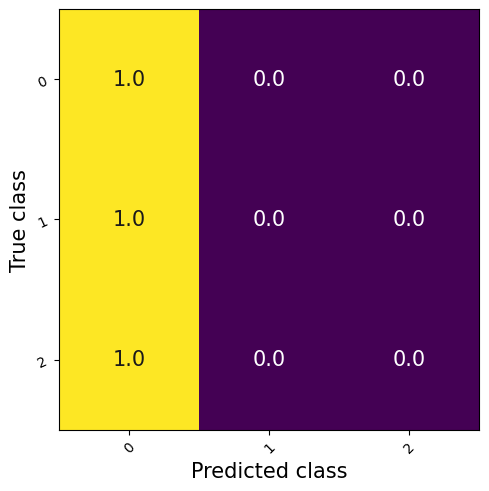

tensor([[1769,    0,    0],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9935, 0.0000, 0.0000])
perclass_precision: tensor([0.9872, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 1 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


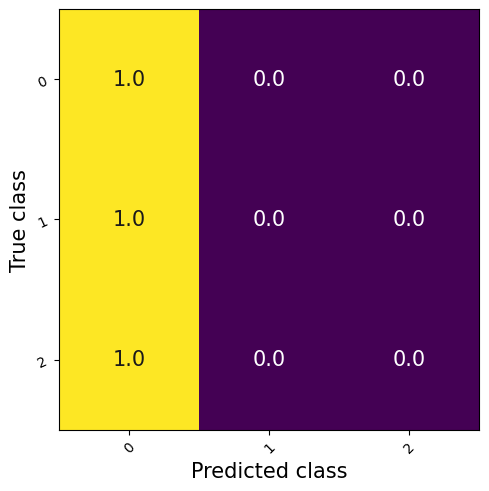

tensor([[1769,    0,    0],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9935, 0.0000, 0.0000])
perclass_precision: tensor([0.9872, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 2 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_03_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


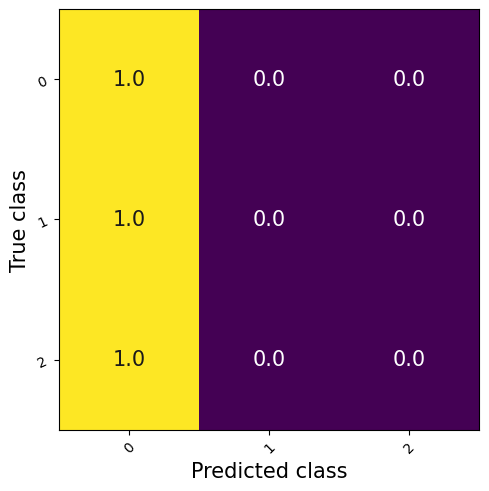

tensor([[1770,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9938, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 3 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_04_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


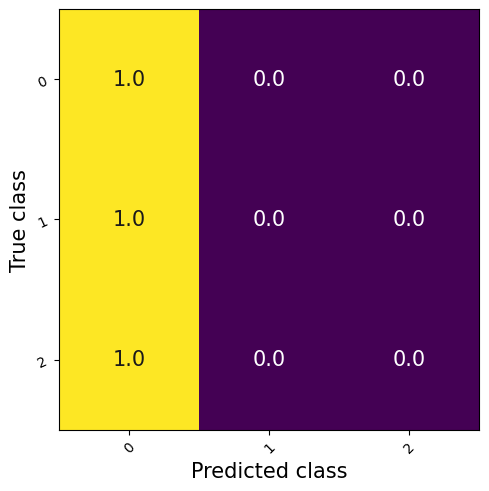

tensor([[1514,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 4 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_05_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


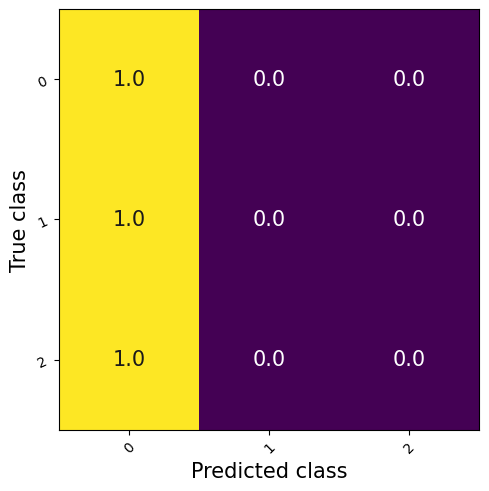

tensor([[1514,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 5 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


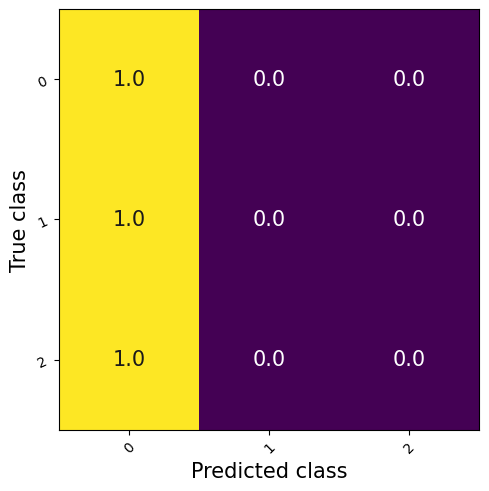

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 6 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


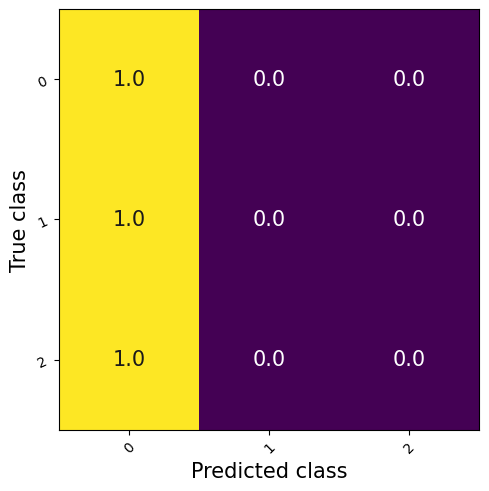

tensor([[1765,    0,    1],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9855, 0.0000, 0.0000])
perclass_recall: tensor([0.9994, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 7 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_03_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


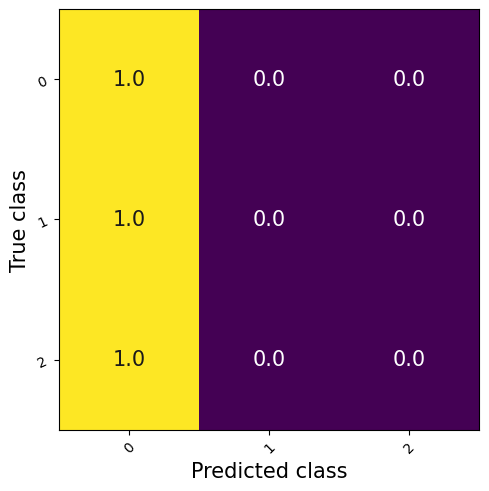

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 8 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_04_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


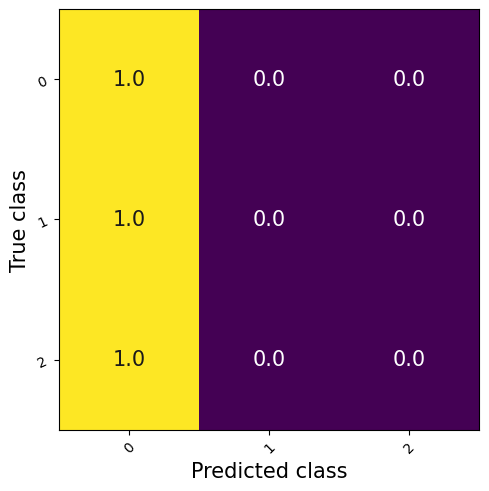

tensor([[1764,    0,    0],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 9 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_05_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


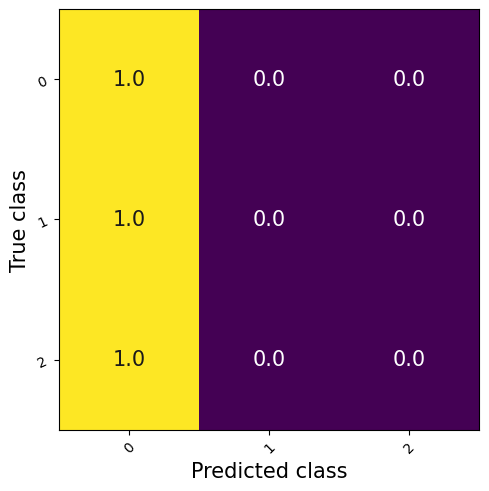

tensor([[1763,    0,    2],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9989, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 10 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


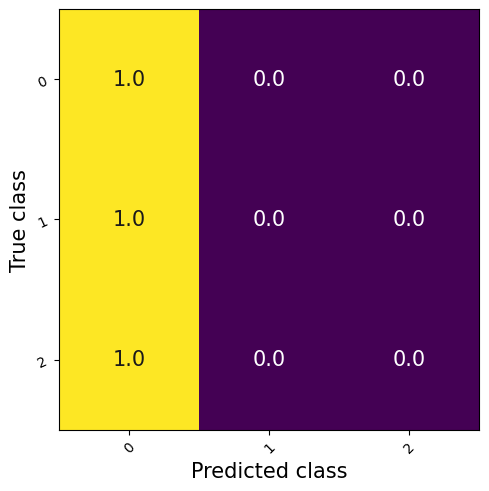

tensor([[2278,    4,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3314 ✨
perclass_f1scores: tensor([0.9943, 0.0000, 0.0000])
perclass_precision: tensor([0.9904, 0.0000, 0.0000])
perclass_recall: tensor([0.9982, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 11 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


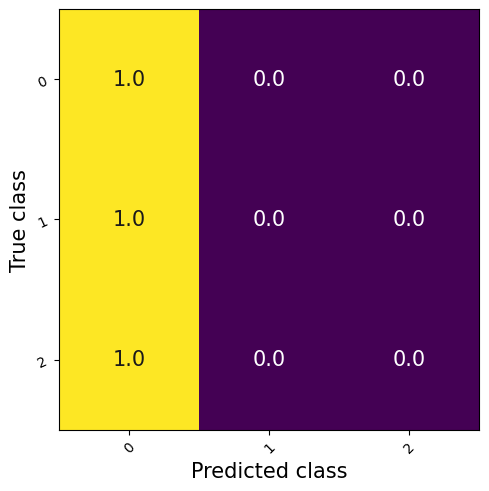

tensor([[2023,    2,    1],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9939, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9985, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(16.0)}
 === Currently Evaluating curr_test_idx: 12 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


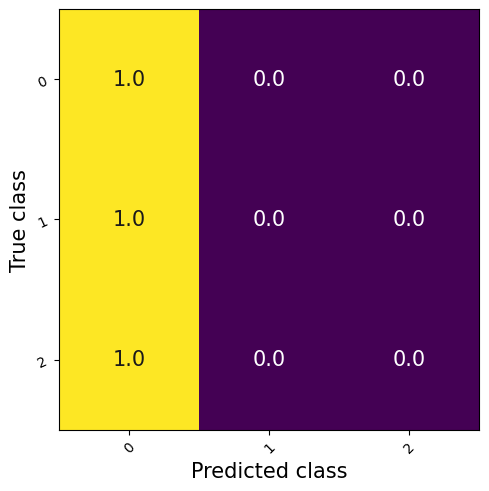

tensor([[2026,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9946, 0.0000, 0.0000])
perclass_precision: tensor([0.9893, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 13 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


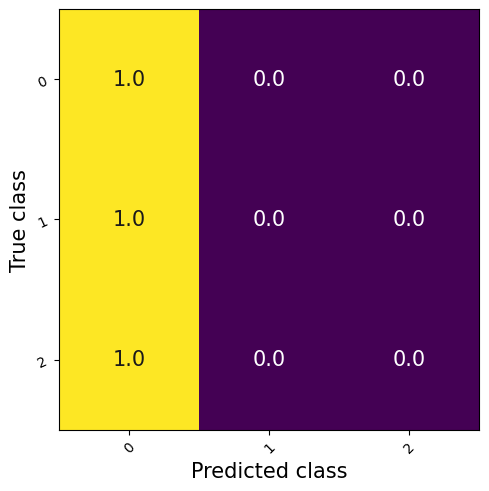

tensor([[2795,    0,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3321 ✨
perclass_f1scores: tensor([0.9963, 0.0000, 0.0000])
perclass_precision: tensor([0.9925, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 14 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


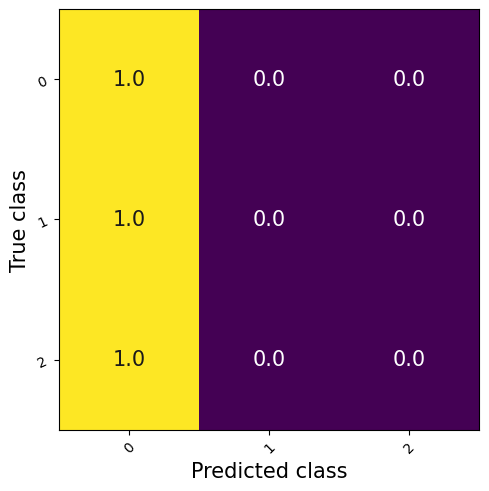

tensor([[2025,    1,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9944, 0.0000, 0.0000])
perclass_precision: tensor([0.9893, 0.0000, 0.0000])
perclass_recall: tensor([0.9995, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 15 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


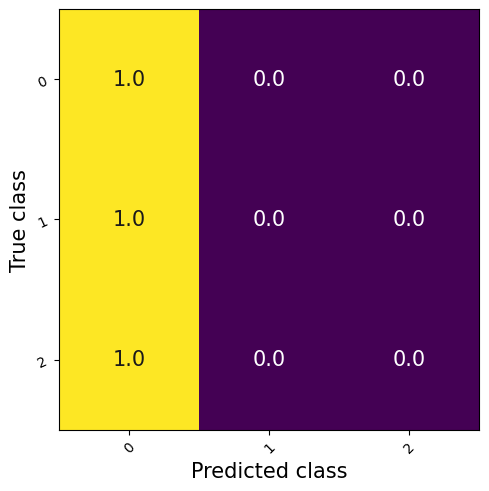

tensor([[2530,    2,    1],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3314 ✨
perclass_f1scores: tensor([0.9941, 0.0000, 0.0000])
perclass_precision: tensor([0.9894, 0.0000, 0.0000])
perclass_recall: tensor([0.9988, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 16 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


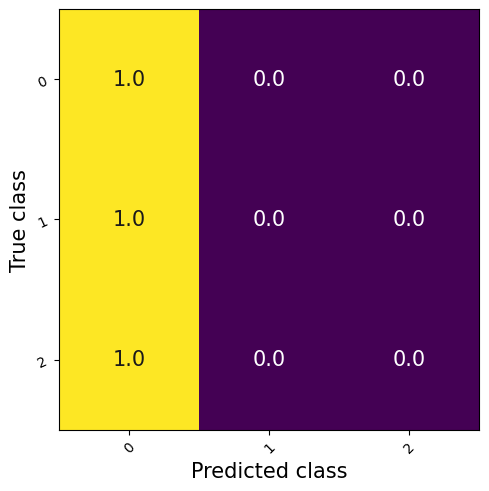

tensor([[2271,    3,    1],
        [  15,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9874, 0.0000, 0.0000])
perclass_recall: tensor([0.9982, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 17 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


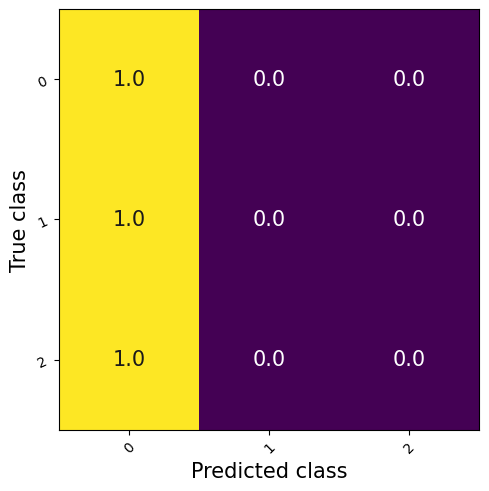

tensor([[2530,    0,    0],
        [  15,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3314 ✨
perclass_f1scores: tensor([0.9941, 0.0000, 0.0000])
perclass_precision: tensor([0.9883, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 18 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


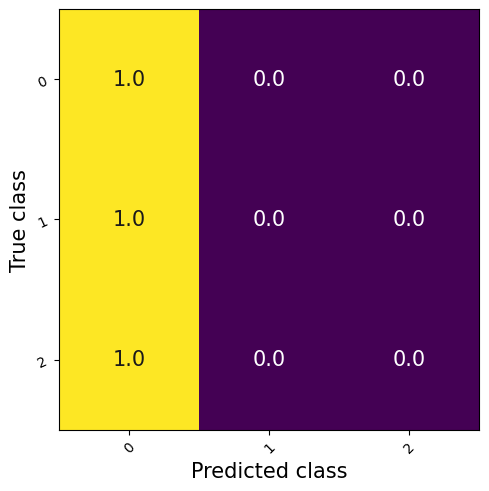

tensor([[2273,    2,    1],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9932, 0.0000, 0.0000])
perclass_precision: tensor([0.9878, 0.0000, 0.0000])
perclass_recall: tensor([0.9987, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
 === Currently Evaluating curr_test_idx: 19 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


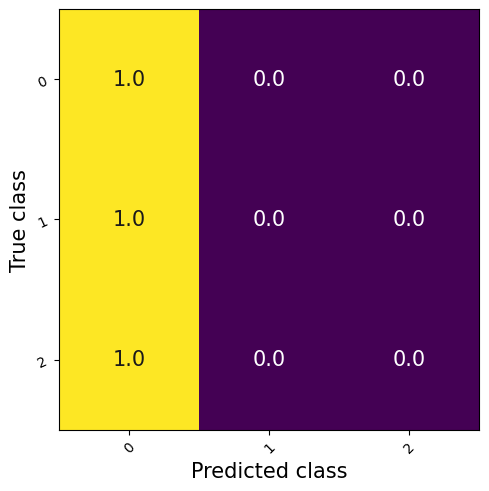

tensor([[2274,    0,    2],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9878, 0.0000, 0.0000])
perclass_recall: tensor([0.9991, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 20 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


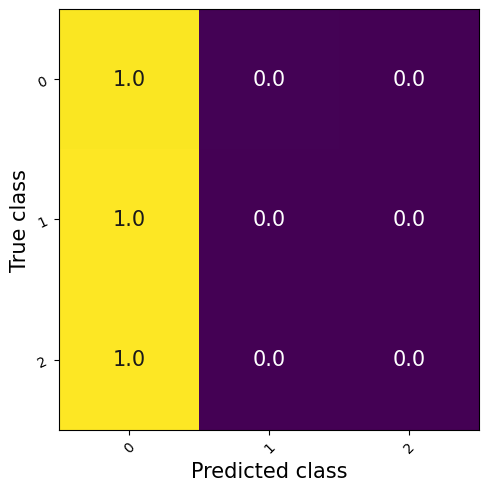

tensor([[2017,   10,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([0.9951, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 21 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


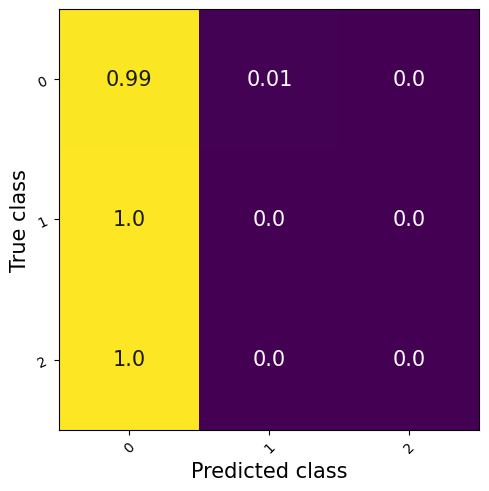

tensor([[1505,    9,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9898, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9941, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 22 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


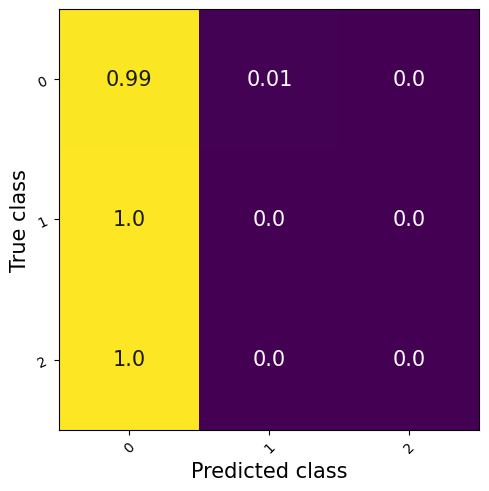

tensor([[1506,    8,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 23 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


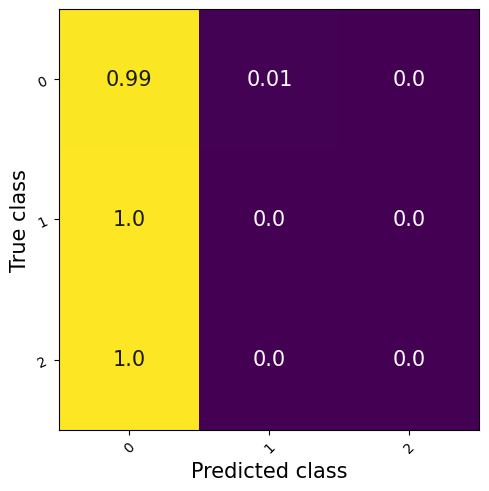

tensor([[1506,    8,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 24 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


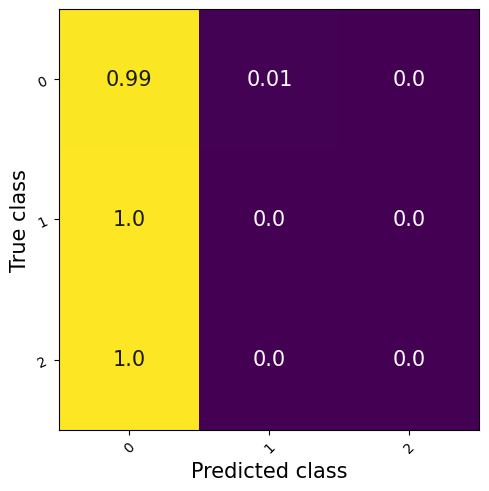

tensor([[1506,    8,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 25 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


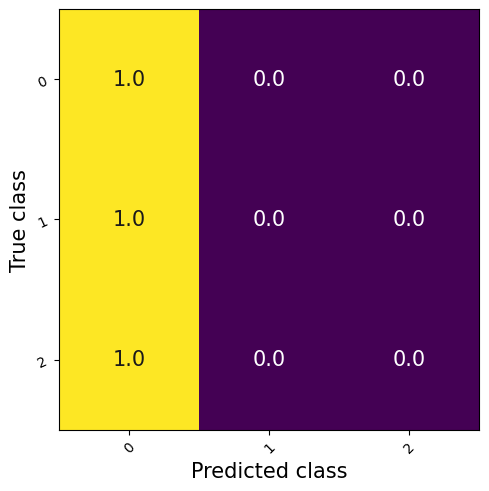

tensor([[2525,    5,    1],
        [  14,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9931, 0.0000, 0.0000])
perclass_precision: tensor([0.9886, 0.0000, 0.0000])
perclass_recall: tensor([0.9976, 0.0000, 0.0000])
MAE overall: 17.0000
MAE per_class: {1: np.float64(17.0)}
 === Currently Evaluating curr_test_idx: 26 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


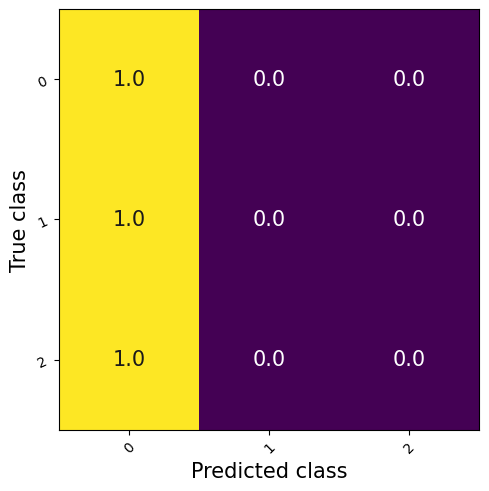

tensor([[1760,    4,    1],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9972, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 27 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


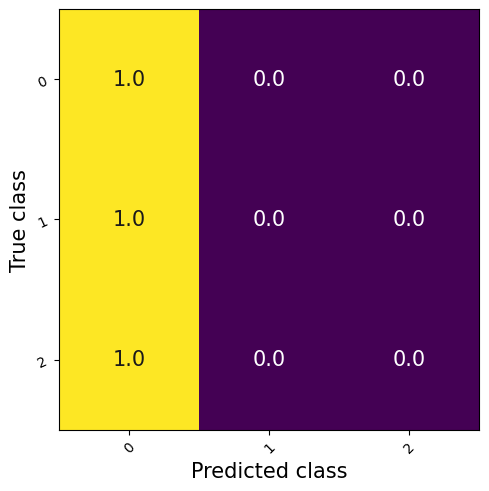

tensor([[1761,    4,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9913, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9977, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 28 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


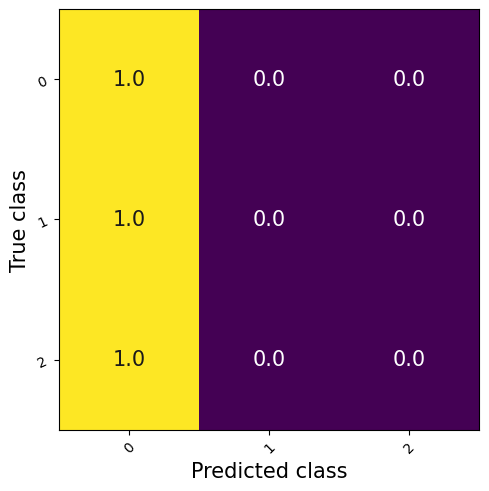

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 29 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


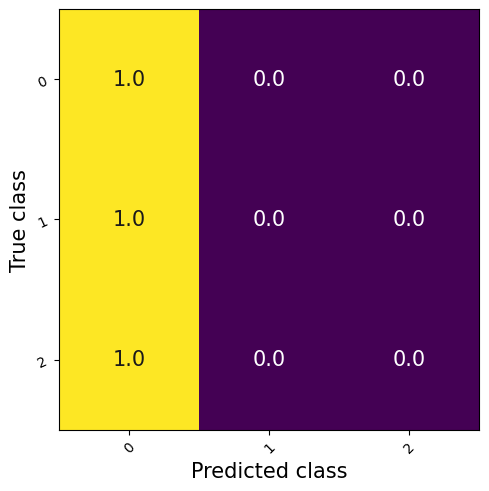

tensor([[1762,    3,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9916, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 30 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


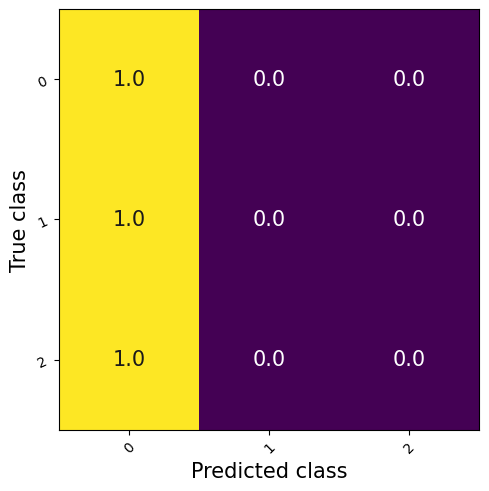

tensor([[2279,    0,    0],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9945, 0.0000, 0.0000])
perclass_precision: tensor([0.9891, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 31 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


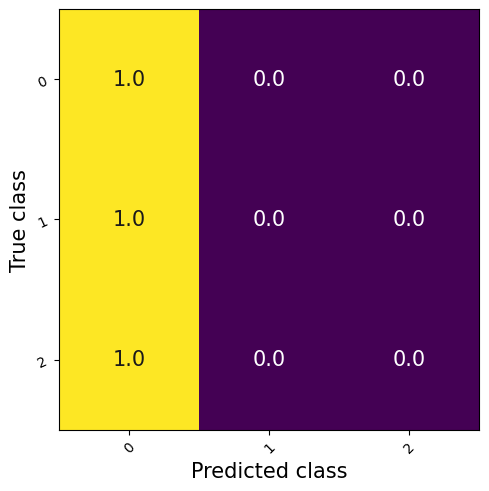

tensor([[2021,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9868, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 32 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


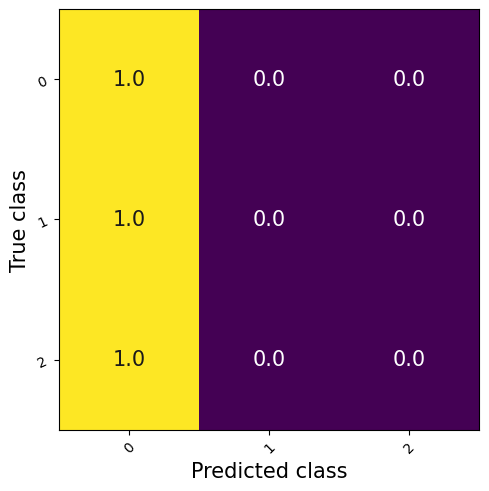

tensor([[1765,    1,    0],
        [  13,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9855, 0.0000, 0.0000])
perclass_recall: tensor([0.9994, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
 === Currently Evaluating curr_test_idx: 33 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


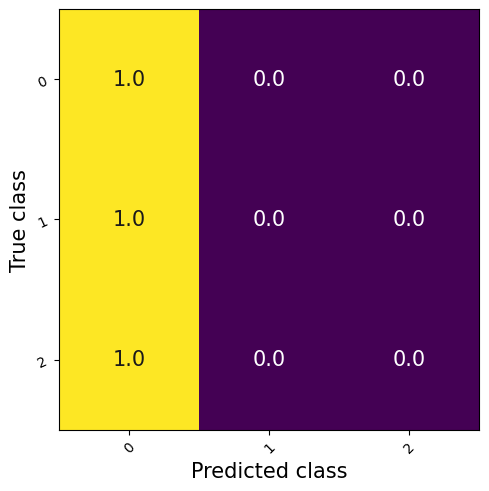

tensor([[1763,    3,    0],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9855, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: 18.5000
MAE per_class: {1: np.float64(18.5)}
 === Currently Evaluating curr_test_idx: 34 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


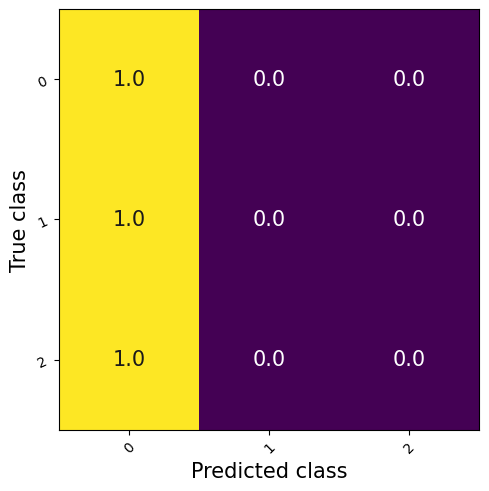

tensor([[2021,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9868, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 35 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


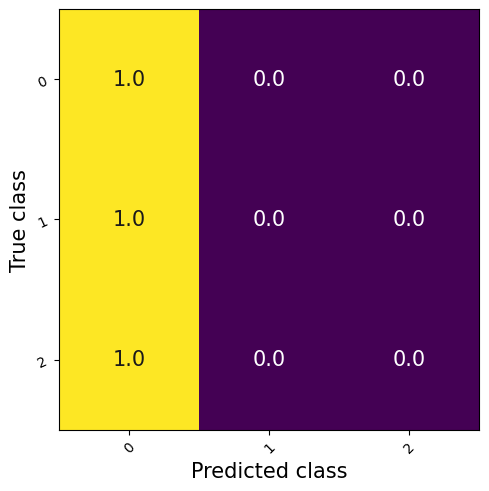

tensor([[1764,    0,    0],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 36 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


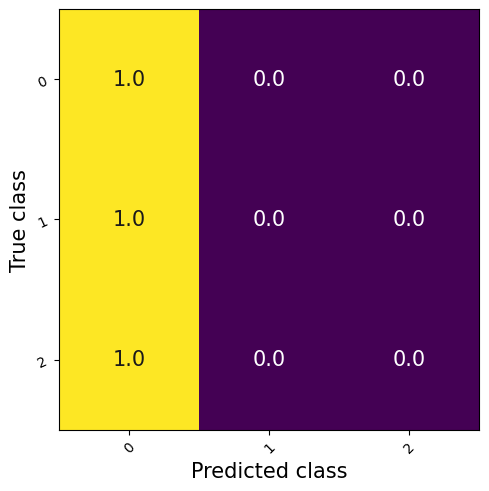

tensor([[2274,    1,    0],
        [  15,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9874, 0.0000, 0.0000])
perclass_recall: tensor([0.9996, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 37 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


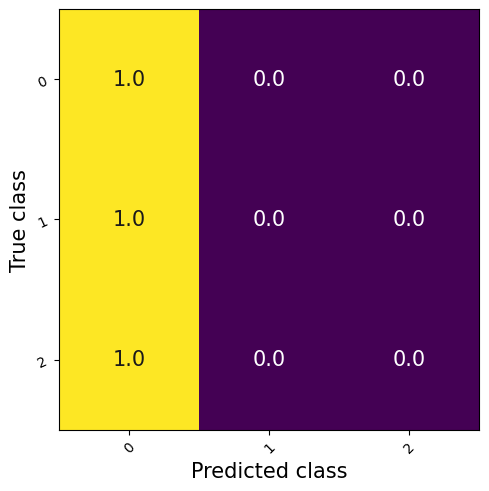

tensor([[2016,    0,    0],
        [  16,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 38 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


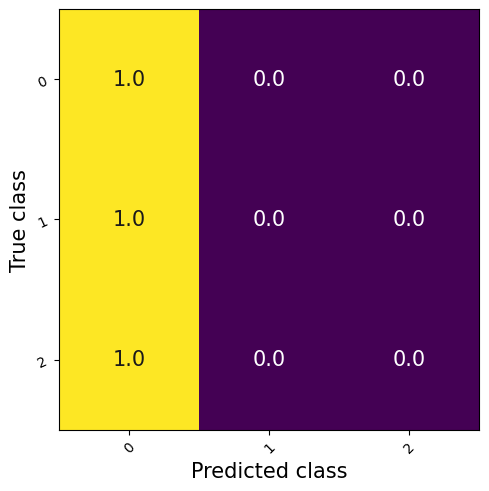

tensor([[2788,    0,    0],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3317 ✨
perclass_f1scores: tensor([0.9950, 0.0000, 0.0000])
perclass_precision: tensor([0.9901, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 39 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


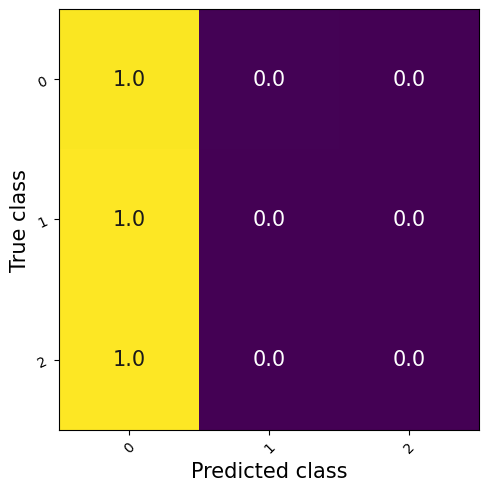

tensor([[2529,   10,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9939, 0.0000, 0.0000])
perclass_precision: tensor([0.9918, 0.0000, 0.0000])
perclass_recall: tensor([0.9961, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 40 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


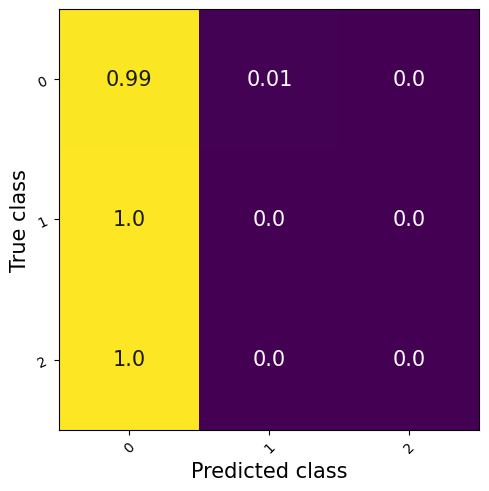

tensor([[1504,   11,    0],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 41 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


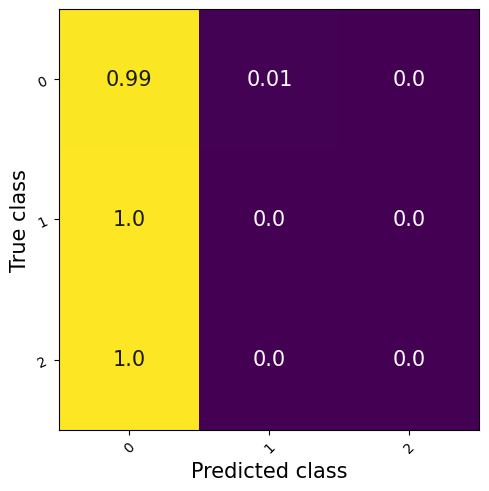

tensor([[1759,   11,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9907, 0.0000, 0.0000])
perclass_precision: tensor([0.9876, 0.0000, 0.0000])
perclass_recall: tensor([0.9938, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 42 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


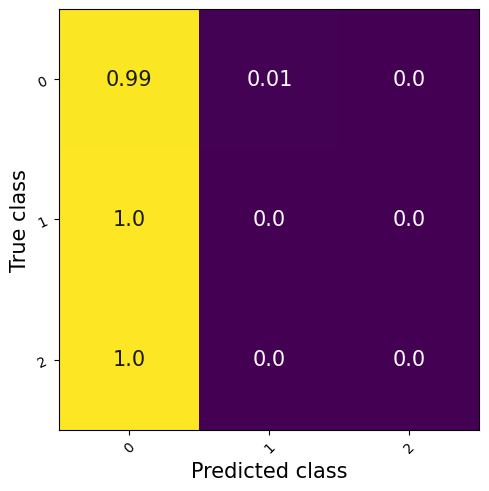

tensor([[1505,   10,    0],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9898, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 43 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


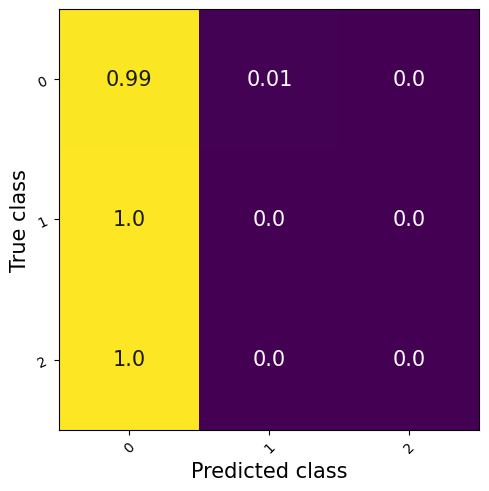

tensor([[1503,   11,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3297 ✨
perclass_f1scores: tensor([0.9891, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 44 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


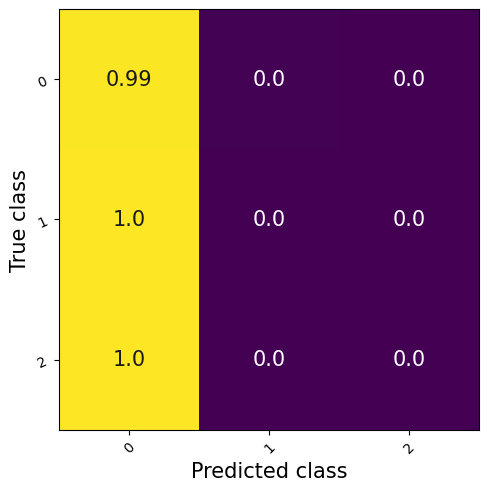

tensor([[2267,    9,    3],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9919, 0.0000, 0.0000])
perclass_precision: tensor([0.9891, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
 === Currently Evaluating curr_test_idx: 45 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


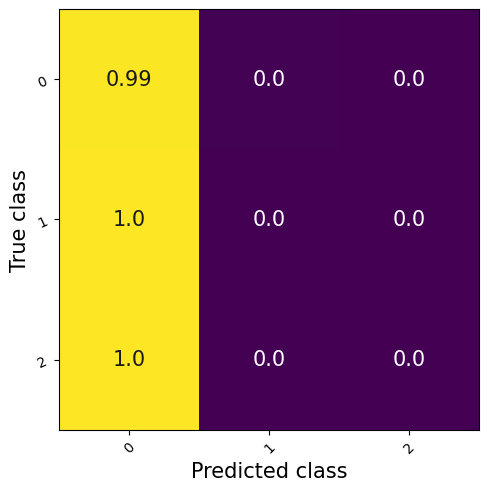

tensor([[1753,    8,    4],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3297 ✨
perclass_f1scores: tensor([0.9890, 0.0000, 0.0000])
perclass_precision: tensor([0.9848, 0.0000, 0.0000])
perclass_recall: tensor([0.9932, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 46 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


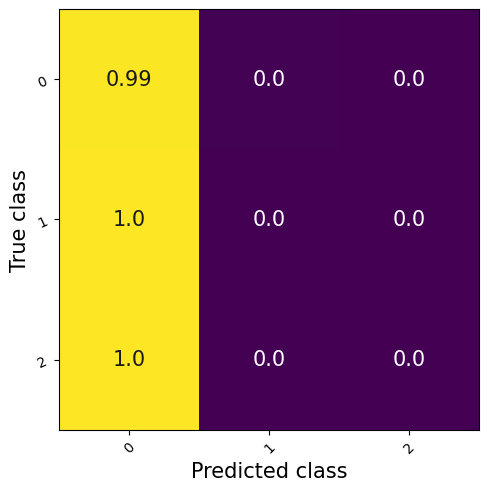

tensor([[1755,    8,    3],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9896, 0.0000, 0.0000])
perclass_precision: tensor([0.9854, 0.0000, 0.0000])
perclass_recall: tensor([0.9938, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 47 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


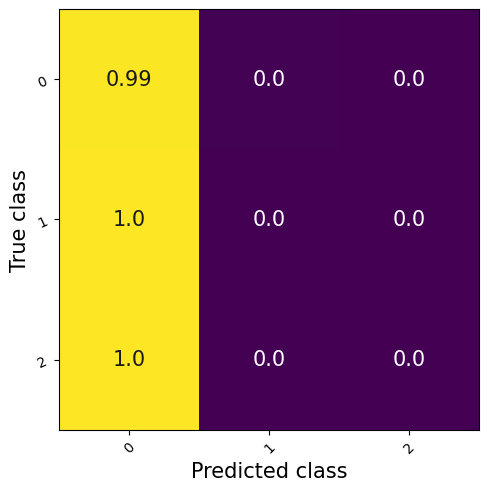

tensor([[1756,    7,    3],
        [  13,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9899, 0.0000, 0.0000])
perclass_precision: tensor([0.9854, 0.0000, 0.0000])
perclass_recall: tensor([0.9943, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 48 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


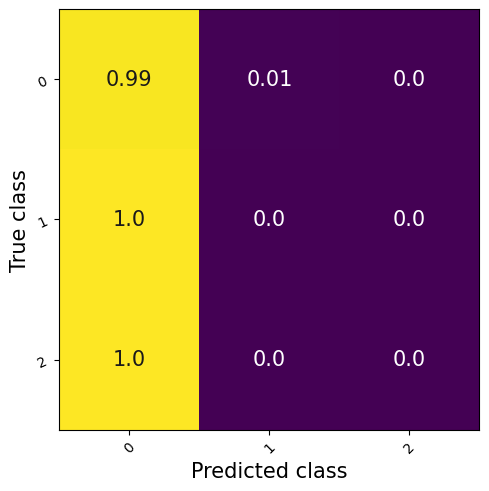

tensor([[1752,    9,    5],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3296 ✨
perclass_f1scores: tensor([0.9887, 0.0000, 0.0000])
perclass_precision: tensor([0.9854, 0.0000, 0.0000])
perclass_recall: tensor([0.9921, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
 === Currently Evaluating curr_test_idx: 49 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


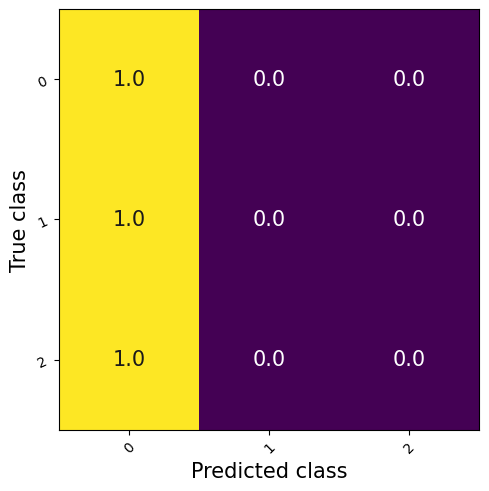

tensor([[1766,    3,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9927, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(16.0)}
 === Currently Evaluating curr_test_idx: 50 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


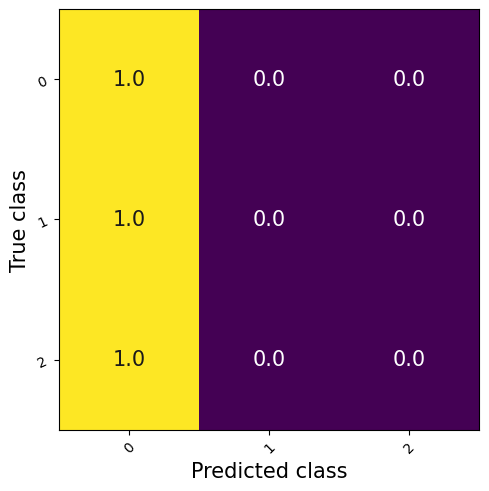

tensor([[1514,    0,    0],
        [  12,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 51 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


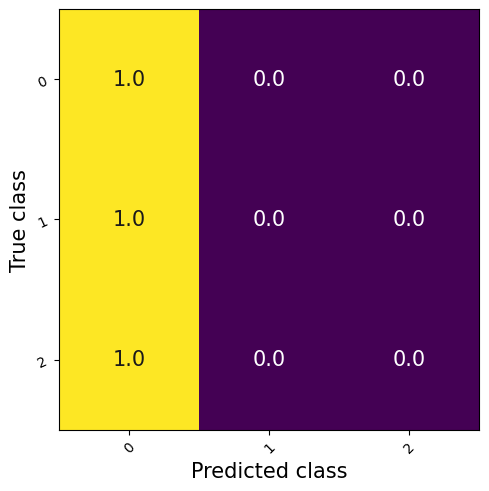

tensor([[1508,    4,    0],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9908, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9974, 0.0000, 0.0000])
MAE overall: 15.3333
MAE per_class: {1: np.float64(15.333333333333334)}
 === Currently Evaluating curr_test_idx: 52 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


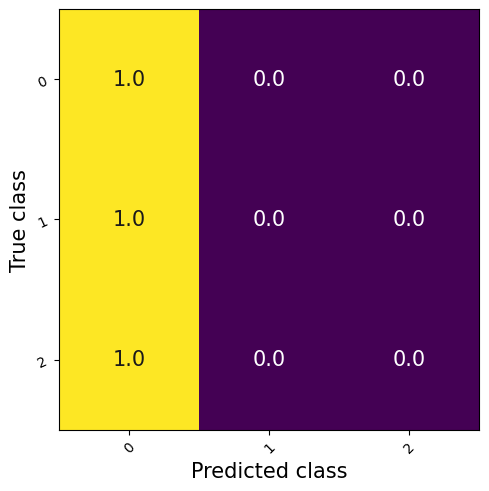

tensor([[1514,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 53 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


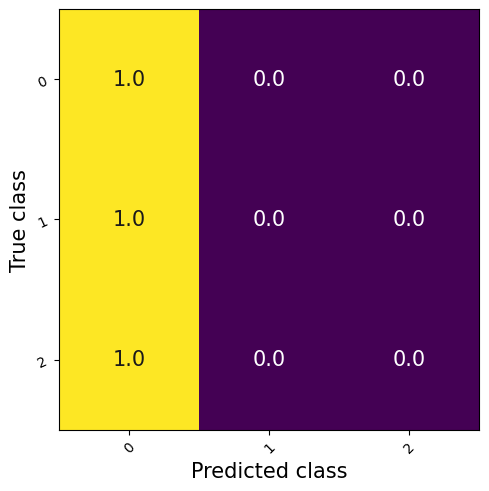

tensor([[1512,    2,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([0.9987, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
 === Currently Evaluating curr_test_idx: 54 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


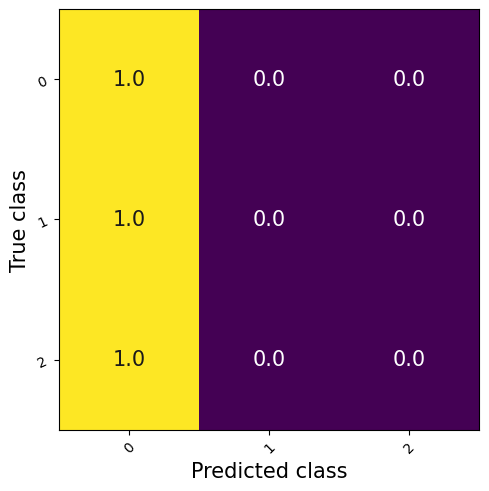

tensor([[1514,    0,    0],
        [  12,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 55 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_07.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


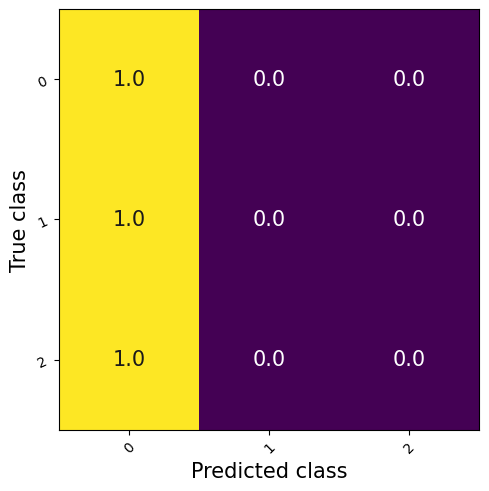

tensor([[1514,    1,    0],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9863, 0.0000, 0.0000])
perclass_recall: tensor([0.9993, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
 === Currently Evaluating curr_test_idx: 56 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


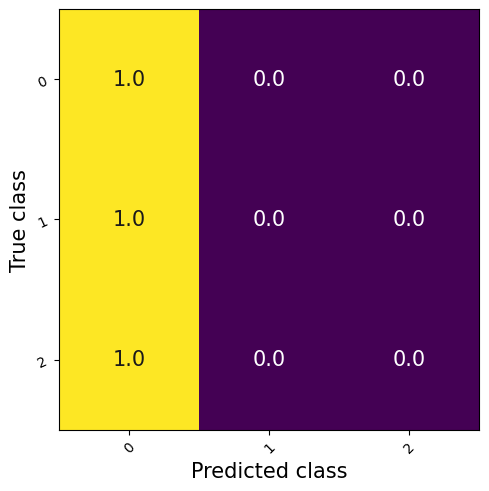

tensor([[1764,    0,    0],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 57 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


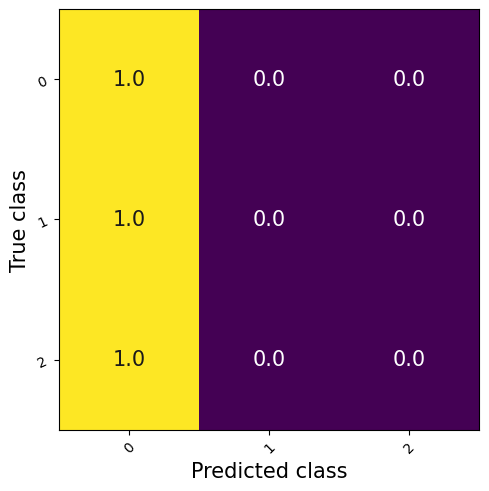

tensor([[1764,    0,    0],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 58 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


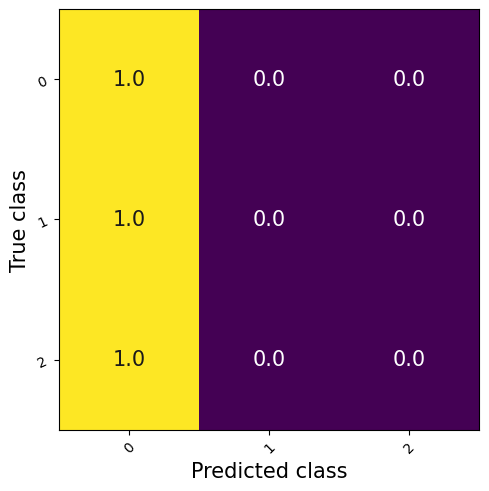

tensor([[1764,    0,    0],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 59 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


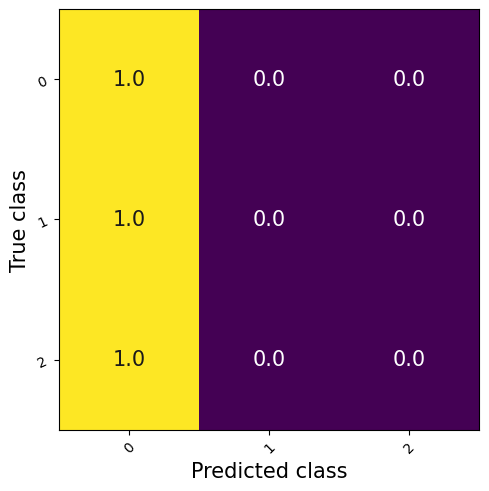

tensor([[2020,    0,    0],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9931, 0.0000, 0.0000])
perclass_precision: tensor([0.9863, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 60 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


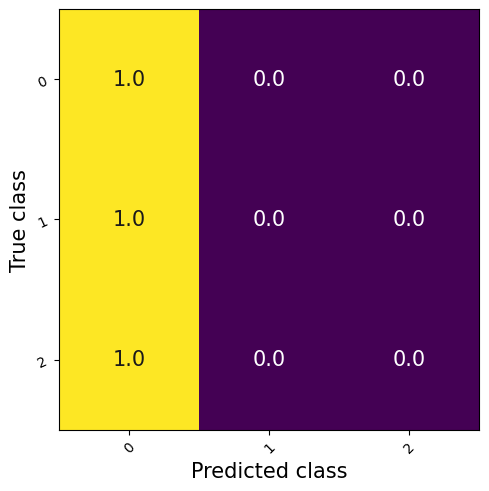

tensor([[2533,    0,    0],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3316 ✨
perclass_f1scores: tensor([0.9947, 0.0000, 0.0000])
perclass_precision: tensor([0.9895, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 61 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


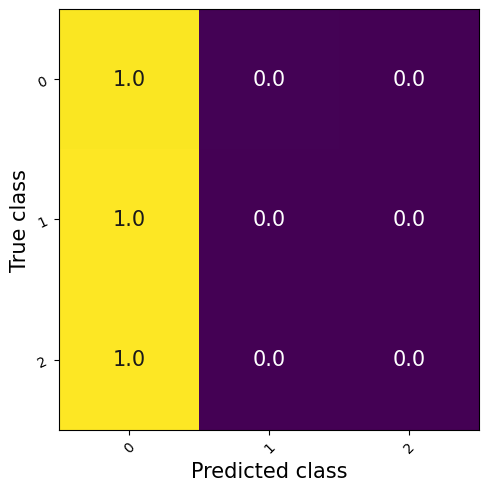

tensor([[1763,    8,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9882, 0.0000, 0.0000])
perclass_recall: tensor([0.9955, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
 === Currently Evaluating curr_test_idx: 62 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


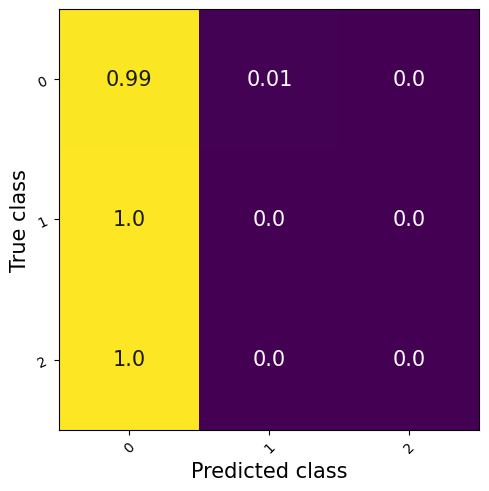

tensor([[1252,    7,    0],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3296 ✨
perclass_f1scores: tensor([0.9889, 0.0000, 0.0000])
perclass_precision: tensor([0.9835, 0.0000, 0.0000])
perclass_recall: tensor([0.9944, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 63 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


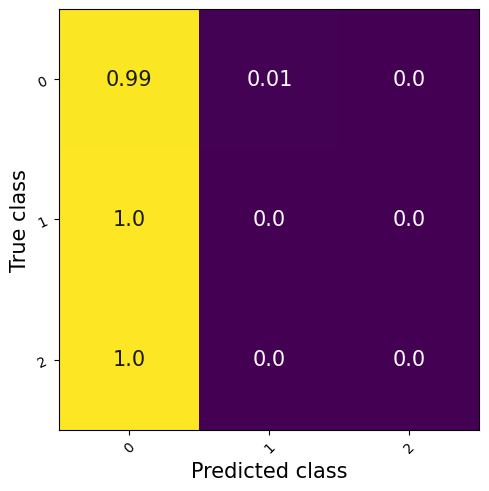

tensor([[1504,    8,    0],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
 === Currently Evaluating curr_test_idx: 64 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


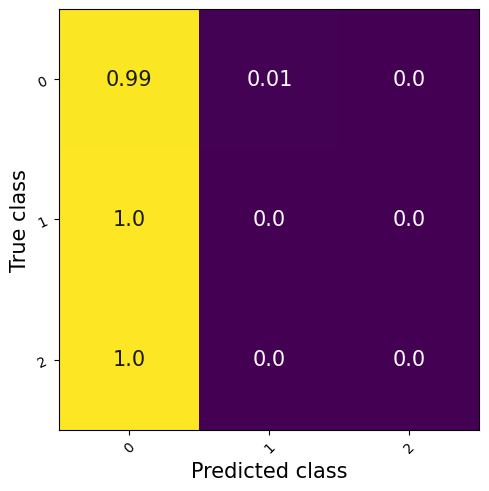

tensor([[1250,    8,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9827, 0.0000, 0.0000])
perclass_recall: tensor([0.9936, 0.0000, 0.0000])
MAE overall: 17.3333
MAE per_class: {1: np.float64(17.333333333333332)}
 === Currently Evaluating curr_test_idx: 65 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


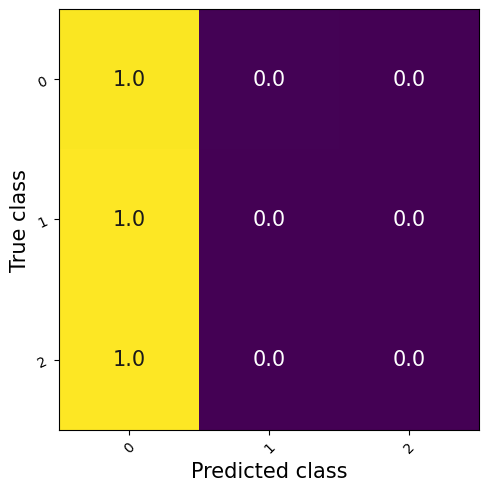

tensor([[1504,    7,    0],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9836, 0.0000, 0.0000])
perclass_recall: tensor([0.9954, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
 === Currently Evaluating curr_test_idx: 66 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


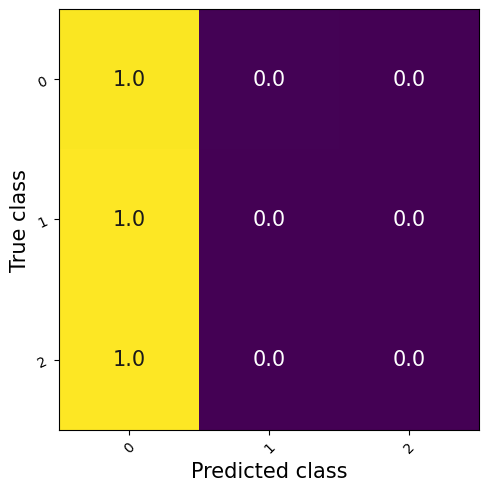

tensor([[2013,    8,    1],
        [  12,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9914, 0.0000, 0.0000])
perclass_precision: tensor([0.9872, 0.0000, 0.0000])
perclass_recall: tensor([0.9955, 0.0000, 0.0000])
MAE overall: 13.0000
MAE per_class: {1: np.float64(13.0)}
 === Currently Evaluating curr_test_idx: 67 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


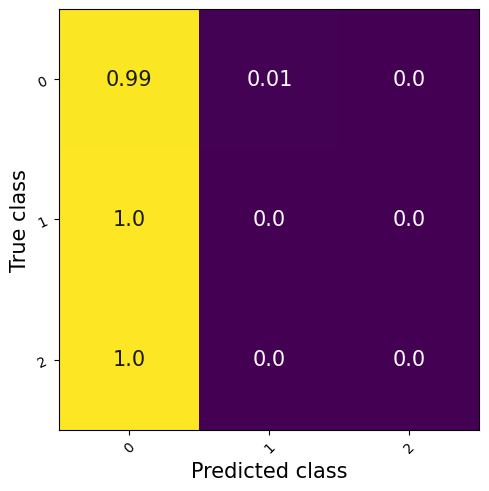

tensor([[1501,    9,    1],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9885, 0.0000, 0.0000])
perclass_precision: tensor([0.9836, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
 === Currently Evaluating curr_test_idx: 68 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


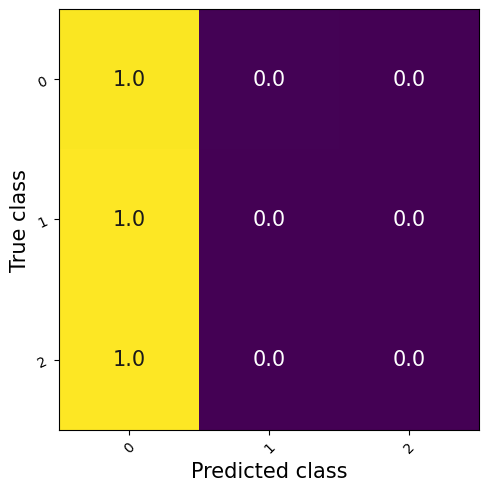

tensor([[1504,    6,    1],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9836, 0.0000, 0.0000])
perclass_recall: tensor([0.9954, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 69 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


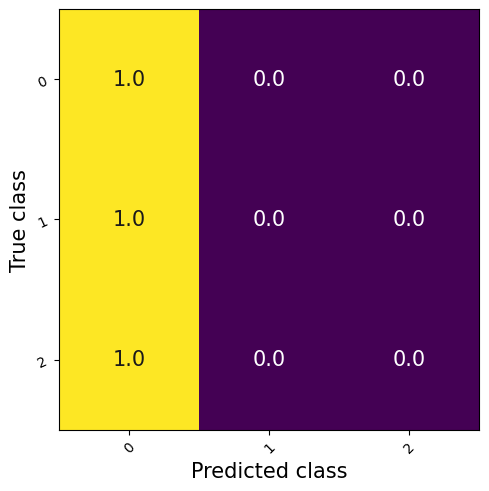

tensor([[1763,    4,    0],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9977, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 70 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


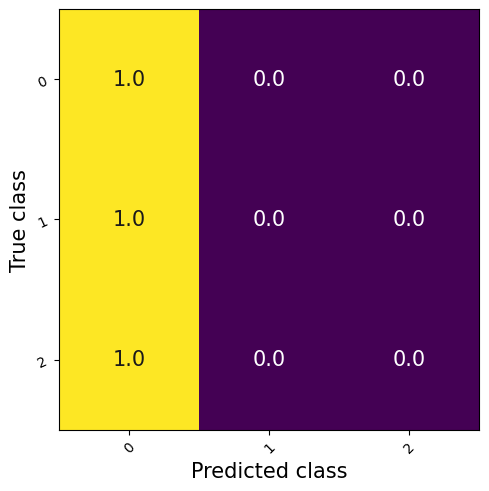

tensor([[2019,    3,    1],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9929, 0.0000, 0.0000])
perclass_precision: tensor([0.9878, 0.0000, 0.0000])
perclass_recall: tensor([0.9980, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 71 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


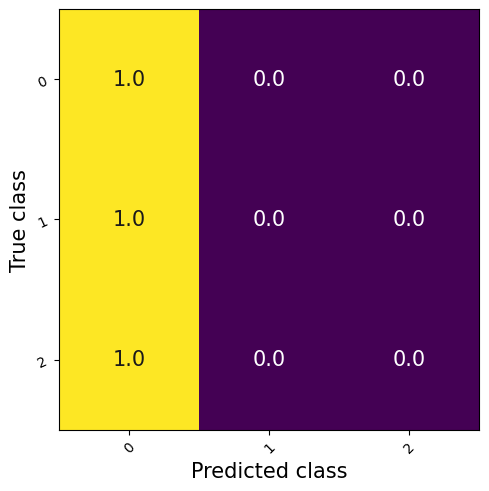

tensor([[2015,    6,    1],
        [  12,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9919, 0.0000, 0.0000])
perclass_precision: tensor([0.9873, 0.0000, 0.0000])
perclass_recall: tensor([0.9965, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 72 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


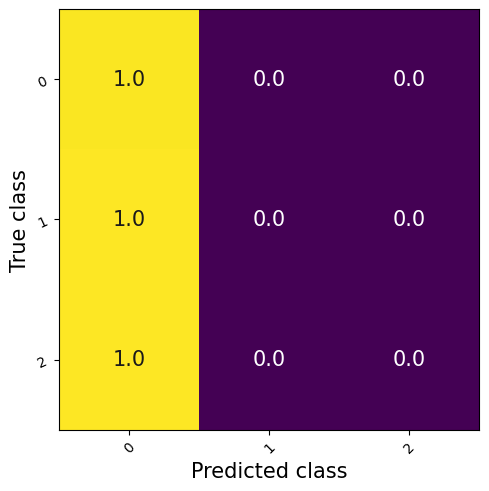

tensor([[1760,    5,    2],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
 === Currently Evaluating curr_test_idx: 73 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


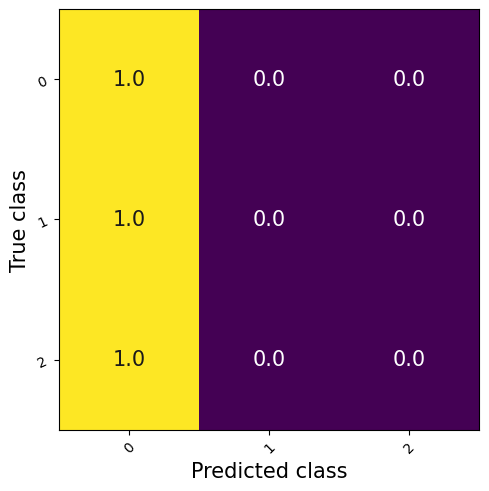

tensor([[2021,    6,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([0.9970, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 74 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


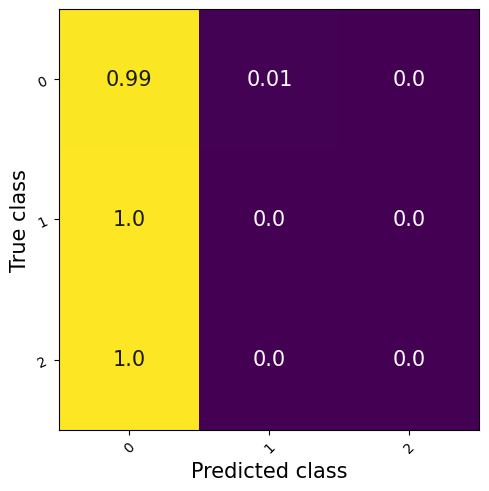

tensor([[1504,   10,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 75 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


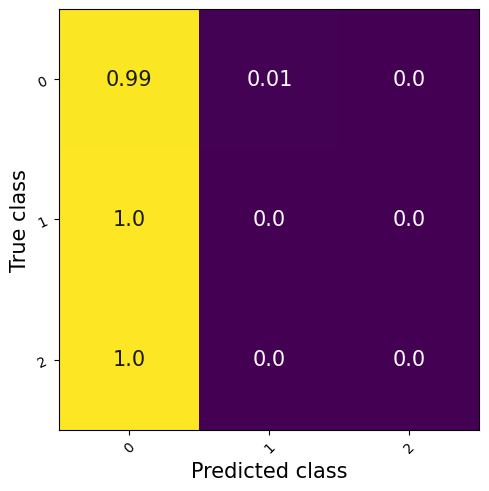

tensor([[1505,    9,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9898, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9941, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 76 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


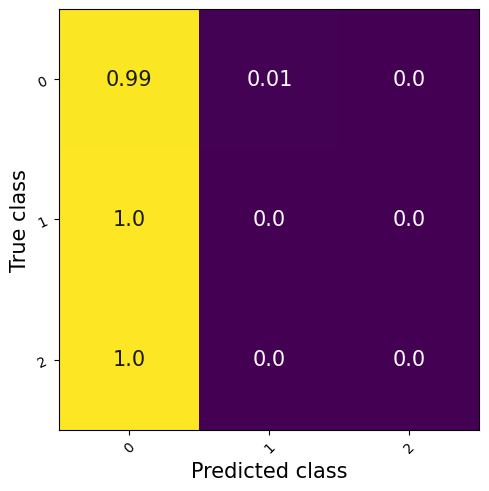

tensor([[1759,   10,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9907, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9943, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 77 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


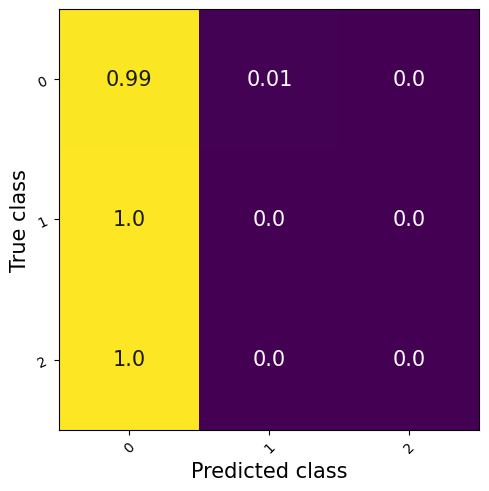

tensor([[1758,   11,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3301 ✨
perclass_f1scores: tensor([0.9904, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9938, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 78 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


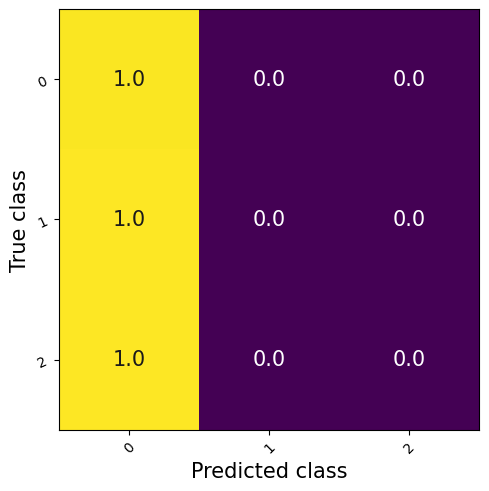

tensor([[1760,    5,    2],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 79 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


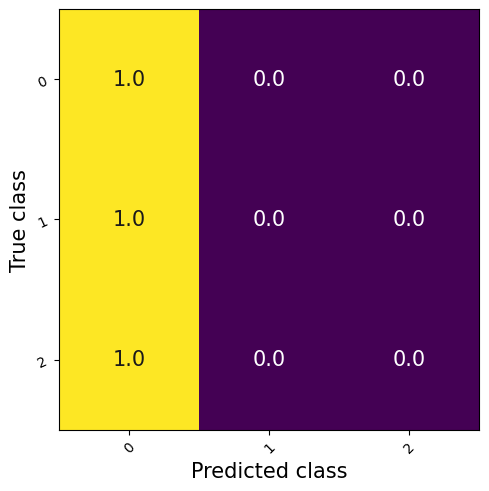

tensor([[2016,    4,    2],
        [  13,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9873, 0.0000, 0.0000])
perclass_recall: tensor([0.9970, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 80 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


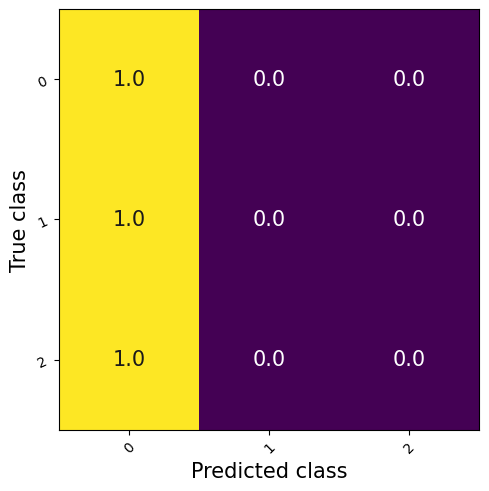

tensor([[2017,    3,    2],
        [  13,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9873, 0.0000, 0.0000])
perclass_recall: tensor([0.9975, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 81 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


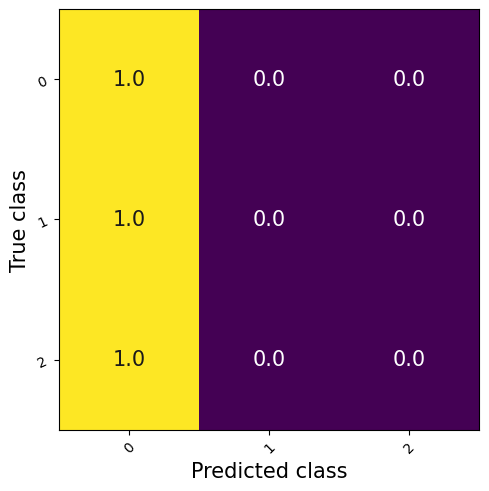

tensor([[2018,    4,    1],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9926, 0.0000, 0.0000])
perclass_precision: tensor([0.9878, 0.0000, 0.0000])
perclass_recall: tensor([0.9975, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 82 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


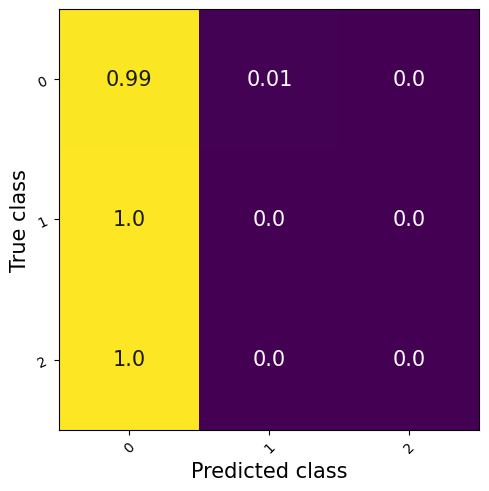

tensor([[1506,    8,    1],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9941, 0.0000, 0.0000])
MAE overall: 15.0000
MAE per_class: {1: np.float64(15.0)}
 === Currently Evaluating curr_test_idx: 83 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


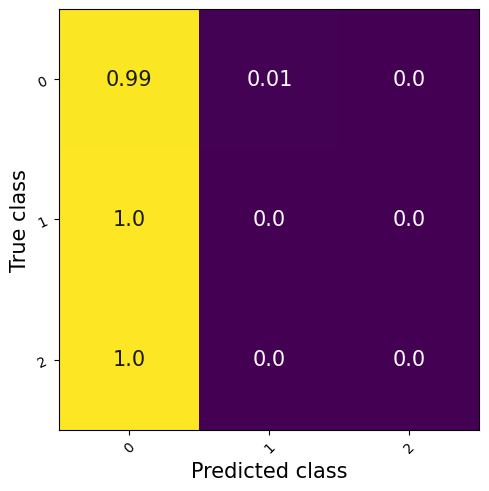

tensor([[996,   7,   0],
        [ 11,   0,   0],
        [ 10,   0,   0]])
Macro F1-Score: 0.3287 ✨
perclass_f1scores: tensor([0.9861, 0.0000, 0.0000])
perclass_precision: tensor([0.9794, 0.0000, 0.0000])
perclass_recall: tensor([0.9930, 0.0000, 0.0000])
MAE overall: 15.4286
MAE per_class: {1: np.float64(15.428571428571429)}
 === Currently Evaluating curr_test_idx: 84 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


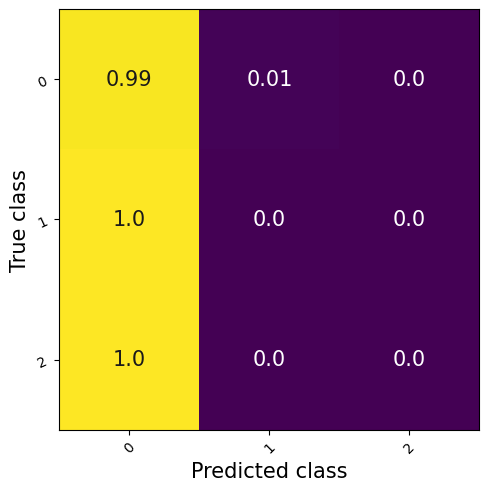

tensor([[992,  10,   0],
        [ 11,   0,   0],
        [ 11,   0,   0]])
Macro F1-Score: 0.3280 ✨
perclass_f1scores: tensor([0.9841, 0.0000, 0.0000])
perclass_precision: tensor([0.9783, 0.0000, 0.0000])
perclass_recall: tensor([0.9900, 0.0000, 0.0000])
MAE overall: 15.4444
MAE per_class: {1: np.float64(15.444444444444445)}
 === Currently Evaluating curr_test_idx: 85 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


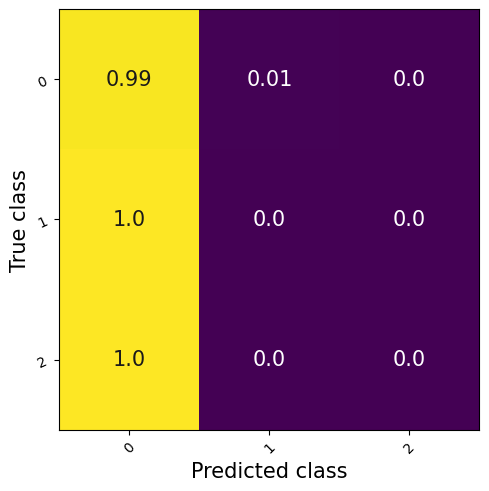

tensor([[1247,    9,    1],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3290 ✨
perclass_f1scores: tensor([0.9869, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9920, 0.0000, 0.0000])
MAE overall: 15.1250
MAE per_class: {1: np.float64(15.125)}
 === Currently Evaluating curr_test_idx: 86 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


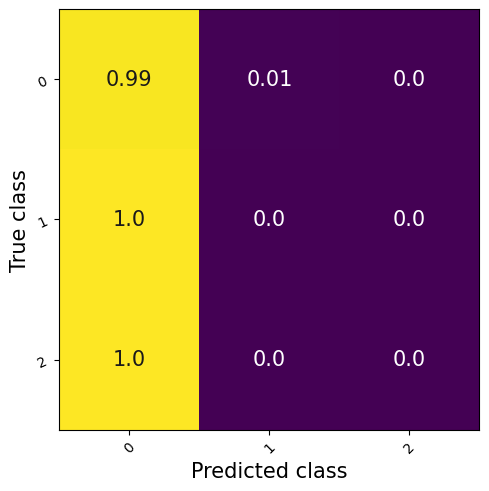

tensor([[1247,    9,    1],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3290 ✨
perclass_f1scores: tensor([0.9869, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9920, 0.0000, 0.0000])
MAE overall: 15.8750
MAE per_class: {1: np.float64(15.875)}
 === Currently Evaluating curr_test_idx: 87 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


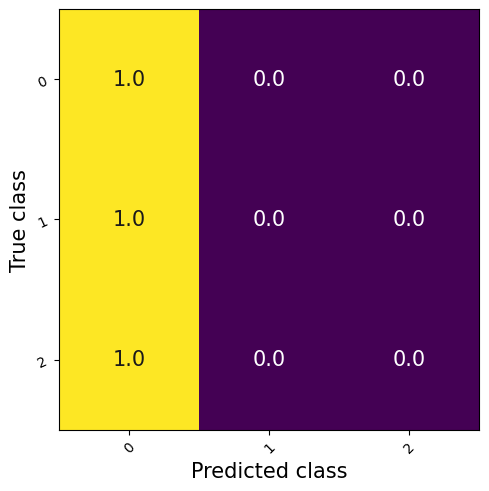

tensor([[1509,    4,    1],
        [  10,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9911, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9967, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(16.0)}
 === Currently Evaluating curr_test_idx: 88 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


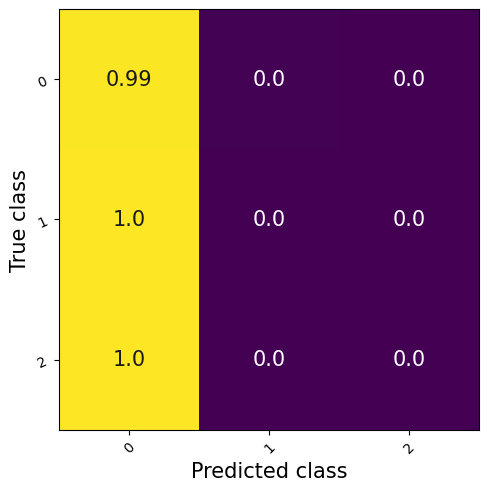

tensor([[1248,    5,    2],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3291 ✨
perclass_f1scores: tensor([0.9873, 0.0000, 0.0000])
perclass_precision: tensor([0.9804, 0.0000, 0.0000])
perclass_recall: tensor([0.9944, 0.0000, 0.0000])
MAE overall: 17.2000
MAE per_class: {1: np.float64(17.2)}
 === Currently Evaluating curr_test_idx: 89 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


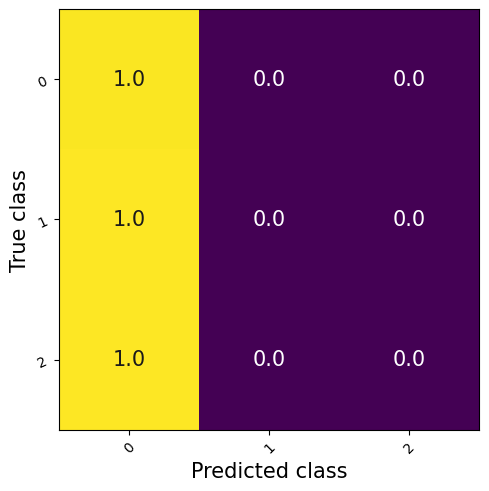

tensor([[997,   3,   1],
        [ 12,   0,   0],
        [ 11,   0,   0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9866, 0.0000, 0.0000])
perclass_precision: tensor([0.9775, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 16.6667
MAE per_class: {1: np.float64(16.666666666666668)}
 === Currently Evaluating curr_test_idx: 90 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


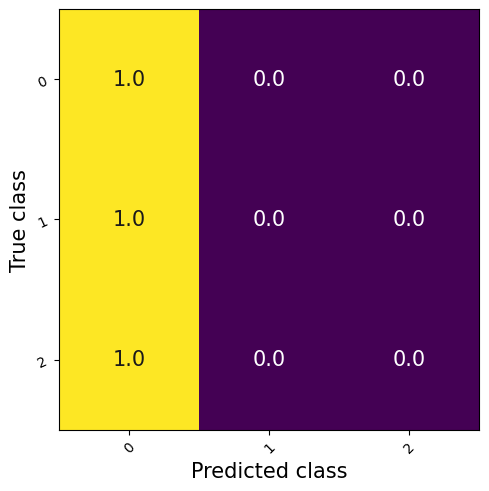

tensor([[1507,    2,    2],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9905, 0.0000, 0.0000])
perclass_precision: tensor([0.9837, 0.0000, 0.0000])
perclass_recall: tensor([0.9974, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
 === Currently Evaluating curr_test_idx: 91 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


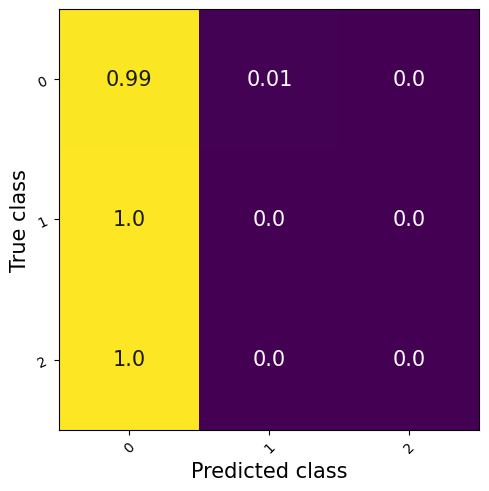

tensor([[1246,    7,    2],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3288 ✨
perclass_f1scores: tensor([0.9865, 0.0000, 0.0000])
perclass_precision: tensor([0.9803, 0.0000, 0.0000])
perclass_recall: tensor([0.9928, 0.0000, 0.0000])
MAE overall: 15.6667
MAE per_class: {1: np.float64(15.666666666666666)}
 === Currently Evaluating curr_test_idx: 92 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


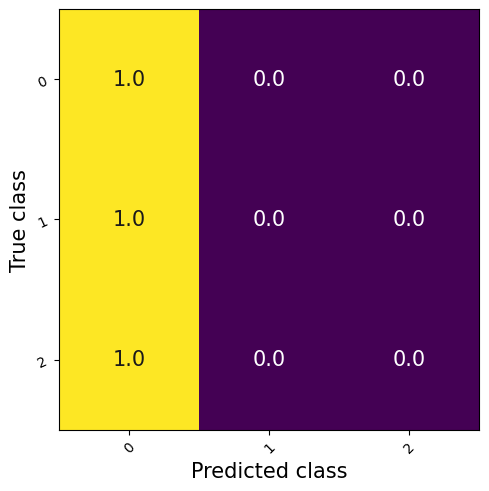

tensor([[2026,    3,    0],
        [   9,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9946, 0.0000, 0.0000])
perclass_precision: tensor([0.9907, 0.0000, 0.0000])
perclass_recall: tensor([0.9985, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 93 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


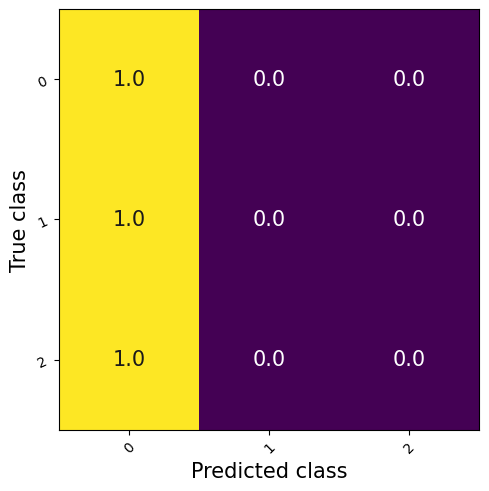

tensor([[1510,    3,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9915, 0.0000, 0.0000])
perclass_precision: tensor([0.9850, 0.0000, 0.0000])
perclass_recall: tensor([0.9980, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 94 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


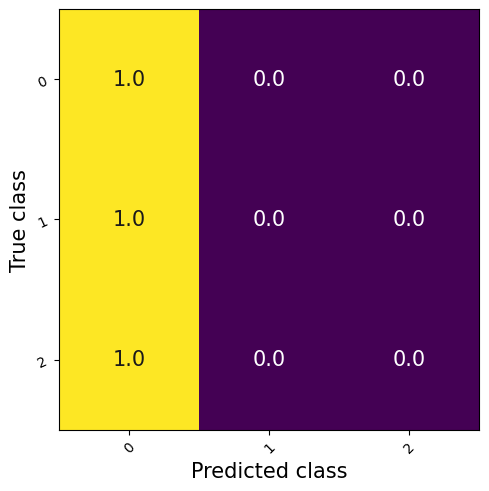

tensor([[1513,    1,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9925, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([0.9993, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
 === Currently Evaluating curr_test_idx: 95 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


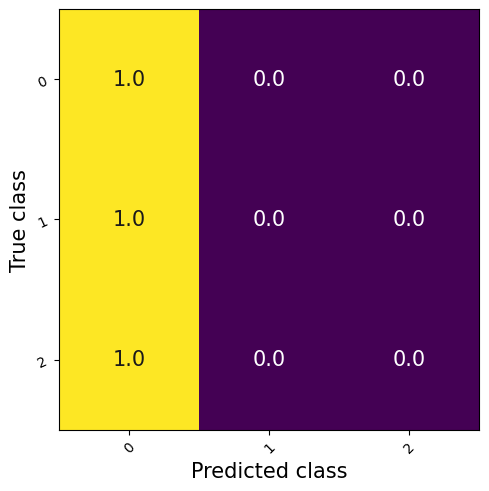

tensor([[1513,    2,    0],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9925, 0.0000, 0.0000])
perclass_precision: tensor([0.9863, 0.0000, 0.0000])
perclass_recall: tensor([0.9987, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 96 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


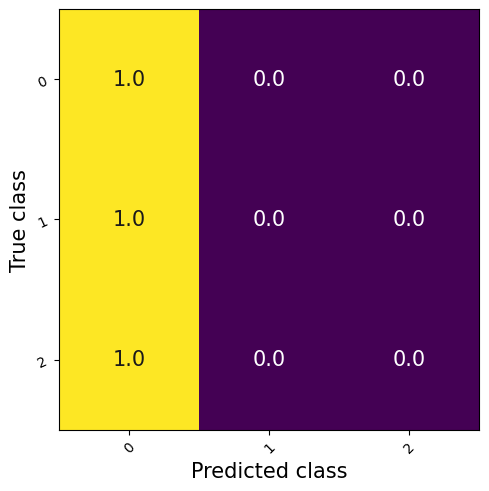

tensor([[1510,    2,    2],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9915, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9974, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 97 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


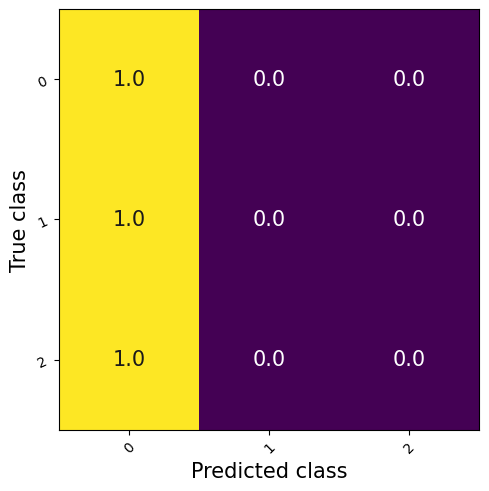

tensor([[1510,    0,    2],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9915, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([0.9987, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 98 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


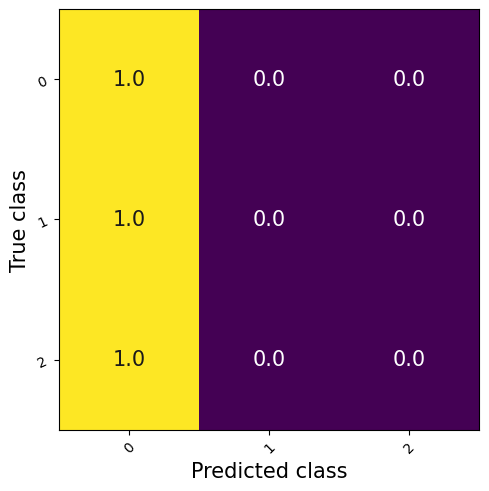

tensor([[1764,    0,    4],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9866, 0.0000, 0.0000])
perclass_recall: tensor([0.9977, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 99 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


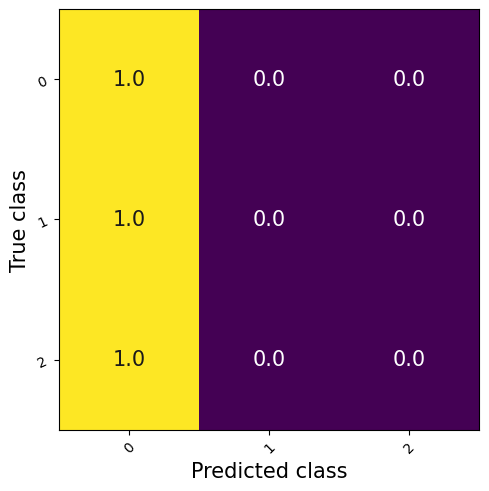

tensor([[2279,    0,    0],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9945, 0.0000, 0.0000])
perclass_precision: tensor([0.9891, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 100 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


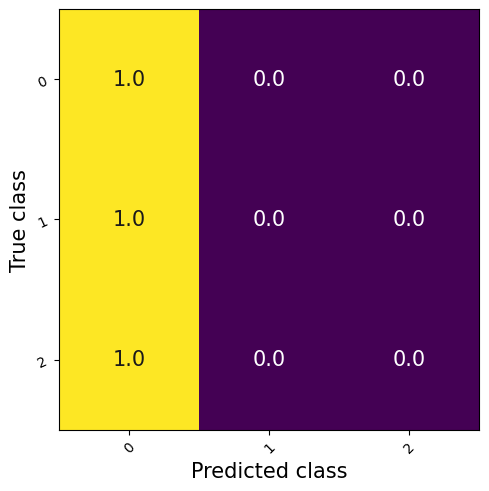

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 101 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


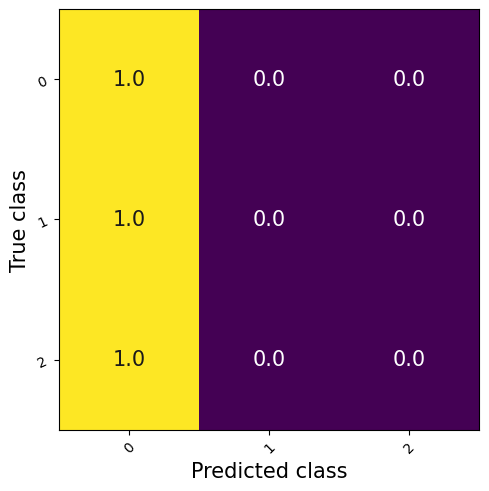

tensor([[2019,    0,    0],
        [  15,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9929, 0.0000, 0.0000])
perclass_precision: tensor([0.9858, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 102 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


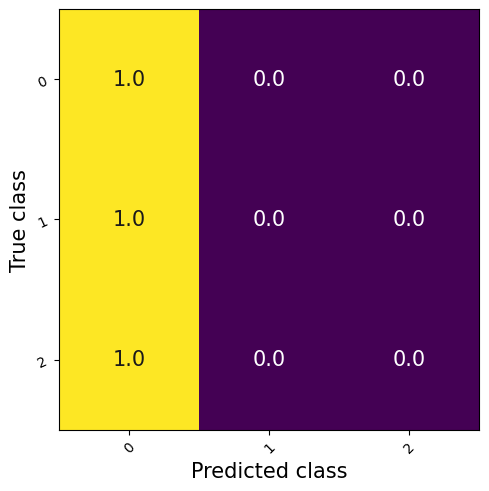

tensor([[1765,    0,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 103 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


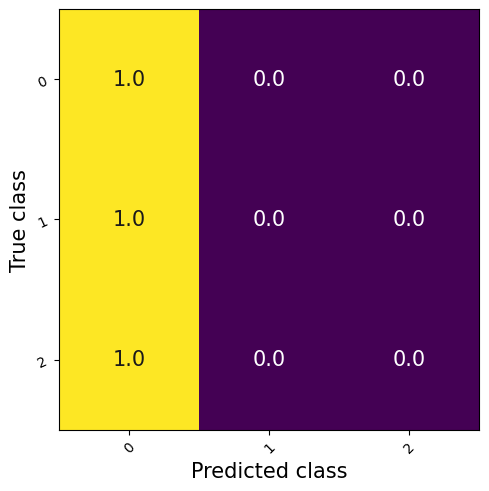

tensor([[1765,    0,    0],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 104 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


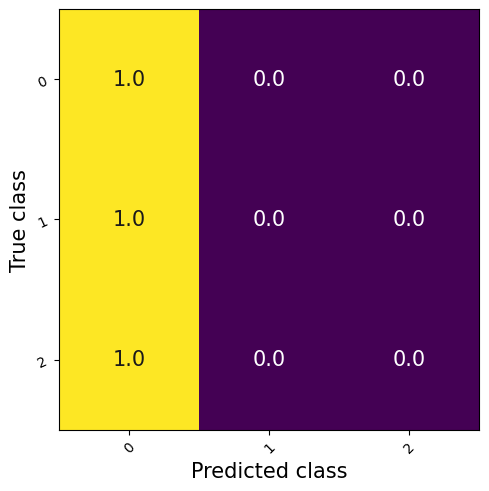

tensor([[1764,    0,    0],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 105 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


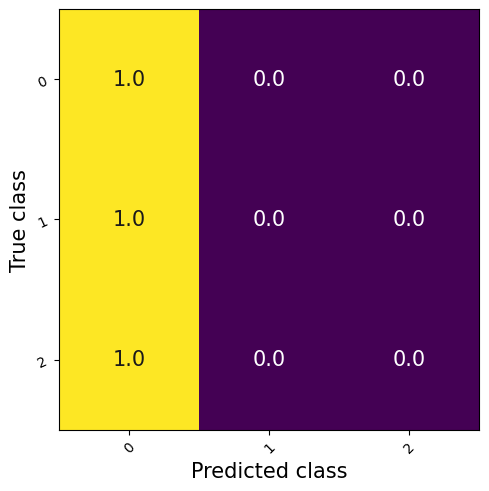

tensor([[2273,    0,    1],
        [  16,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9932, 0.0000, 0.0000])
perclass_precision: tensor([0.9870, 0.0000, 0.0000])
perclass_recall: tensor([0.9996, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 106 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


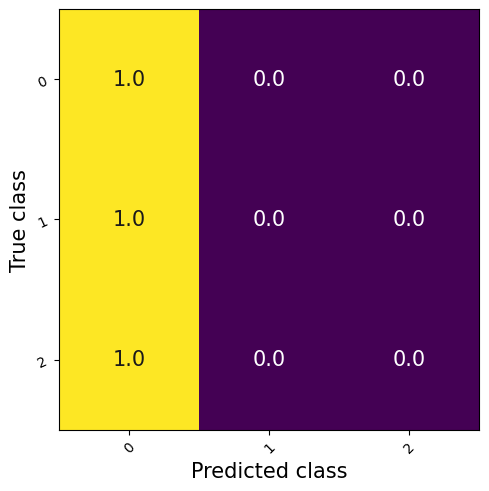

tensor([[2272,    0,    0],
        [  16,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9930, 0.0000, 0.0000])
perclass_precision: tensor([0.9861, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 107 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


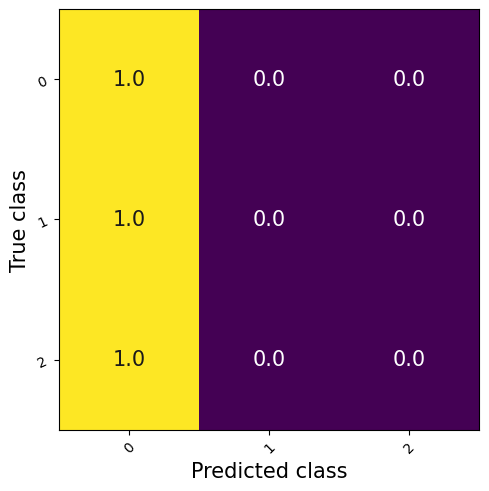

tensor([[2273,    0,    0],
        [  15,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9932, 0.0000, 0.0000])
perclass_precision: tensor([0.9865, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 108 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


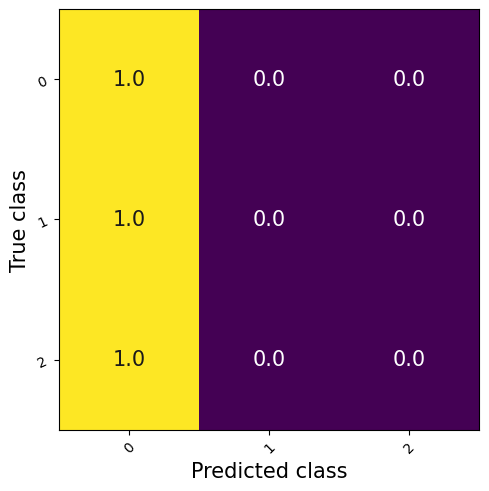

tensor([[2273,    0,    0],
        [  16,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9932, 0.0000, 0.0000])
perclass_precision: tensor([0.9865, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 109 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


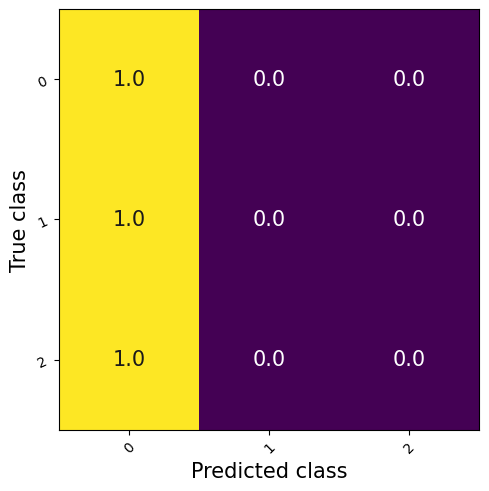

tensor([[2274,    0,    0],
        [  15,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9870, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 110 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


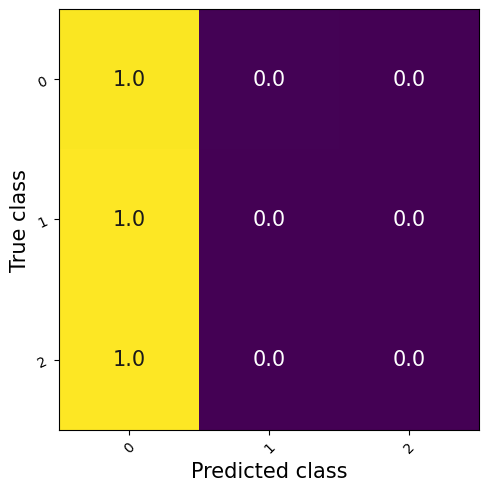

tensor([[2019,    8,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9929, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([0.9961, 0.0000, 0.0000])
MAE overall: 15.5714
MAE per_class: {1: np.float64(15.571428571428571)}
 === Currently Evaluating curr_test_idx: 111 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


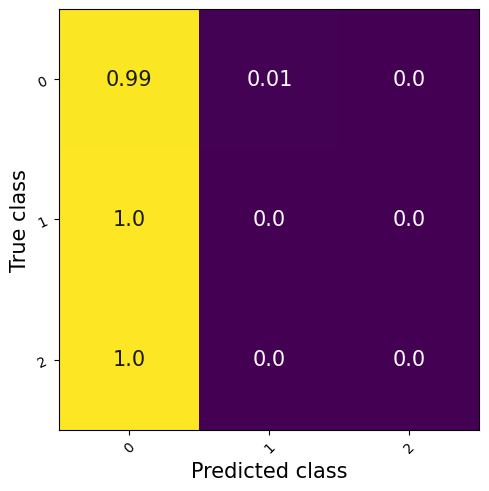

tensor([[1249,    8,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9877, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9936, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(16.0)}
 === Currently Evaluating curr_test_idx: 112 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


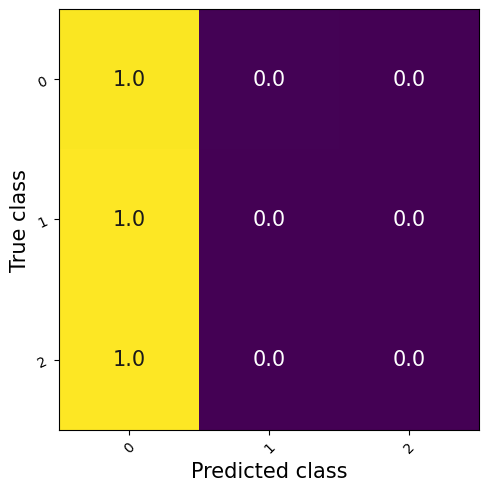

tensor([[1255,    5,    0],
        [  11,    0,    0],
        [   9,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 17.0000
MAE per_class: {1: np.float64(17.0)}
 === Currently Evaluating curr_test_idx: 113 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


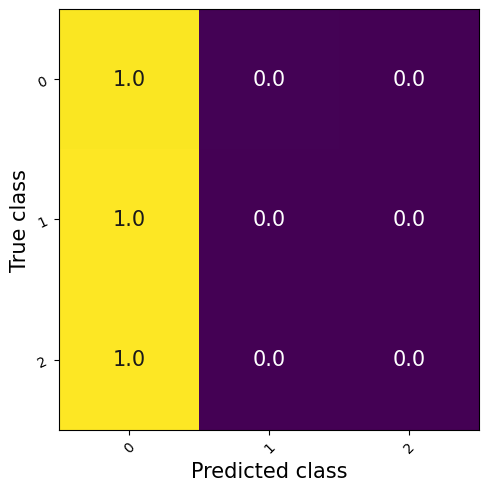

tensor([[1762,    7,    0],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9916, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 15.8571
MAE per_class: {1: np.float64(15.857142857142858)}
 === Currently Evaluating curr_test_idx: 114 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


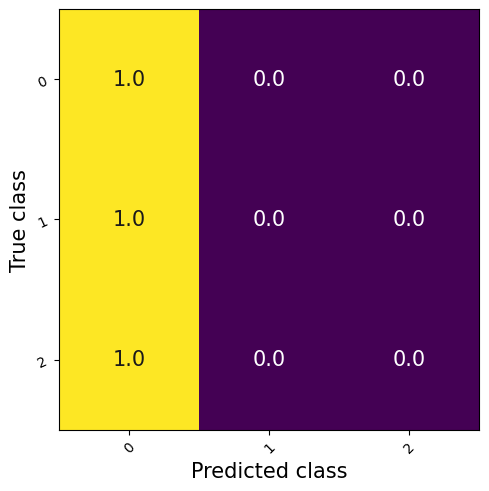

tensor([[2021,    4,    1],
        [  10,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9975, 0.0000, 0.0000])
MAE overall: 17.5000
MAE per_class: {1: np.float64(17.5)}
 === Currently Evaluating curr_test_idx: 115 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


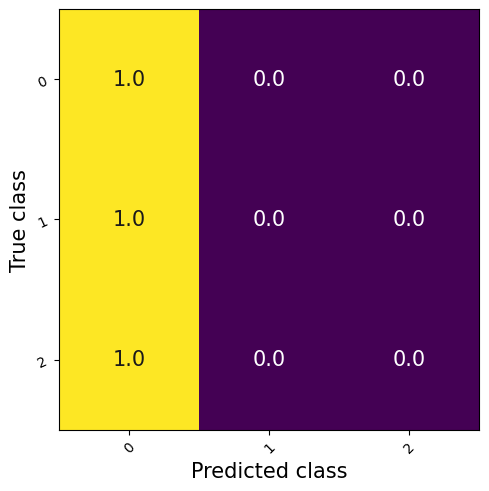

tensor([[1511,    1,    0],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9844, 0.0000, 0.0000])
perclass_recall: tensor([0.9993, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 116 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


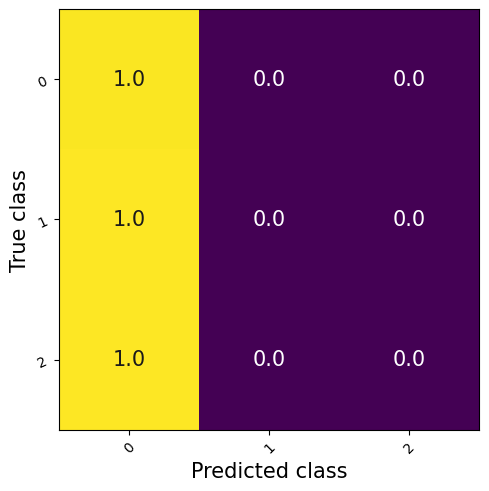

tensor([[1504,    5,    1],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9830, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 18.3333
MAE per_class: {1: np.float64(18.333333333333332)}
 === Currently Evaluating curr_test_idx: 117 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


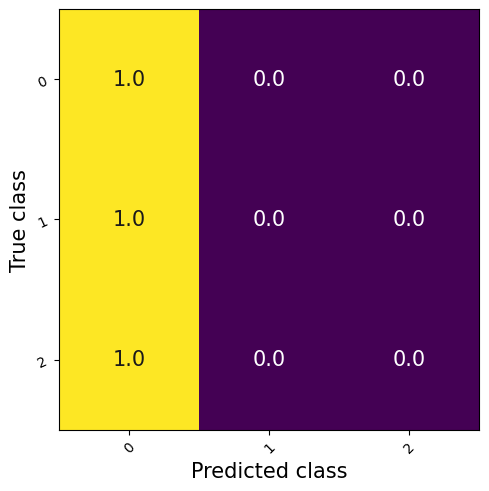

tensor([[1507,    3,    0],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9905, 0.0000, 0.0000])
perclass_precision: tensor([0.9830, 0.0000, 0.0000])
perclass_recall: tensor([0.9980, 0.0000, 0.0000])
MAE overall: 18.5000
MAE per_class: {1: np.float64(18.5)}
 === Currently Evaluating curr_test_idx: 118 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


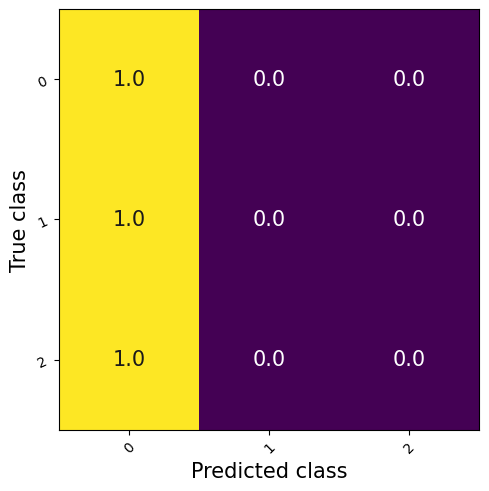

tensor([[1770,    3,    0],
        [   9,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9938, 0.0000, 0.0000])
perclass_precision: tensor([0.9894, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: 13.6667
MAE per_class: {1: np.float64(13.666666666666666)}
 === Currently Evaluating curr_test_idx: 119 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


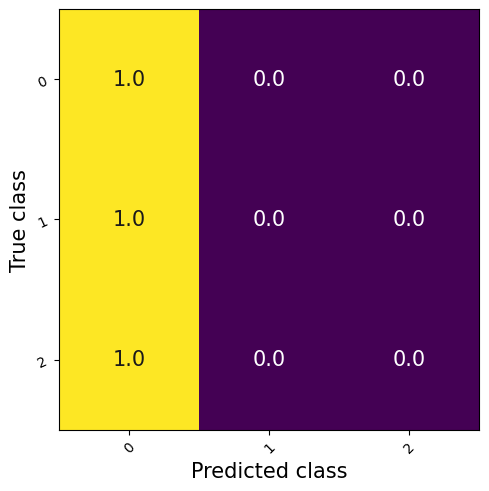

tensor([[1257,    3,    0],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9909, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9976, 0.0000, 0.0000])
MAE overall: 13.3333
MAE per_class: {1: np.float64(13.333333333333334)}
 === Currently Evaluating curr_test_idx: 120 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


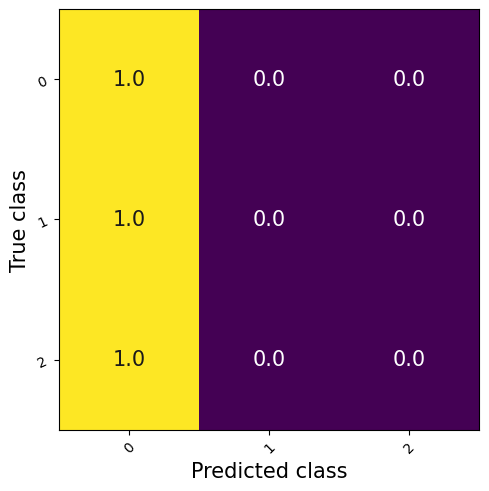

tensor([[1257,    3,    0],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9909, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9976, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
 === Currently Evaluating curr_test_idx: 121 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


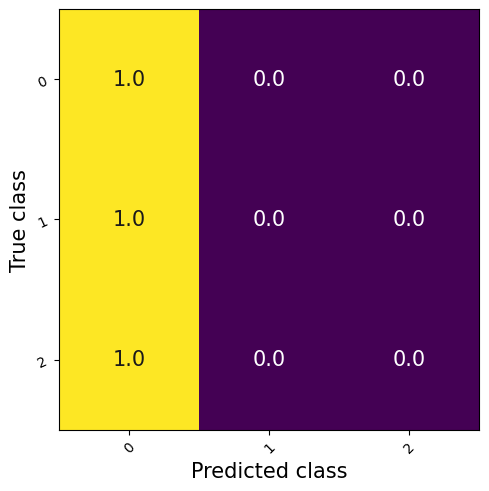

tensor([[1257,    3,    0],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9909, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9976, 0.0000, 0.0000])
MAE overall: 14.3333
MAE per_class: {1: np.float64(14.333333333333334)}
 === Currently Evaluating curr_test_idx: 122 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


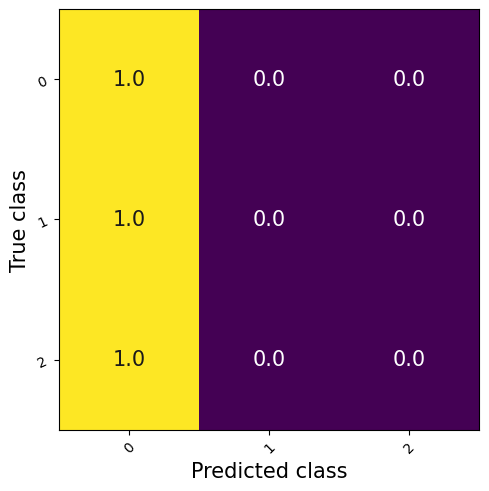

tensor([[1769,    3,    0],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9935, 0.0000, 0.0000])
perclass_precision: tensor([0.9888, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: 12.6667
MAE per_class: {1: np.float64(12.666666666666666)}
 === Currently Evaluating curr_test_idx: 123 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


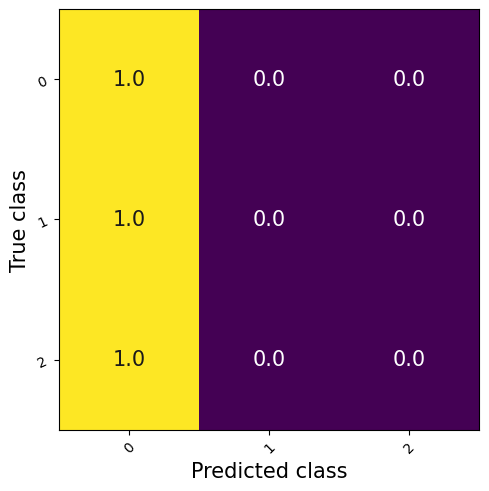

tensor([[2027,    0,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3316 ✨
perclass_f1scores: tensor([0.9948, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 124 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


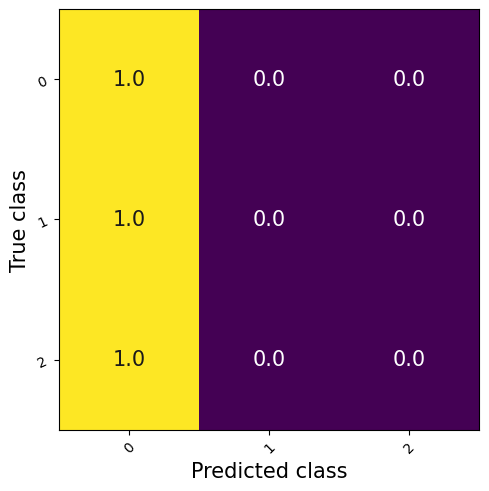

tensor([[1257,    2,    0],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9909, 0.0000, 0.0000])
perclass_precision: tensor([0.9836, 0.0000, 0.0000])
perclass_recall: tensor([0.9984, 0.0000, 0.0000])
MAE overall: 15.0000
MAE per_class: {1: np.float64(15.0)}
 === Currently Evaluating curr_test_idx: 125 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


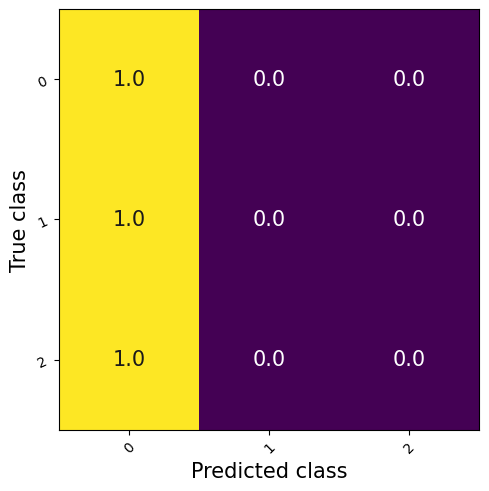

tensor([[1513,    1,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9925, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([0.9993, 0.0000, 0.0000])
MAE overall: 12.0000
MAE per_class: {1: np.float64(12.0)}
 === Currently Evaluating curr_test_idx: 126 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


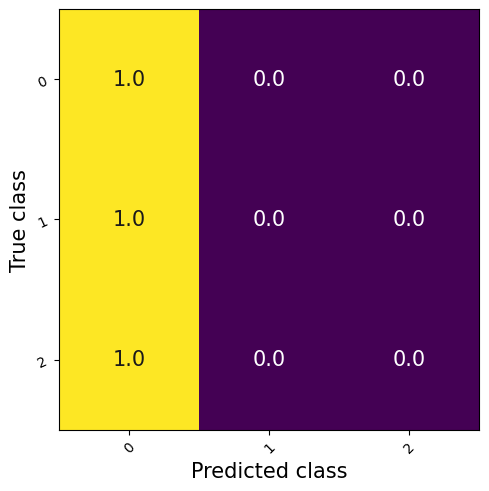

tensor([[1514,    0,    1],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9863, 0.0000, 0.0000])
perclass_recall: tensor([0.9993, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 127 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


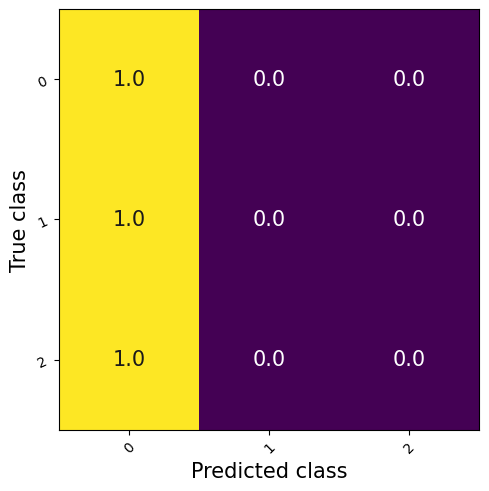

tensor([[2026,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9946, 0.0000, 0.0000])
perclass_precision: tensor([0.9893, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 128 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


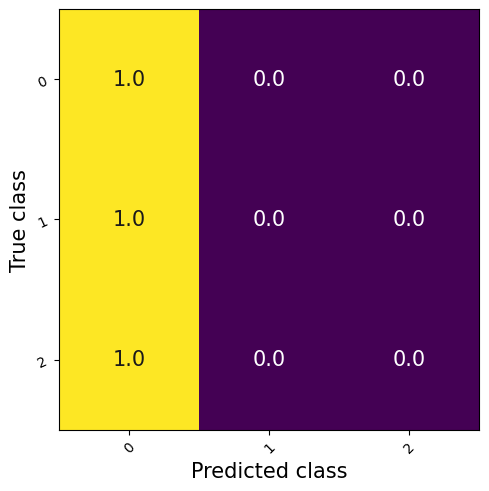

tensor([[2021,    2,    0],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9878, 0.0000, 0.0000])
perclass_recall: tensor([0.9990, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 129 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


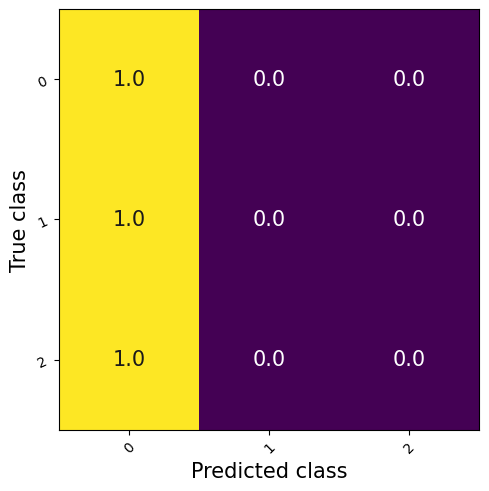

tensor([[1512,    2,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([0.9987, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 130 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


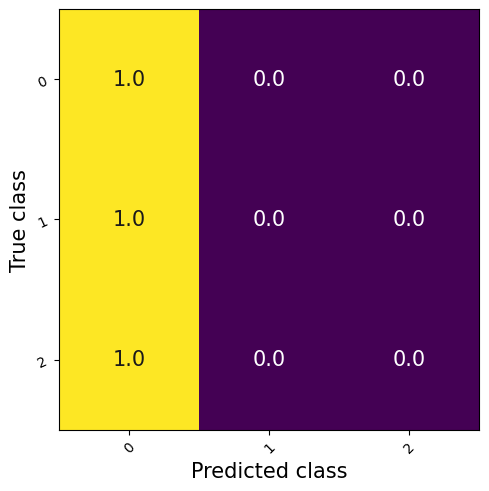

tensor([[1766,    2,    1],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9927, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 131 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


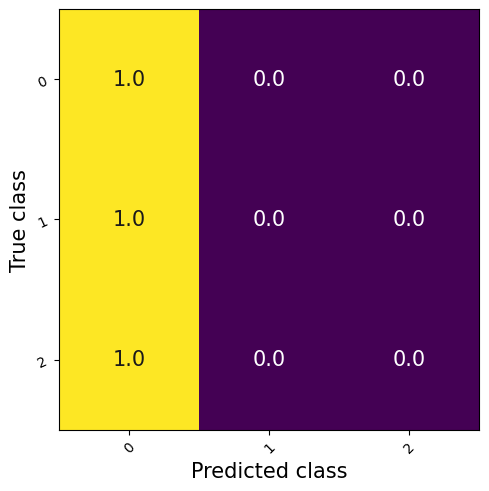

tensor([[1769,    0,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9935, 0.0000, 0.0000])
perclass_precision: tensor([0.9872, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 132 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


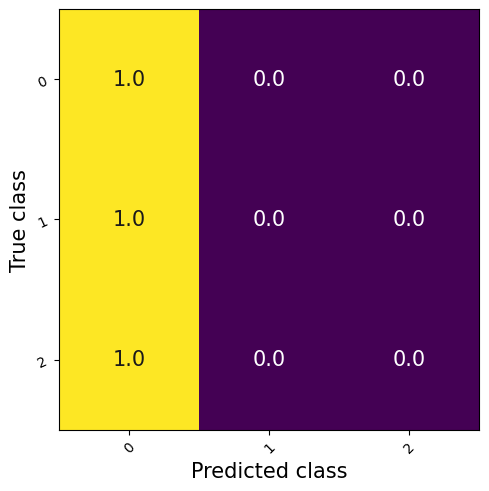

tensor([[2024,    2,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3314 ✨
perclass_f1scores: tensor([0.9941, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9990, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 133 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


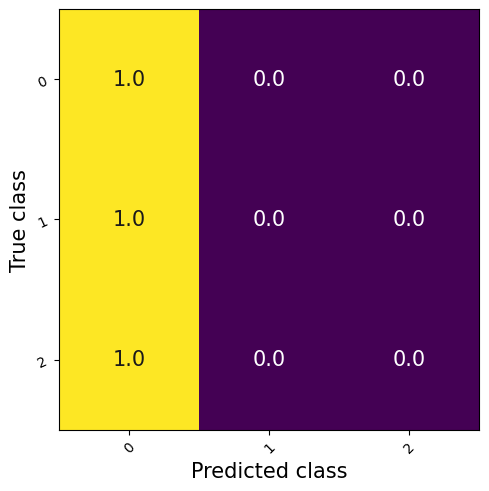

tensor([[2529,    0,    3],
        [  13,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9939, 0.0000, 0.0000])
perclass_precision: tensor([0.9890, 0.0000, 0.0000])
perclass_recall: tensor([0.9988, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 134 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


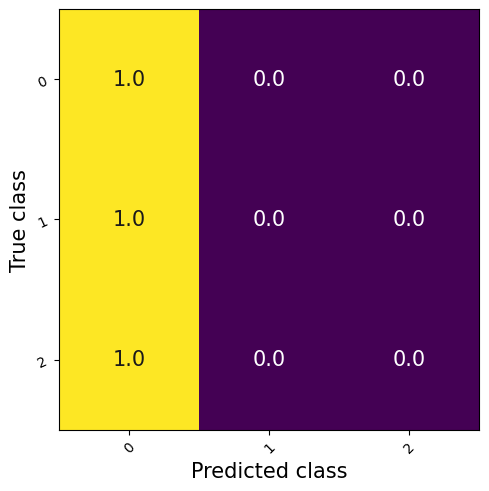

tensor([[2016,    0,    4],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9863, 0.0000, 0.0000])
perclass_recall: tensor([0.9980, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 135 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


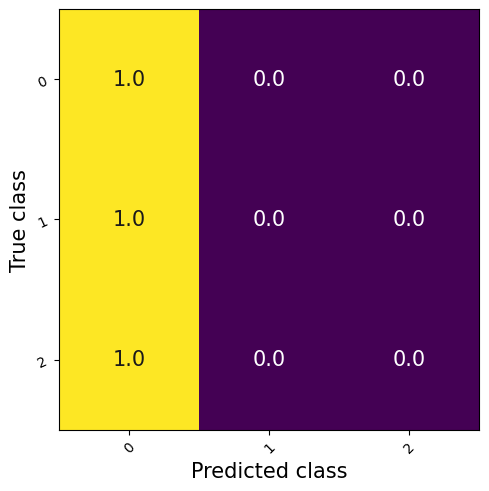

tensor([[1759,    2,    4],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9907, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9966, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 136 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


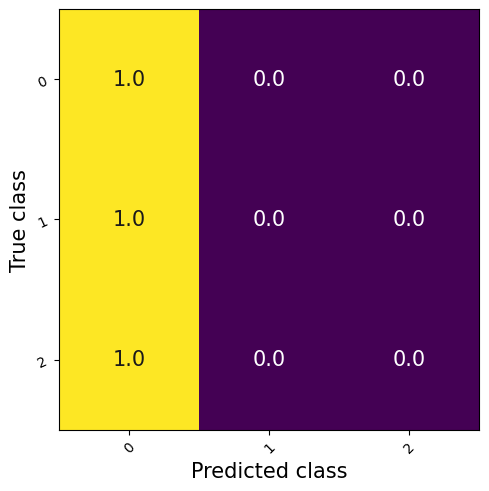

tensor([[1761,    1,    3],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9913, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9977, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 137 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


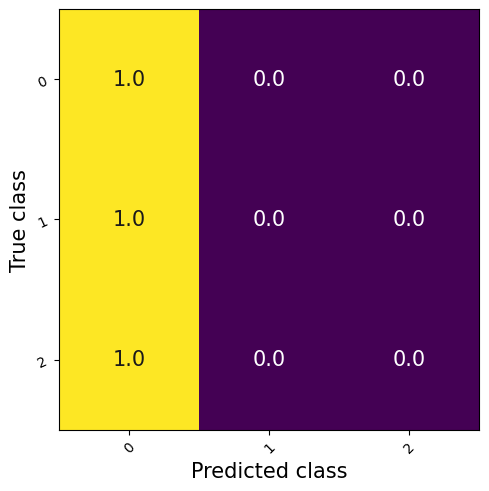

tensor([[2274,    1,    2],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9883, 0.0000, 0.0000])
perclass_recall: tensor([0.9987, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 138 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


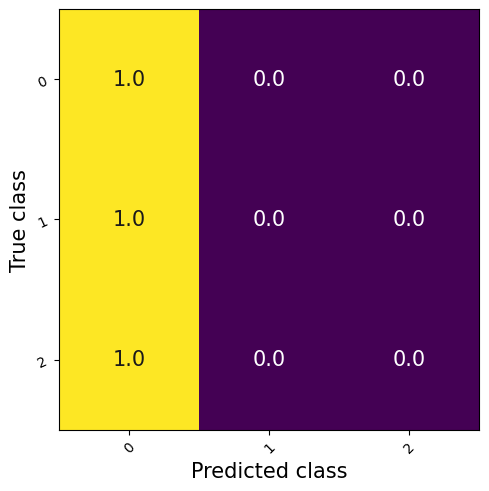

tensor([[1770,    0,    0],
        [  10,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9938, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 139 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


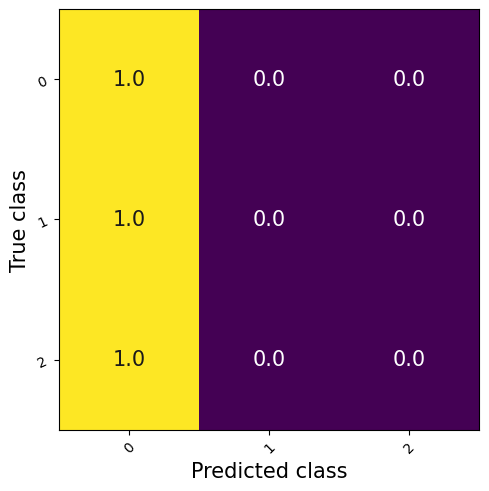

tensor([[1769,    1,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9935, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([0.9994, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
 === Currently Evaluating curr_test_idx: 140 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


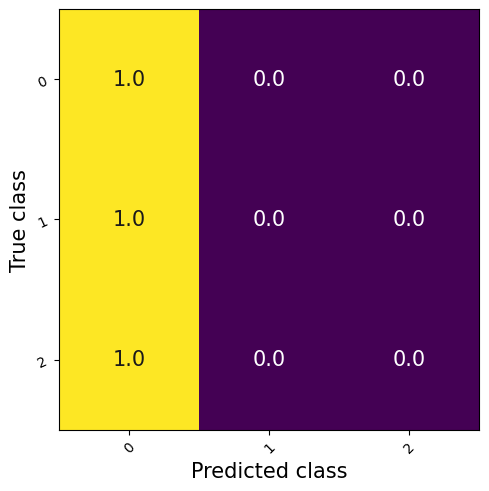

tensor([[1511,    2,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9850, 0.0000, 0.0000])
perclass_recall: tensor([0.9987, 0.0000, 0.0000])
MAE overall: 12.5000
MAE per_class: {1: np.float64(12.5)}
 === Currently Evaluating curr_test_idx: 141 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


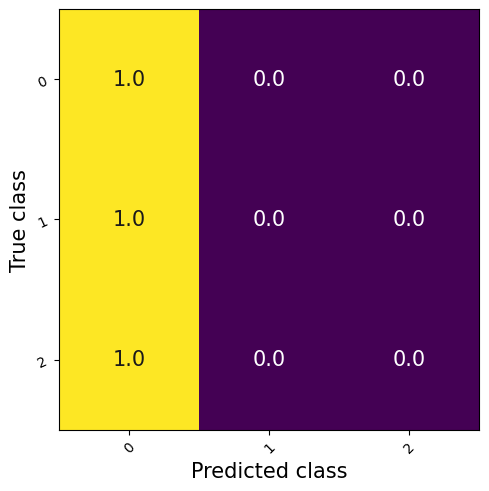

tensor([[1511,    0,    0],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9837, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 142 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


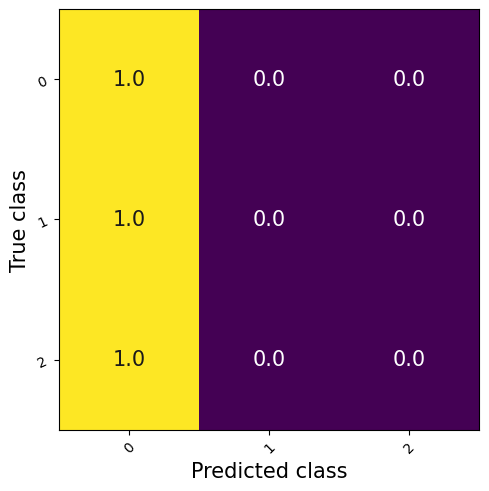

tensor([[2021,    0,    0],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9934, 0.0000, 0.0000])
perclass_precision: tensor([0.9868, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 143 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


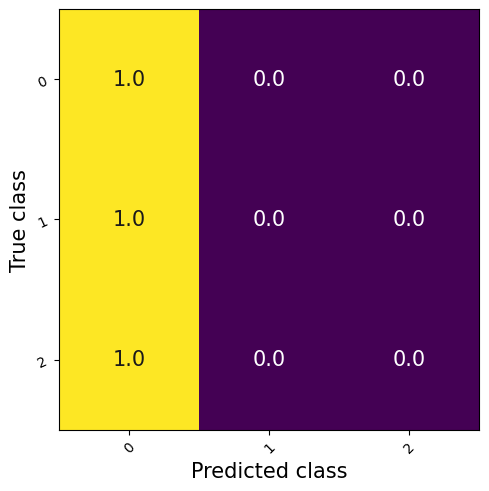

tensor([[1509,    0,    0],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9911, 0.0000, 0.0000])
perclass_precision: tensor([0.9824, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 144 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


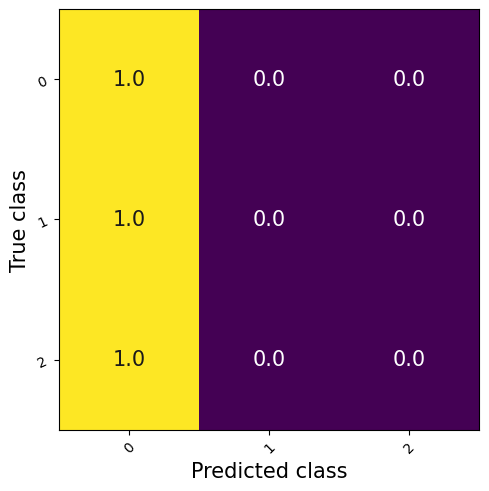

tensor([[1509,    0,    0],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9911, 0.0000, 0.0000])
perclass_precision: tensor([0.9824, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 145 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


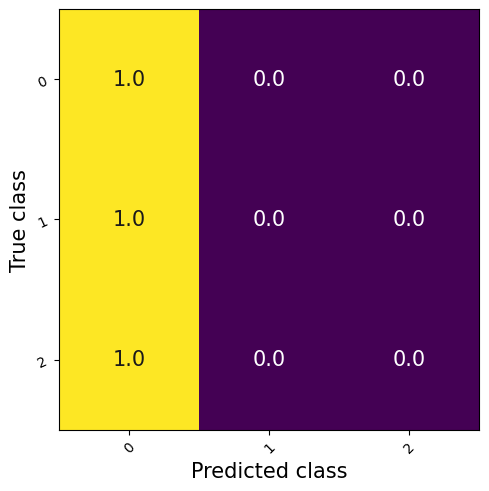

tensor([[1509,    0,    0],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9911, 0.0000, 0.0000])
perclass_precision: tensor([0.9824, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 146 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


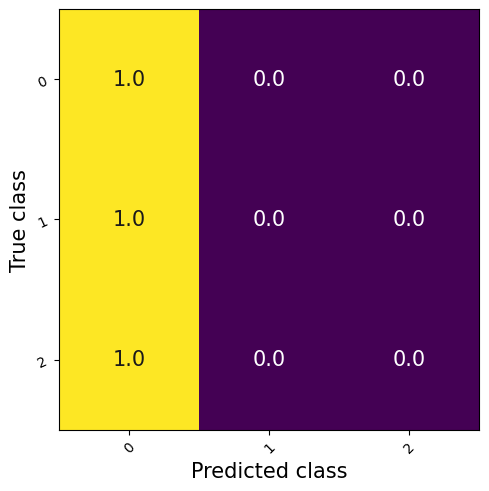

tensor([[1509,    0,    0],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9911, 0.0000, 0.0000])
perclass_precision: tensor([0.9824, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 147 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


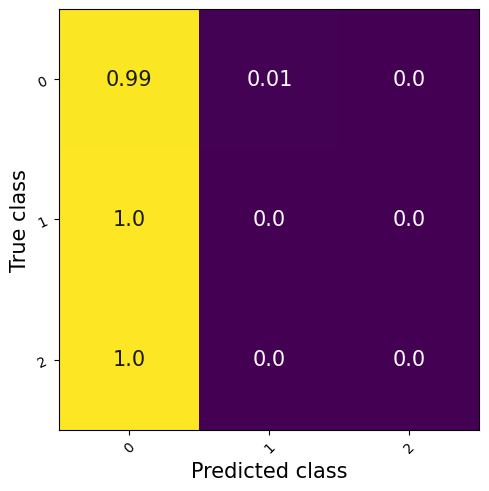

tensor([[1505,    8,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9898, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: 17.1429
MAE per_class: {1: np.float64(17.142857142857142)}
 === Currently Evaluating curr_test_idx: 148 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


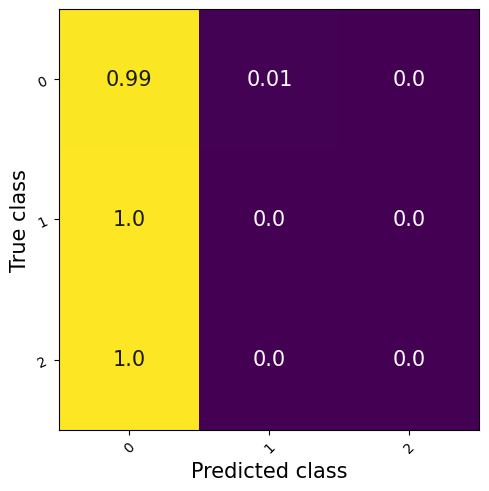

tensor([[1248,    8,    1],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3291 ✨
perclass_f1scores: tensor([0.9873, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9928, 0.0000, 0.0000])
MAE overall: 16.1667
MAE per_class: {1: np.float64(16.166666666666668)}
 === Currently Evaluating curr_test_idx: 149 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02npy.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


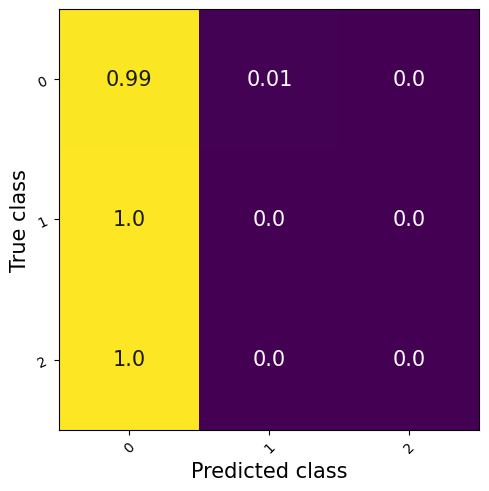

tensor([[1248,    8,    1],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3291 ✨
perclass_f1scores: tensor([0.9873, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9928, 0.0000, 0.0000])
MAE overall: 16.1667
MAE per_class: {1: np.float64(16.166666666666668)}
 === Currently Evaluating curr_test_idx: 150 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


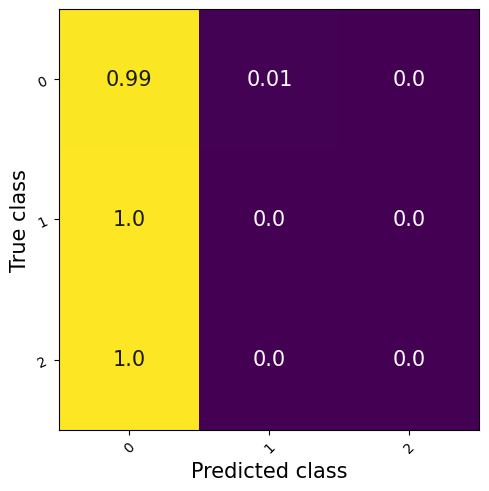

tensor([[1250,    8,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9827, 0.0000, 0.0000])
perclass_recall: tensor([0.9936, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(16.0)}
 === Currently Evaluating curr_test_idx: 151 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


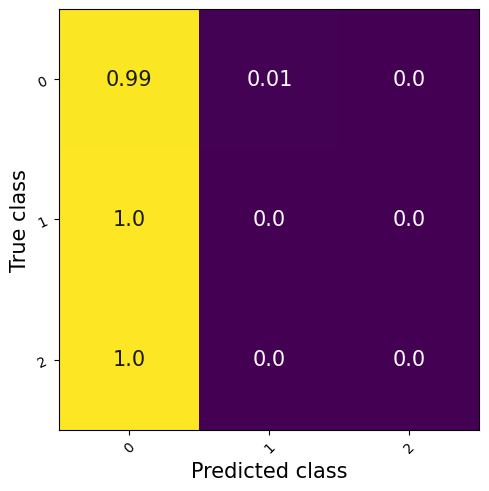

tensor([[1249,    7,    1],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9877, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9936, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(16.0)}
 === Currently Evaluating curr_test_idx: 152 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


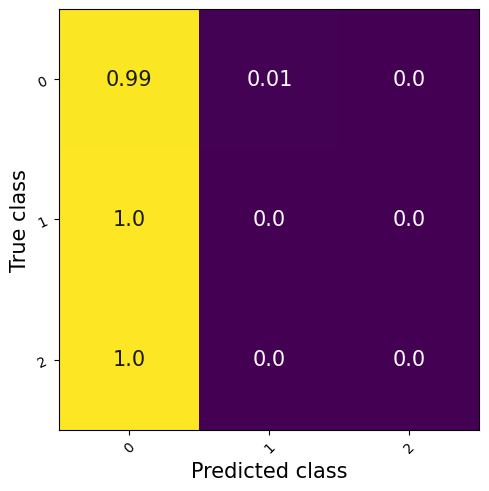

tensor([[1249,    7,    1],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9877, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9936, 0.0000, 0.0000])
MAE overall: 16.3333
MAE per_class: {1: np.float64(16.333333333333332)}
 === Currently Evaluating curr_test_idx: 153 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


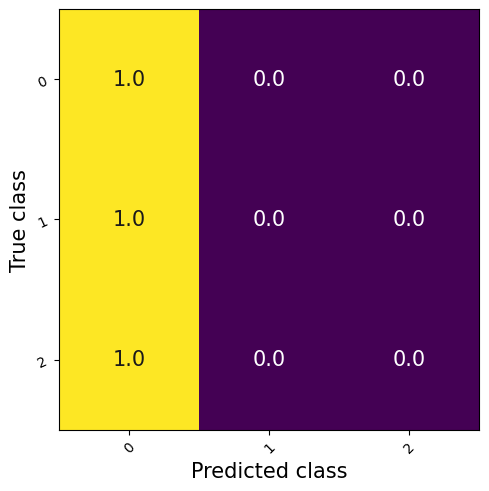

tensor([[1760,    2,    3],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9972, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 154 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


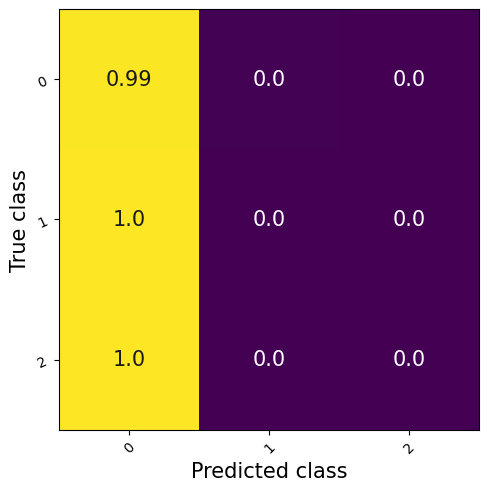

tensor([[1247,    5,    4],
        [  13,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3290 ✨
perclass_f1scores: tensor([0.9869, 0.0000, 0.0000])
perclass_precision: tensor([0.9811, 0.0000, 0.0000])
perclass_recall: tensor([0.9928, 0.0000, 0.0000])
MAE overall: 17.5000
MAE per_class: {1: np.float64(17.5)}
 === Currently Evaluating curr_test_idx: 155 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


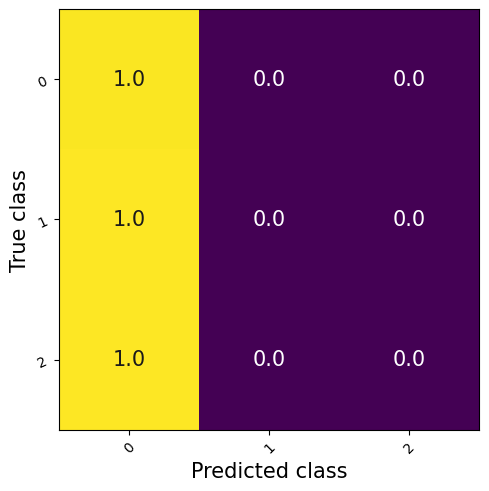

tensor([[1501,    4,    3],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9885, 0.0000, 0.0000])
perclass_precision: tensor([0.9817, 0.0000, 0.0000])
perclass_recall: tensor([0.9954, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 156 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


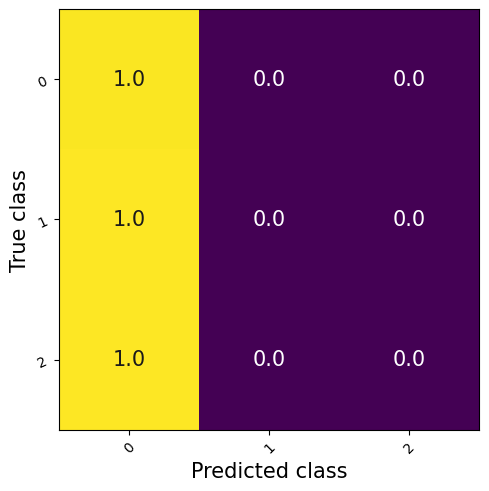

tensor([[1250,    3,    3],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9812, 0.0000, 0.0000])
perclass_recall: tensor([0.9952, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 157 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


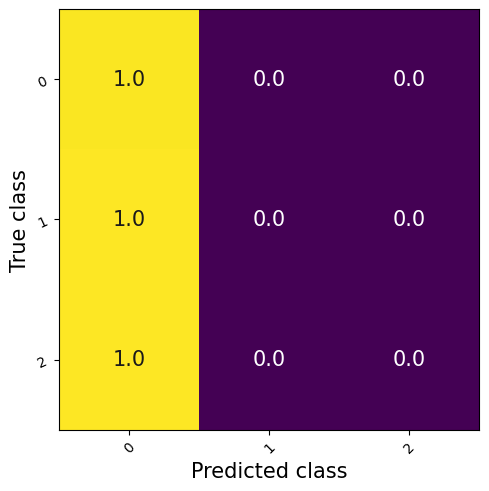

tensor([[1251,    1,    4],
        [  13,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9885, 0.0000, 0.0000])
perclass_precision: tensor([0.9812, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 158 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


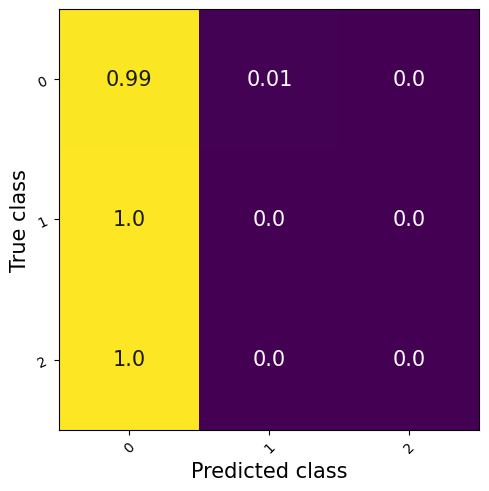

tensor([[1762,    9,    1],
        [   9,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9916, 0.0000, 0.0000])
perclass_precision: tensor([0.9888, 0.0000, 0.0000])
perclass_recall: tensor([0.9944, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 159 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


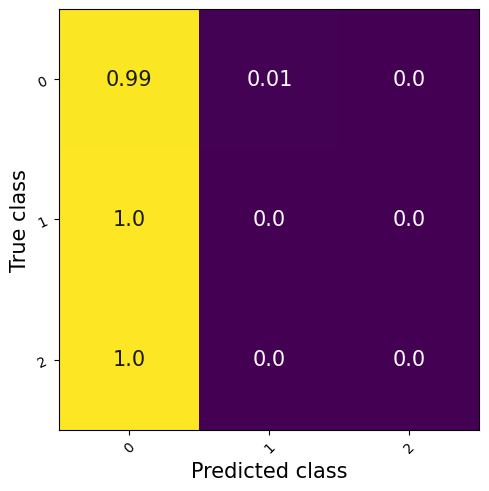

tensor([[1502,   11,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3296 ✨
perclass_f1scores: tensor([0.9888, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 160 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


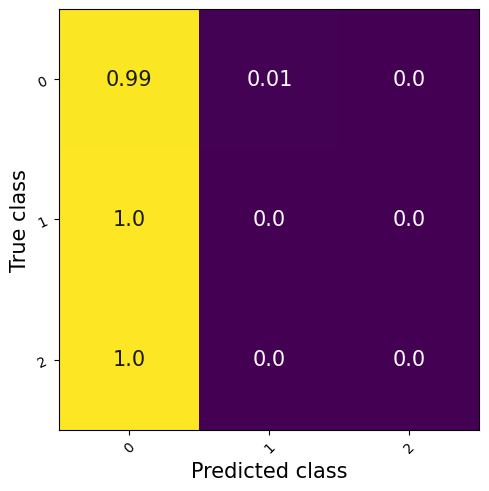

tensor([[1505,   10,    0],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9898, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 161 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


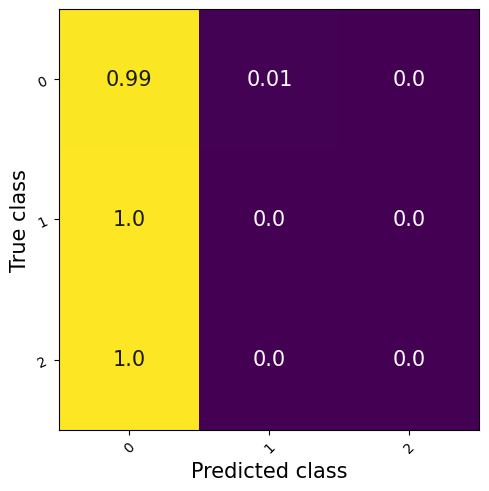

tensor([[1507,    9,    0],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9905, 0.0000, 0.0000])
perclass_precision: tensor([0.9869, 0.0000, 0.0000])
perclass_recall: tensor([0.9941, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 162 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


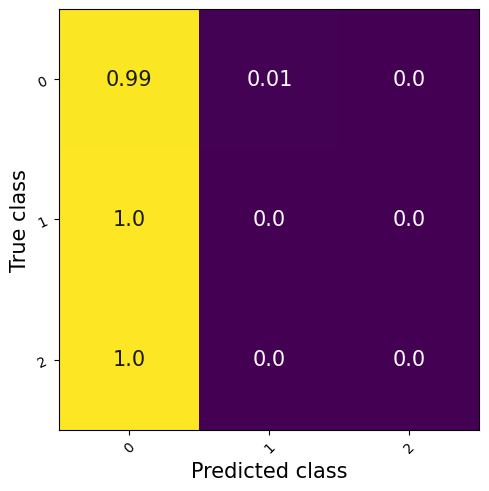

tensor([[1506,   10,    0],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9869, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 163 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


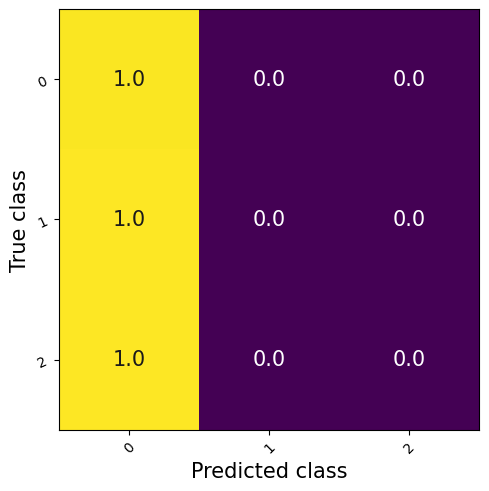

tensor([[2776,   10,    1],
        [  14,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([0.9961, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 164 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


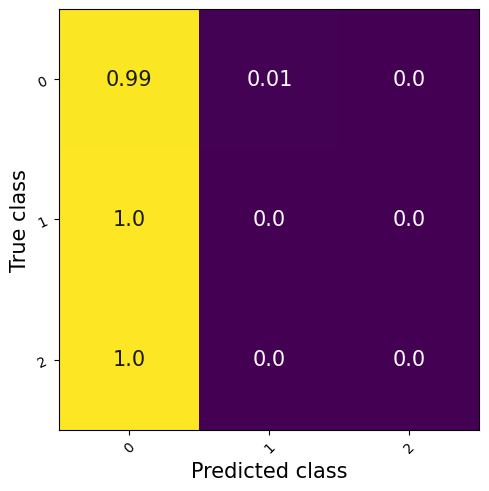

tensor([[1498,   11,    0],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9875, 0.0000, 0.0000])
perclass_precision: tensor([0.9823, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: 15.0000
MAE per_class: {1: np.float64(15.0)}
 === Currently Evaluating curr_test_idx: 165 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


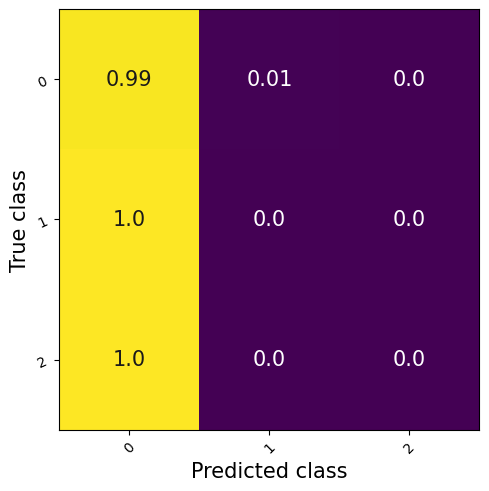

tensor([[1500,   10,    2],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9921, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 166 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


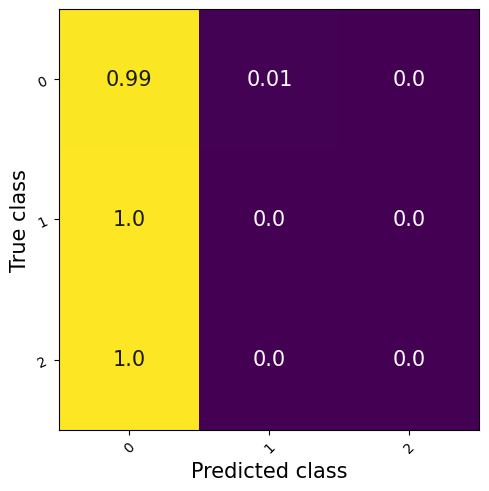

tensor([[1499,    9,    2],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3293 ✨
perclass_f1scores: tensor([0.9878, 0.0000, 0.0000])
perclass_precision: tensor([0.9830, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 167 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


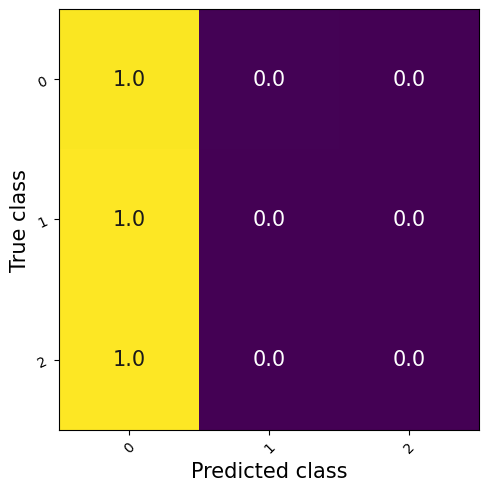

tensor([[2269,   10,    0],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9923, 0.0000, 0.0000])
perclass_precision: tensor([0.9891, 0.0000, 0.0000])
perclass_recall: tensor([0.9956, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 168 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


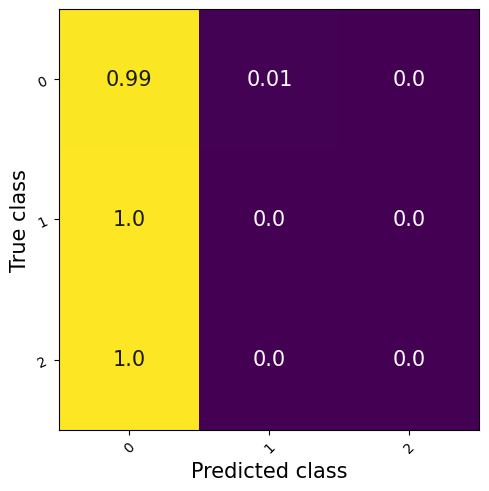

tensor([[1500,    9,    1],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9830, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 169 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


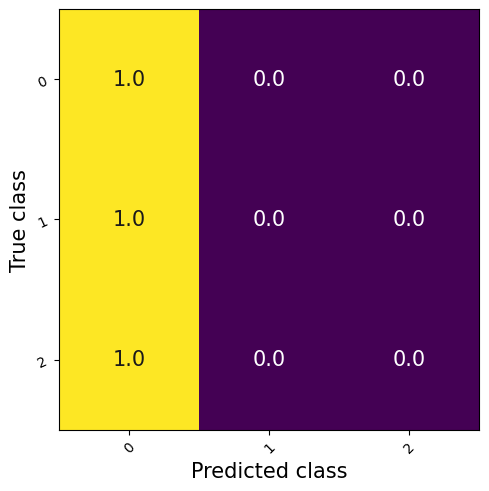

tensor([[2029,    0,    0],
        [   9,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3318 ✨
perclass_f1scores: tensor([0.9953, 0.0000, 0.0000])
perclass_precision: tensor([0.9907, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 170 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


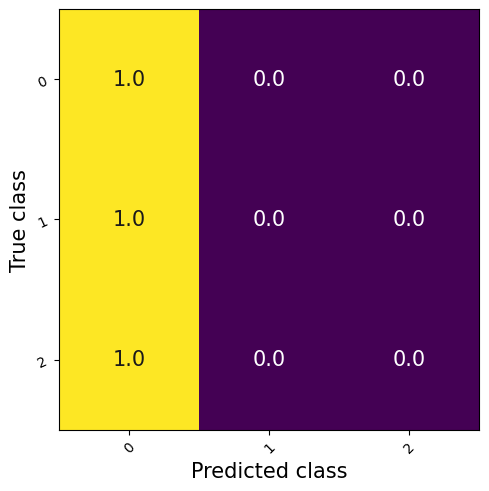

tensor([[1514,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 171 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


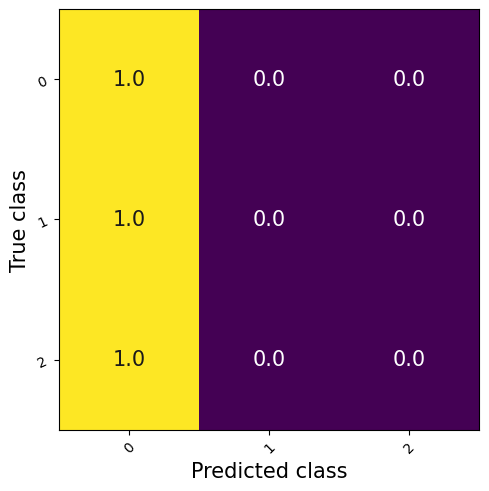

tensor([[1517,    0,    0],
        [  10,    0,    0],
        [   9,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9938, 0.0000, 0.0000])
perclass_precision: tensor([0.9876, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 172 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


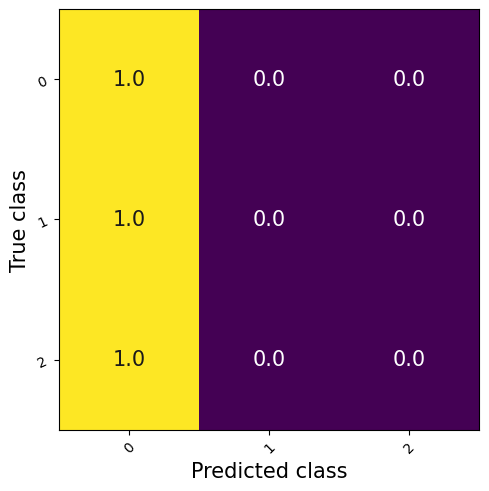

tensor([[1770,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9938, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 173 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


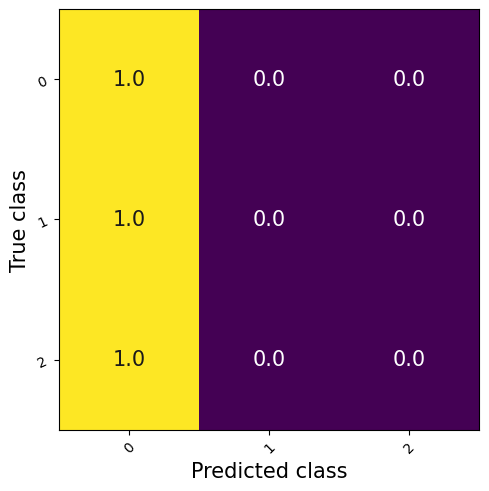

tensor([[1513,    1,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9925, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([0.9993, 0.0000, 0.0000])
MAE overall: 15.0000
MAE per_class: {1: np.float64(15.0)}
 === Currently Evaluating curr_test_idx: 174 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


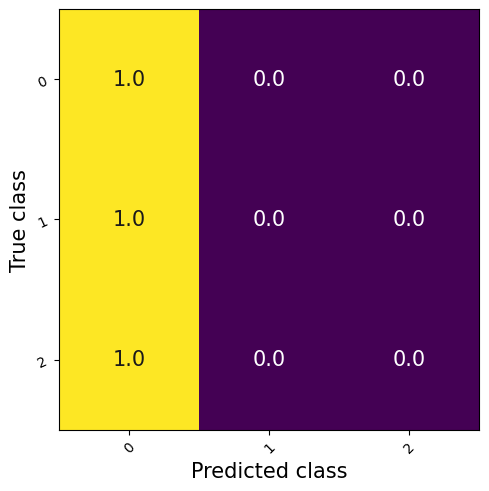

tensor([[1514,    0,    0],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 175 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


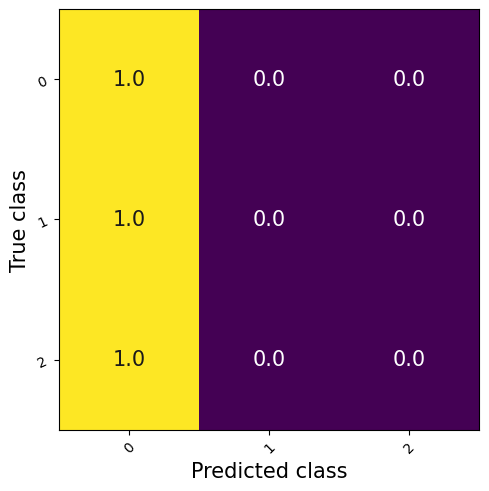

tensor([[2025,    0,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9944, 0.0000, 0.0000])
perclass_precision: tensor([0.9888, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 176 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


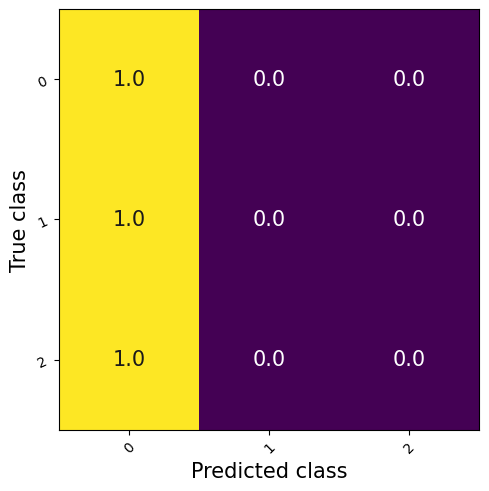

tensor([[2023,    0,    1],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3313 ✨
perclass_f1scores: tensor([0.9939, 0.0000, 0.0000])
perclass_precision: tensor([0.9883, 0.0000, 0.0000])
perclass_recall: tensor([0.9995, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 177 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


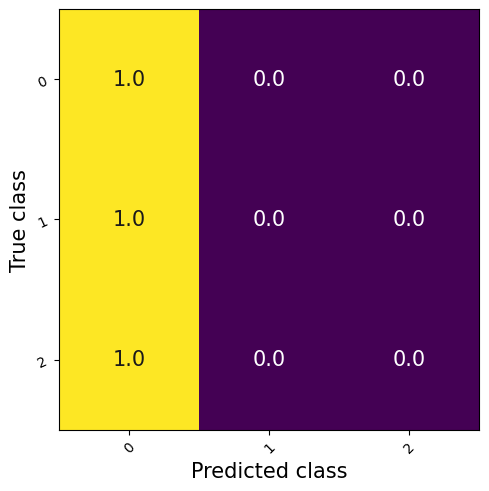

tensor([[2025,    0,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9944, 0.0000, 0.0000])
perclass_precision: tensor([0.9888, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 178 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


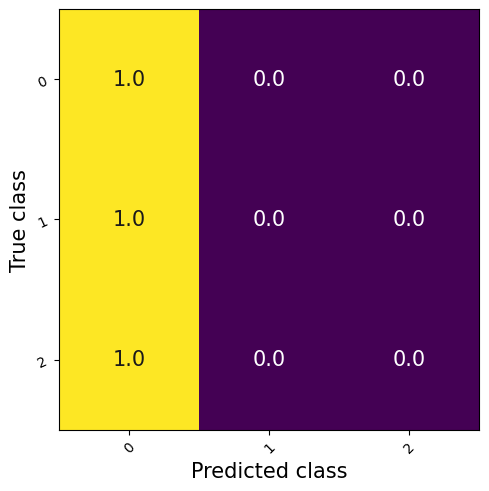

tensor([[1766,    0,    1],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9927, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9994, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 179 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


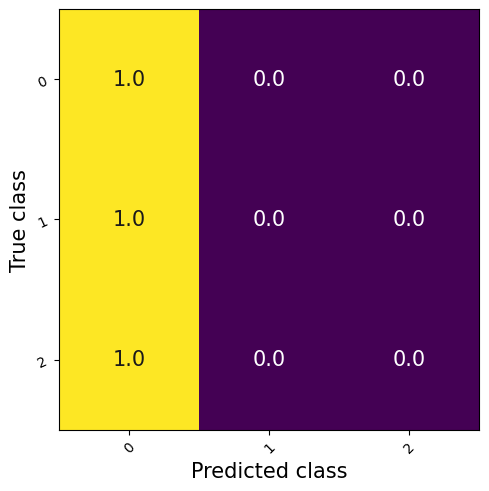

tensor([[1767,    0,    0],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9930, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 180 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


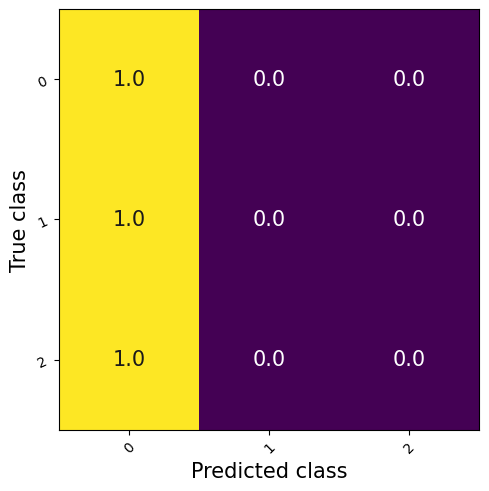

tensor([[2785,    1,    1],
        [  14,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3315 ✨
perclass_f1scores: tensor([0.9945, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([0.9993, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 181 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


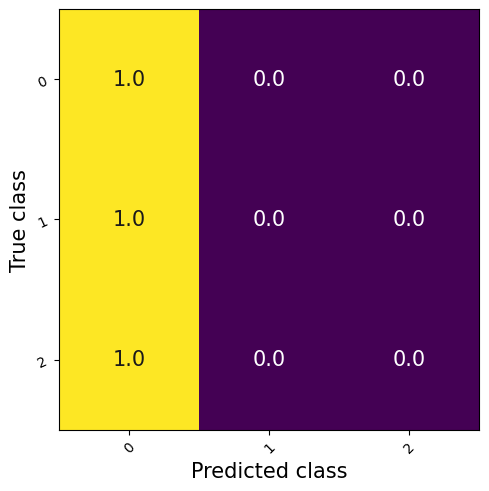

tensor([[2783,    0,    0],
        [  17,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3314 ✨
perclass_f1scores: tensor([0.9941, 0.0000, 0.0000])
perclass_precision: tensor([0.9883, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 182 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


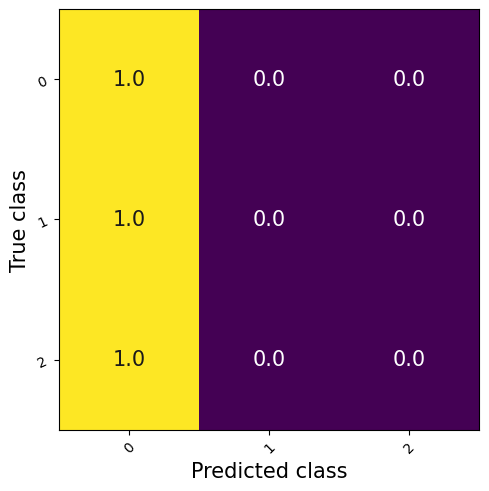

tensor([[2270,    0,    0],
        [  18,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9926, 0.0000, 0.0000])
perclass_precision: tensor([0.9852, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 183 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


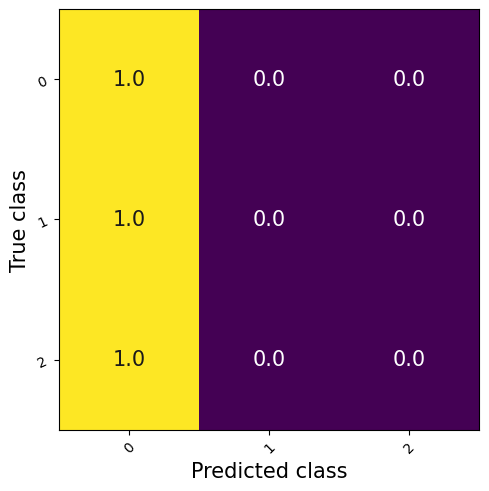

tensor([[2271,    0,    1],
        [  17,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9861, 0.0000, 0.0000])
perclass_recall: tensor([0.9996, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 184 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


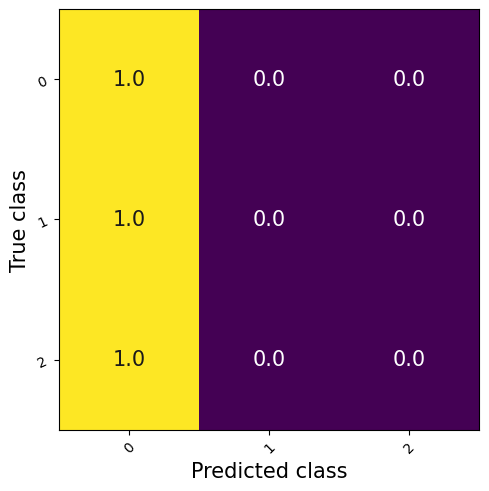

tensor([[2271,    0,    0],
        [  17,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9857, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 185 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


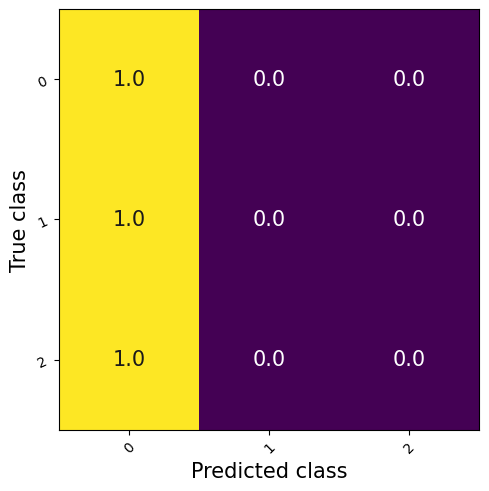

tensor([[2526,    0,    0],
        [  18,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3311 ✨
perclass_f1scores: tensor([0.9933, 0.0000, 0.0000])
perclass_precision: tensor([0.9867, 0.0000, 0.0000])
perclass_recall: tensor([1., 0., 0.])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 186 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (12, 256, 7)
all_arrays shape: (12, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([12, 256, 6])
Pred torch.Size([3072]) Target torch.Size([3072])


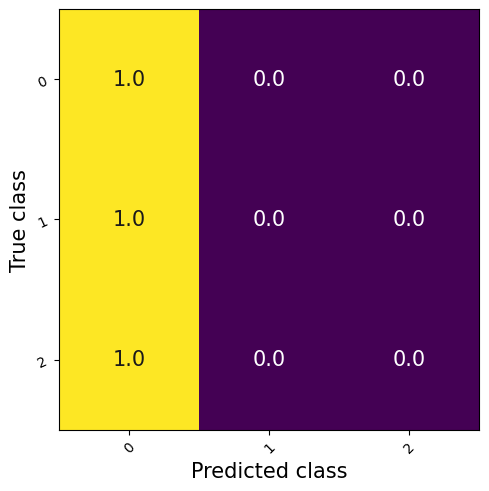

tensor([[3046,    3,    0],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3319 ✨
perclass_f1scores: tensor([0.9958, 0.0000, 0.0000])
perclass_precision: tensor([0.9925, 0.0000, 0.0000])
perclass_recall: tensor([0.9990, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 187 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


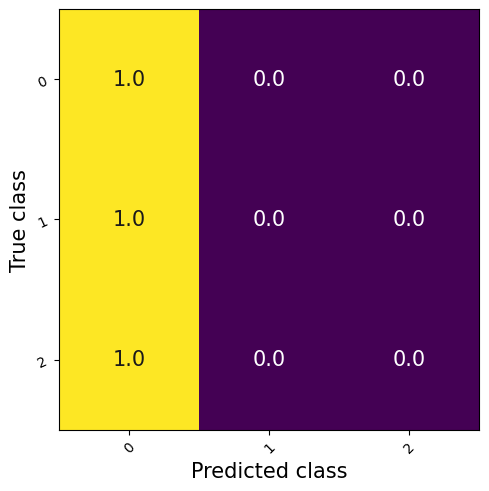

tensor([[1766,    2,    0],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9927, 0.0000, 0.0000])
perclass_precision: tensor([0.9866, 0.0000, 0.0000])
perclass_recall: tensor([0.9989, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 188 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


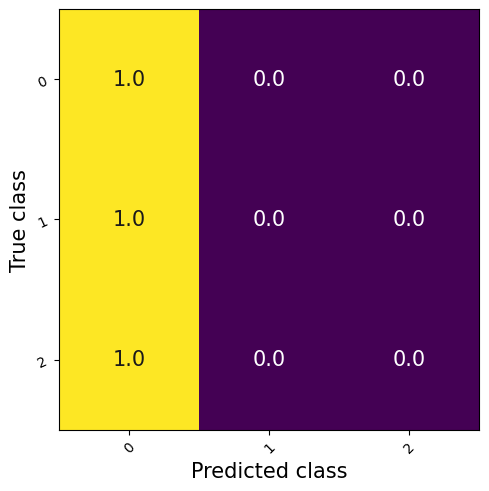

tensor([[1766,    3,    0],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9927, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 189 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


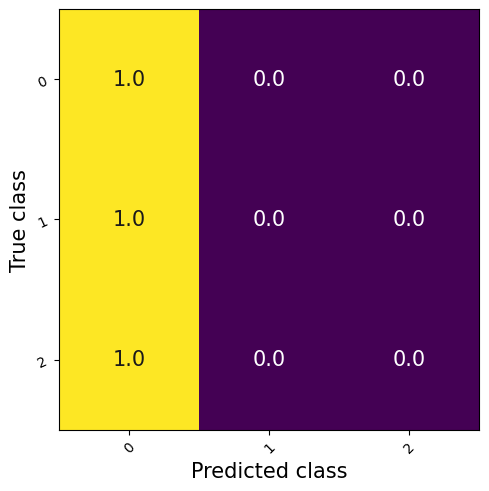

tensor([[1765,    3,    0],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9866, 0.0000, 0.0000])
perclass_recall: tensor([0.9983, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 190 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


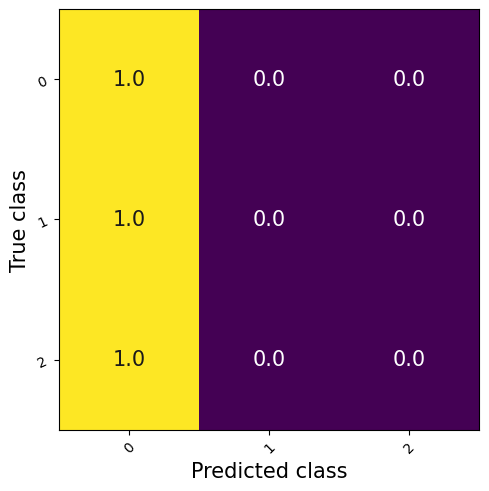

tensor([[2020,    4,    0],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9931, 0.0000, 0.0000])
perclass_precision: tensor([0.9883, 0.0000, 0.0000])
perclass_recall: tensor([0.9980, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 191 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


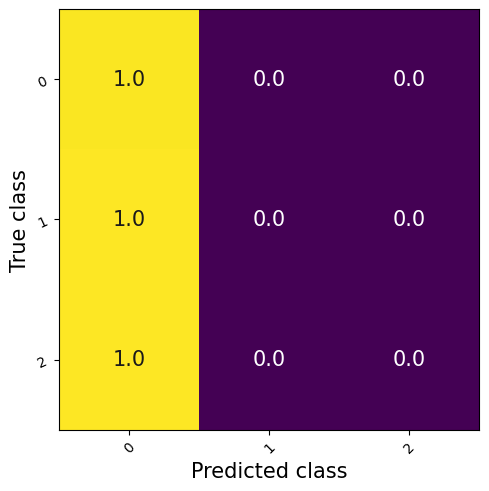

tensor([[2275,    7,    3],
        [   9,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9937, 0.0000, 0.0000])
perclass_precision: tensor([0.9917, 0.0000, 0.0000])
perclass_recall: tensor([0.9956, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 192 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


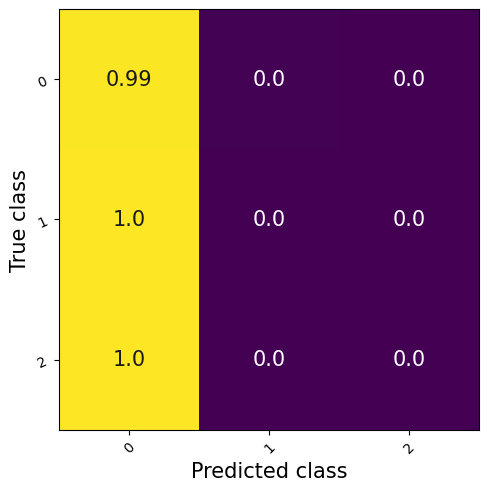

tensor([[1509,    7,    1],
        [  10,    0,    0],
        [   9,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9911, 0.0000, 0.0000])
perclass_precision: tensor([0.9876, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 193 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


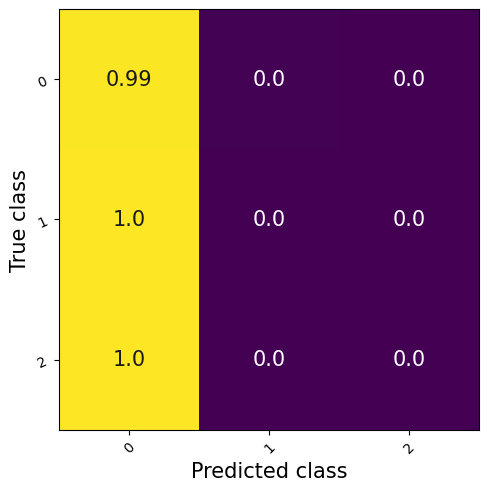

tensor([[1508,    7,    1],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9908, 0.0000, 0.0000])
perclass_precision: tensor([0.9869, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
 === Currently Evaluating curr_test_idx: 194 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


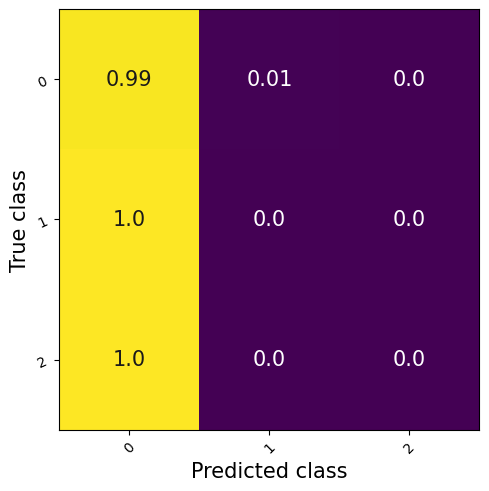

tensor([[1251,    8,    2],
        [   9,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9885, 0.0000, 0.0000])
perclass_precision: tensor([0.9850, 0.0000, 0.0000])
perclass_recall: tensor([0.9921, 0.0000, 0.0000])
MAE overall: 15.0000
MAE per_class: {1: np.float64(15.0)}
 === Currently Evaluating curr_test_idx: 195 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


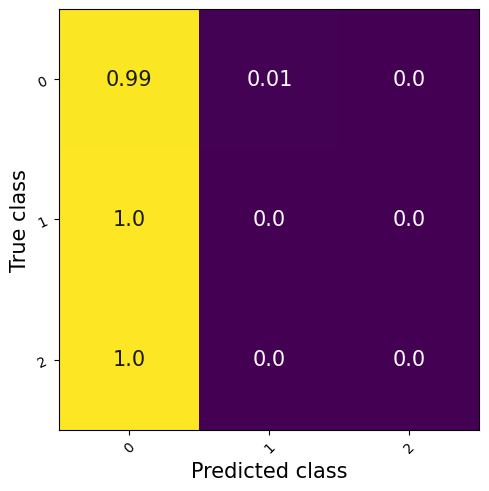

tensor([[1504,    9,    1],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
 === Currently Evaluating curr_test_idx: 196 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


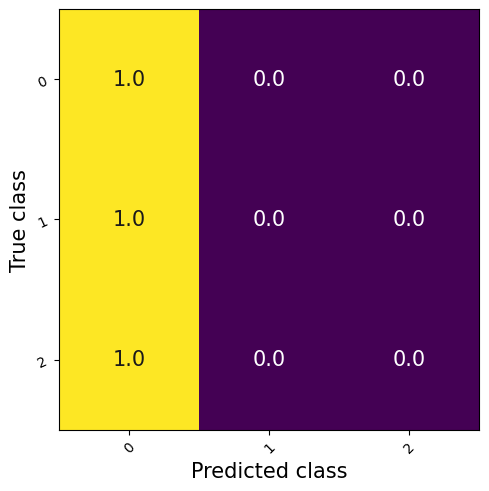

tensor([[1511,    2,    2],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9863, 0.0000, 0.0000])
perclass_recall: tensor([0.9974, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 197 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


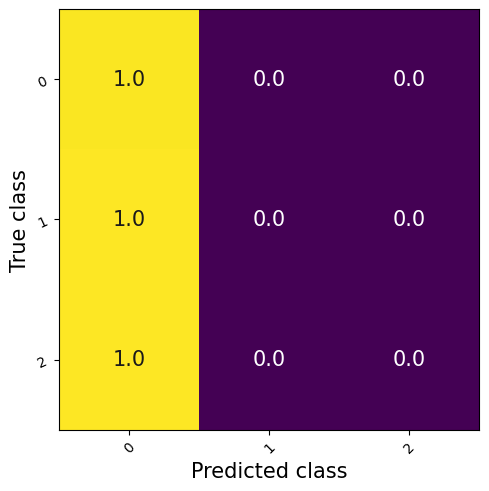

tensor([[1760,    1,    6],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 198 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


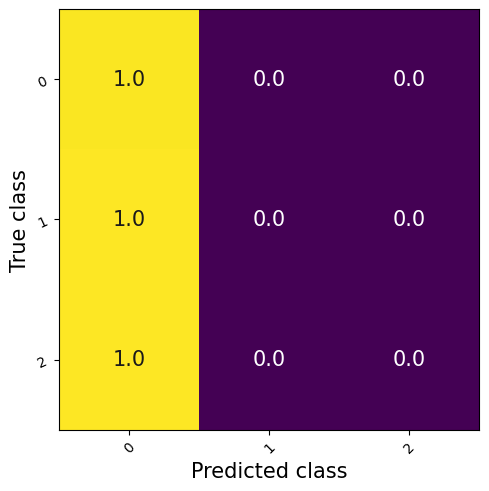

tensor([[1760,    1,    6],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 199 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


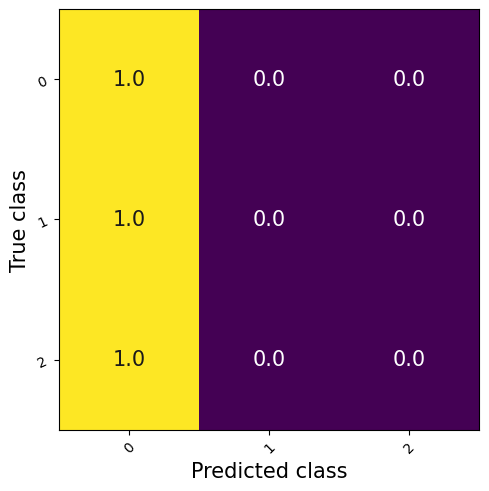

tensor([[2016,    0,    7],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9878, 0.0000, 0.0000])
perclass_recall: tensor([0.9965, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 200 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


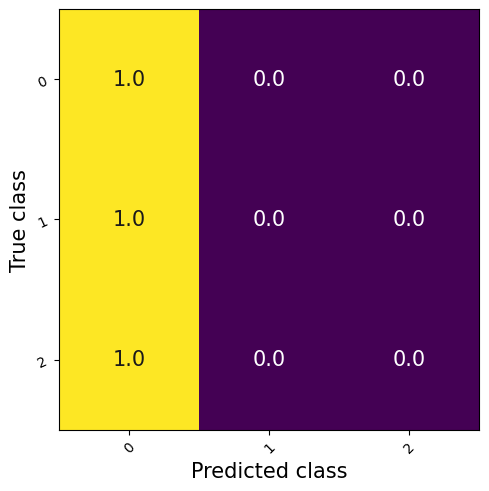

tensor([[2271,    1,    6],
        [  13,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9928, 0.0000, 0.0000])
perclass_precision: tensor([0.9887, 0.0000, 0.0000])
perclass_recall: tensor([0.9969, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
 === Currently Evaluating curr_test_idx: 201 === 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


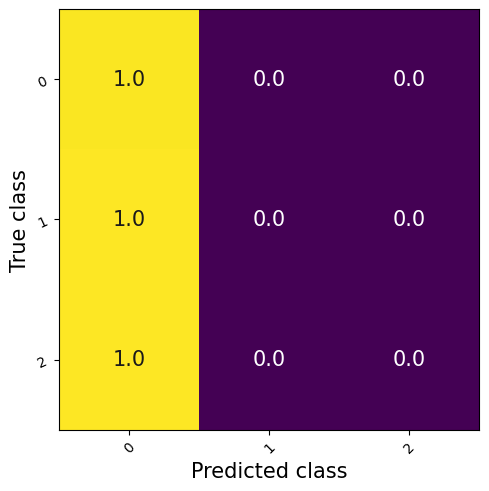

tensor([[2013,    1,    7],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9914, 0.0000, 0.0000])
perclass_precision: tensor([0.9868, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}


In [57]:
testset_f1_scores = []
testset_pc_f1_scores = []
testset_pc_precision = []
testset_pc_recall = []
testset_mae = []
testset_pc_mae = []
testset_cm = []
group_assigment = []

use_internal_train_stats = True
for curr_test_idx in cur_set_to_test.tolist():
    print(f" === Currently Evaluating curr_test_idx: {curr_test_idx} === ")
    if use_internal_train_stats:
        train_stat = {'mean': np.array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781, 0.86179046]), 
                      'std': np.array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,5.12151813]),}
        # global_mean = train_stat["mean"]
        # global_var = train_stat["std"]
    else:
        # global_mean = np.zeros(6)
        # global_var = np.ones(6)
        train_stat=None
        
    curr_datamodule = ExternalGaitDataModule(all_files, train_idx=[cur_set_to_test[-1]], val_idx=[cur_set_to_test[-2]], test_idx=[curr_test_idx], 
                                             batch_size=1024,
                                             window_size=256,
                                             step_size=256,
                                             expand_labels=0,
                                             zscale=True,
                                             zscale_stats=train_stat
                                            )
    curr_datamodule.setup("test")
    test_dataloader = curr_datamodule.test_dataloader()
    best_model.eval()
    pred=[]
    target=[]
    for sample_input, sample_target in test_dataloader:
        # data_sf = [pd.DataFrame(sample_input[i].numpy(), columns=['gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']) for i in range(sample_input.shape[0])]
        # data_sf = [rotate_dataset(i, R) for i in data_sf]
        # # data_sf = [sensor_alignment.align_dataset_to_gravity(i, 100) for i in data_sf]
        # sample_input = torch.tensor(np.stack(([i.values for i in data_sf]))).to(torch.float32)
        # print("old mean:", sample_input.mean([0, 1]))
        # sample_input = (sample_input-global_mean)/global_var
        # print("normalized mean:", sample_input.mean([0, 1]))
        sample_input = sample_input.to(device_)
        sample_target = sample_target.to(device_)
        print(sample_input.shape)
        with torch.no_grad():
            predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
        pred.append(predicted_output)
        target.append(sample_target)
    
    cur_pred = torch.concat(pred).reshape(-1, 3)
    cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
    cur_target = torch.concat(target).reshape(-1)
    reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
    print("Pred", cur_pred.shape, "Target", cur_target.shape)
    
    ALIGN_TOLERANCE = 3
    merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
    merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
    aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
    
    
    cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
    cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    fig_, ax_ = cm.plot()
    plt.show()
    unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
    unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    ucm_tensor = unnormalized_cm.compute()
    testset_cm.append(ucm_tensor)
    print(ucm_tensor)
    
    num_classes = 3
    f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")

    pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
    perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_f1_scores.append(perclass_f1scores)
    print(f"perclass_f1scores:", perclass_f1scores)

    pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
    perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_precision.append(perclass_precision)
    print(f"perclass_precision:", perclass_precision)

    pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
    perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_recall.append(perclass_recall)
    print(f"perclass_recall:", perclass_recall)

    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    
    overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
    overall = overall.item() if not np.isnan(overall) else np.nan
    print(f"MAE overall: {overall:.4f}")
    print(f"MAE per_class: {per_class}")
    testset_f1_scores.append(f1_macro_score)
    testset_mae.append(overall)
    testset_pc_mae.append(per_class)
    # group_assigment.append(grouping[curr_test_idx])

### 1.3 Plot results

In [58]:
from typing import Optional


def plot_journal_boxplot(
    df: pd.DataFrame, 
    x_col: str, 
    y_col: str, 
    title: str, 
    x_label: str, 
    y_label: str, 
    filename: Optional[str] = None
):
    """
    Generates a publication-ready Box Plot with an overlayed Strip Plot 
    following typical scientific journal standards (e.g., black and white, high resolution).

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        x_col (str): The name of the categorical column for the x-axis (e.g., 'variable').
        y_col (str): The name of the numerical column for the y-axis (e.g., 'value').
        title (str): The title of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        filename (str, optional): The name of the file to save the plot. If None, the plot is shown.
    """
    # Set the overall aesthetic theme for scientific plots
    sns.set_theme(style="ticks", font_scale=1.8) 

    # Optimal figure size for single-column journal placement
    plt.figure(figsize=(8, 6))

    # --- Define Print-Friendly Black & White Style Properties ---
    # Properties for the box itself
    box_properties = {
        'facecolor': 'white',      # White fill 
        'edgecolor': 'black',      # Black outline for print clarity
        'linewidth': 1.5           # Thicker line
    }
    # Properties for the median, whiskers, and caps
    line_properties = {
        'color': 'black',          # All internal lines are black
        'linewidth': 1.5
    }

    # 1. Plot the Box Plot (The statistical summary layer)
    sns.boxplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        showfliers=False, # Outliers will be covered by the strip plot
        boxprops=box_properties,
        medianprops=line_properties,
        whiskerprops=line_properties,
        capprops=line_properties 
    )

    # 2. Overlay the Strip Plot (The individual data points layer)
    sns.stripplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        color='k',                 # Pure black points
        jitter=0.2,                # Controlled jitter to spread points
        size=5,                    # Clear visibility
        alpha=0.7
    )

    # --- Final Polish and Labeling ---
    # Removes the top and right spines
    sns.despine() 

    plt.title(title, fontsize=30) 
    plt.xlabel(x_label, fontsize=30)
    plt.ylabel(y_label, fontsize=28) 

    plt.tight_layout() # Prevents labels from being cut off

    # --- Save or Show Plot ---
    if filename:
        # Save with high DPI for publication quality (300 DPI is standard minimum)
        plt.savefig(filename, dpi=300)
        plt.close() # Close the figure to free memory
        print(f"Plot saved as '{filename}' with 300 DPI.")
    else:
        plt.show()

In [59]:
pc_mae_df = pd.DataFrame(testset_pc_mae) * 10.0
pc_mae_df.columns = ["IC", "FO"]
pc_mae_df = pc_mae_df.melt()
pc_mae_df.head() 

ValueError: Length mismatch: Expected axis has 1 elements, new values have 2 elements

In [ ]:
plot_journal_boxplot(pc_mae_df, x_col="variable", y_col="value", title="Temporal Deviation Performance", x_label="Events", y_label="Mean Absolute Error [ms]")

In [ ]:
pc_f1_df = pd.DataFrame(torch.stack(testset_pc_f1_scores).numpy())
pc_f1_df.columns = ["NE", "IC", "TO"]
pc_f1_df = pc_f1_df.melt()
pc_f1_df = pc_f1_df[pc_f1_df.variable != "NE"]

In [ ]:
plot_journal_boxplot(pc_f1_df, x_col="variable", y_col="value", title="Detection Performance", x_label="Events", y_label="F1 Score")

### 2. Fine-tuning

### 2.1 Exp1: Fine tune last layer only

In [72]:
from sklearn.model_selection import KFold, train_test_split

In [73]:
subject_fpath = glob("/home/qivy00li/projects/gait_ml/data/processed/external_data1/*")
use_internal_train_stats = False
expand_labels = 2
unfreeze_all = True

In [74]:
model_fpath = "/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-10_15-13-18/checkpoints/model-epoch=97-val_f1score=0.88.ckpt"
device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model = LitSeq2Seq.load_from_checkpoint(model_fpath).to(device_)
model = best_model.model

if unfreeze_all:
    # 1. Freeze all parameters in the model by default
    print("Un-freezing all model parameters for fine-tuning...")
    for param in model.parameters():
        param.requires_grad = True

else:
    # 1. Freeze all parameters in the model by default
    print("Freezing all model parameters for fine-tuning...")
    for param in model.parameters():
        param.requires_grad = False
    # 2. Unfreeze only the 'fc_out' layer
    # This assumes 'fc_out' is a direct attribute of your LitSeq2Seq model
    # (e.g., self.fc_out = nn.Linear(...))
    try:
        print("Unfreezing 'fc_out' layer parameters...")
        for param in model.fc_out.parameters():
            param.requires_grad = True
    except AttributeError:
        print("\n[Warning] Could not find 'model.fc_out'.")
        print("Please ensure your LitSeq2Seq class has an attribute 'fc_out'.")
        print("If your final layer is named differently, update this code.\n")
        # You might want to raise an error here if it's critical
        # raise
best_model.model = model

Un-freezing all model parameters for fine-tuning...


In [75]:
kf = KFold(
        n_splits=2,
        shuffle=True,
        random_state=config.general.random_state,
    )

for fold, (train_val_index, test_index) in enumerate(kf.split(np.arange(len(subject_fpath)))
    ):
    print(f"=============== FOLD {fold + 1}/{config.general.n_splits} ================")

    train_index, val_index, _, _ = train_test_split(
        train_val_index,
        train_val_index,
        test_size=0.25,
        random_state=1,
    )
    print("current train_index:", train_index)
    print("current val_index:", val_index)
    print("current test_index:", test_index)

    train_set_fpaths = []
    for i in np.array(subject_fpath)[train_index]:
        curr_files = glob(os.path.join(i, "**/levelground/imu/levelground_*_normal_*.npy"), recursive=True)
        train_set_fpaths += curr_files

    val_set_fpaths = []
    for i in np.array(subject_fpath)[val_index]:
        curr_var_files = glob(os.path.join(i, "**/levelground/imu/levelground_*_normal_*.npy"), recursive=True)
        val_set_fpaths += curr_var_files
    
    curr_train_val_fpaths = np.array(train_set_fpaths + val_set_fpaths)

    _idx = np.arange(len(curr_train_val_fpaths))
    train_fpath_idx = _idx[:len(train_set_fpaths)]
    val_fpath_idx = _idx[len(train_set_fpaths) + 1:]

    if use_internal_train_stats:
        train_stat = {'mean': np.array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781, 0.86179046]), 
                      'std': np.array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,5.12151813]),}
        # global_mean = train_stat["mean"]
        # global_var = train_stat["std"]
    else:
        # global_mean = np.zeros(6)
        # global_var = np.ones(6)
        train_stat=None
        
    curr_datamodule = ExternalGaitDataModule(curr_train_val_fpaths, 
                                             train_idx=train_fpath_idx, 
                                             val_idx=val_fpath_idx, 
                                             batch_size=1024,
                                             window_size=256,
                                             step_size=256,
                                             expand_labels=expand_labels,
                                             zscale=True,
                                             zscale_stats=train_stat
                                            )
    
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_name = f"ExternalDataset1FinetuneExp6-Fold{fold + 1}-GRU-expandlabel{expand_labels}_{current_time}"
    # wandb_logger = WandbLogger(
    #     project=config.general.project_name,
    #     name=run_name,
    #     log_model="all",
    # )
    checkpoint_callback = ModelCheckpoint(
            monitor=config.training.monitor_metric,
            mode=config.training.monitor_mode,
            save_top_k=config.training.save_top_k,
            dirpath=f"{config.general.project_name}/{run_name}/checkpoints/",
            filename="model-{epoch:02d}-{val_f1score:.2f}",
        )
    lr_monitor = LearningRateMonitor(logging_interval="step")

    trainer = pl.Trainer(
        max_epochs=config.training.num_epochs,
        accelerator=config.training.accelerator,
        devices=config.training.devices,
        log_every_n_steps=config.training.log_every_n_steps,
        check_val_every_n_epoch=config.training.check_val_every_n_epoch,
        enable_progress_bar=True,
        # logger=wandb_logger,
        callbacks=[checkpoint_callback, lr_monitor],
    )

    print("Starting training...")
    # Train the model
    curr_datamodule.setup("train")
    # trainer.fit(
    #     best_model,
    #     train_dataloaders=curr_datamodule.train_dataloader(),
    #     val_dataloaders=curr_datamodule.val_dataloader(),
    # )
    # print("\nTraining complete!")
    # wandb.finish()
    break

=============== FOLD 1/5 ================
current train_index: [ 9  2  7  4 14 19 10]
current val_index: [ 6 20 12]
current test_index: [ 0  1  3  5  8 11 13 15 16 17 18]


/beegfs1/home/qivy00li/projects/gait_ml/.venv/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /beegfs1/home/qivy00li/projects/gait_ml/.venv/lib/py ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting training...
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (8, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (6, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (6, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (6, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelgrou

### 2.2 Evalaute the model

In [110]:
test_set_fpaths = []
for i in np.array(subject_fpath)[test_index]:
    curr_test_files = glob(os.path.join(i, "**/levelground/imu/levelground_*_normal_*.npy"), recursive=True)
    test_set_fpaths += curr_test_files
test_set_fpaths

['/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_01_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_02_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_03_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_04_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_05_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_01_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_02_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/level

In [111]:
# curr_train_val_fpaths = np.array(train_set_fpaths + val_set_fpaths)
# _idx = np.arange(len(curr_train_val_fpaths))
# train_fpath_idx = _idx[:len(train_set_fpaths)]
# val_fpath_idx = _idx[len(train_set_fpaths) + 1:]

In [142]:
# # Zero shot
model_fpath = "../backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-10_15-13-18/checkpoints/model-epoch=97-val_f1score=0.88.ckpt"
boxplot_name = "X_figures/mae_zshot"

# # # Fintune last layer
# model_fpath = "../notebooks/backpain/ExternalDataset1FinetuneExp6-Fold1-GRU-expandlabel2_2025-11-17_14-28-39/checkpoints/model-epoch=249-val_f1score=0.32.ckpt"
# boxplot_name = "X_figures/mae_finetunelast"

# # # Fintune all layers
# model_fpath = "../notebooks/backpain/ExternalDataset1FinetuneExp5-Fold1-GRU-expandlabel2_2025-11-17_13-26-17/checkpoints/model-epoch=247-val_f1score=0.98.ckpt"
# boxplot_name = "X_figures/mae_finetuneall"


print("Evaluating model:", model_fpath)
device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model = LitSeq2Seq.load_from_checkpoint(model_fpath).to(device_)


# We need to use the current datasets training set statistics
# instead of the previous train set stats
use_internal_train_stats = False


Evaluating model: ../backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-10_15-13-18/checkpoints/model-epoch=97-val_f1score=0.88.ckpt


train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


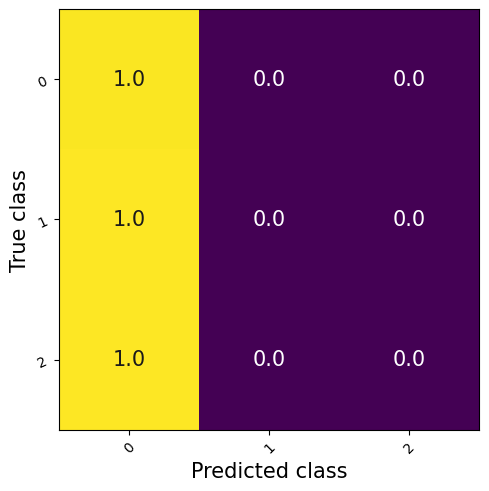

tensor([[1762,    1,    6],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9916, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 8.7500
MAE per_class: {2: np.float64(8.75)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


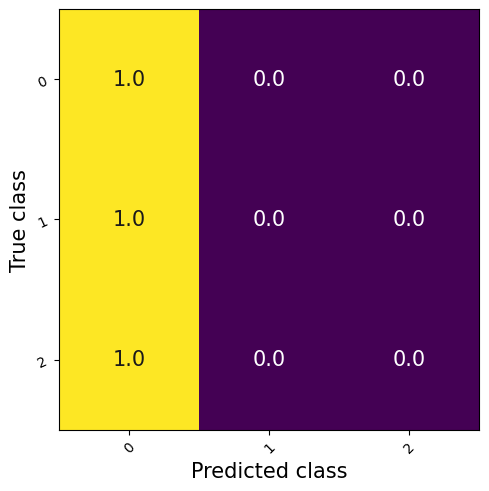

tensor([[1763,    4,    2],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9966, 0.0000, 0.0000])
MAE overall: 9.2500
MAE per_class: {1: np.float64(9.25)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_03_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


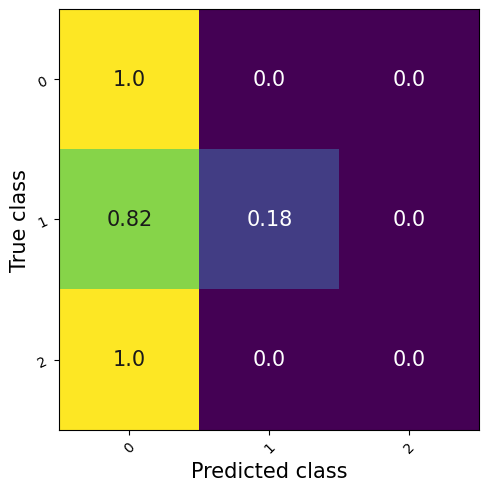

tensor([[1765,    3,    2],
        [   9,    2,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.4143 ✨
perclass_f1scores: tensor([0.9930, 0.2500, 0.0000])
perclass_precision: tensor([0.9888, 0.4000, 0.0000])
perclass_recall: tensor([0.9972, 0.1818, 0.0000])
MAE overall: 8.1667
MAE per_class: {1: np.float64(5.8), 2: np.float64(20.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_04_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


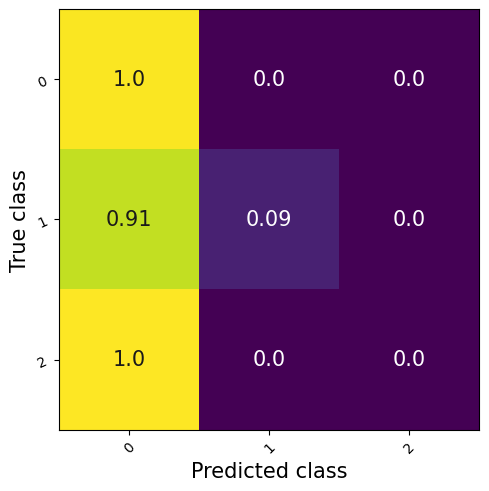

tensor([[1508,    4,    2],
        [  10,    1,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3720 ✨
perclass_f1scores: tensor([0.9911, 0.1250, 0.0000])
perclass_precision: tensor([0.9863, 0.2000, 0.0000])
perclass_recall: tensor([0.9960, 0.0909, 0.0000])
MAE overall: 8.6667
MAE per_class: {1: np.float64(7.8), 2: np.float64(13.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_05_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


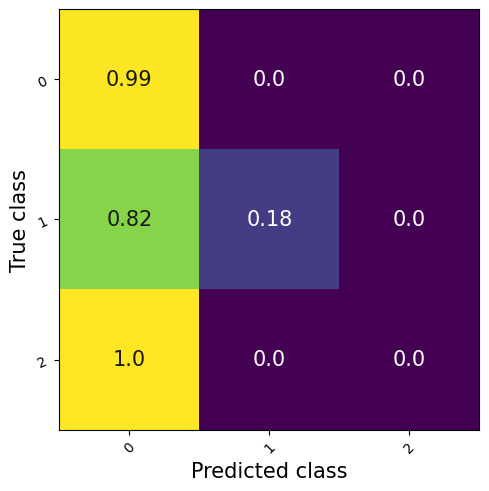

tensor([[1506,    4,    4],
        [   9,    2,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.4087 ✨
perclass_f1scores: tensor([0.9908, 0.2353, 0.0000])
perclass_precision: tensor([0.9869, 0.3333, 0.0000])
perclass_recall: tensor([0.9947, 0.1818, 0.0000])
MAE overall: 7.4286
MAE per_class: {1: np.float64(6.333333333333333), 2: np.float64(14.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


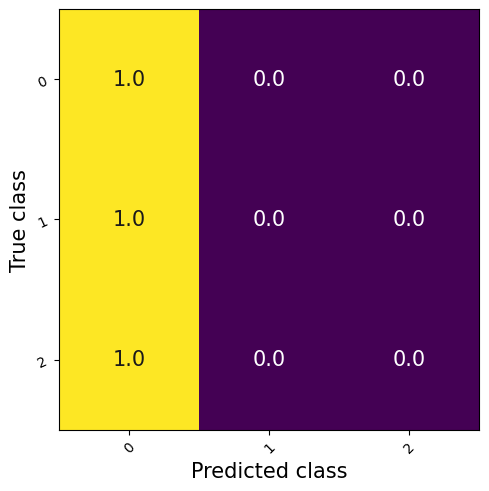

tensor([[1759,    2,    4],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9907, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9966, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {2: np.float64(18.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


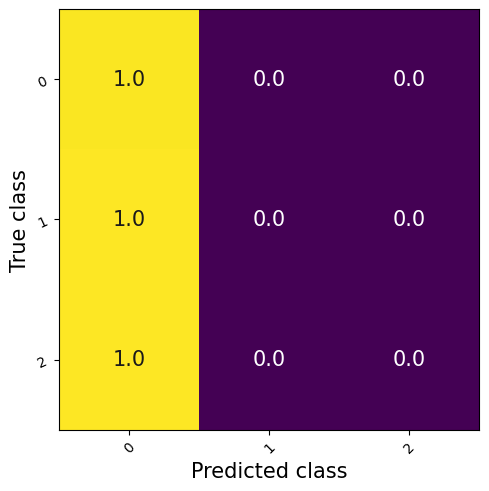

tensor([[1759,    1,    6],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9907, 0.0000, 0.0000])
perclass_precision: tensor([0.9854, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 17.3333
MAE per_class: {2: np.float64(17.333333333333332)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_03_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


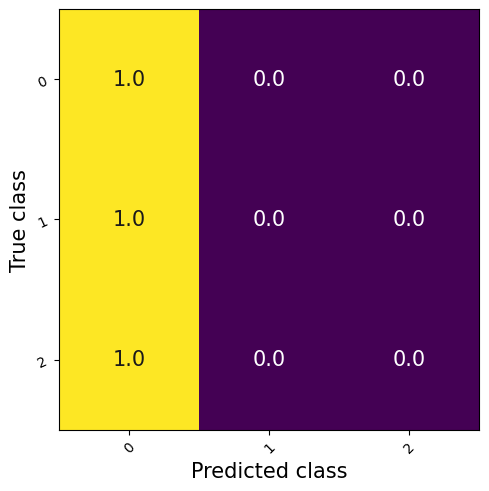

tensor([[1760,    1,    4],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9972, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {2: np.float64(18.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_04_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


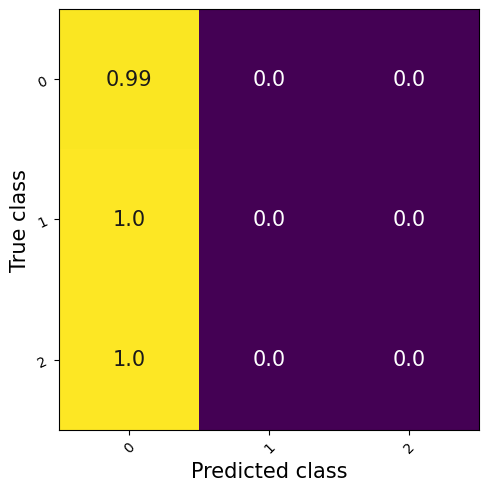

tensor([[1755,    3,    6],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9896, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9949, 0.0000, 0.0000])
MAE overall: 10.6667
MAE per_class: {1: np.float64(5.5), 2: np.float64(13.25)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_05_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


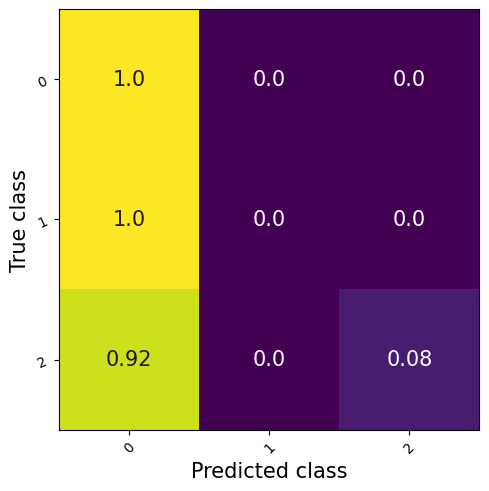

tensor([[1760,    1,    4],
        [  14,    0,    0],
        [  12,    0,    1]])
Macro F1-Score: 0.3675 ✨
perclass_f1scores: tensor([0.9913, 0.0000, 0.1111])
perclass_precision: tensor([0.9854, 0.0000, 0.2000])
perclass_recall: tensor([0.9972, 0.0000, 0.0769])
MAE overall: 10.0000
MAE per_class: {2: np.float64(10.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


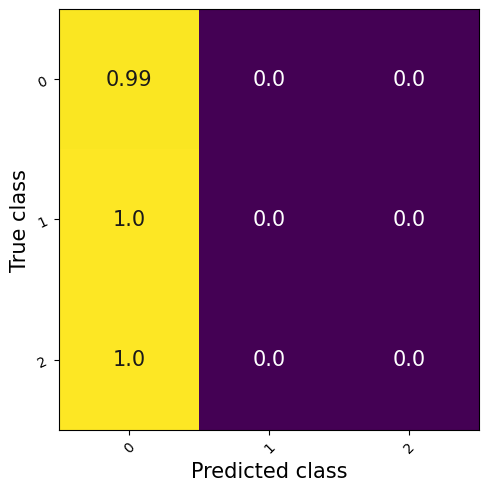

tensor([[2267,    8,    7],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9919, 0.0000, 0.0000])
perclass_precision: tensor([0.9904, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


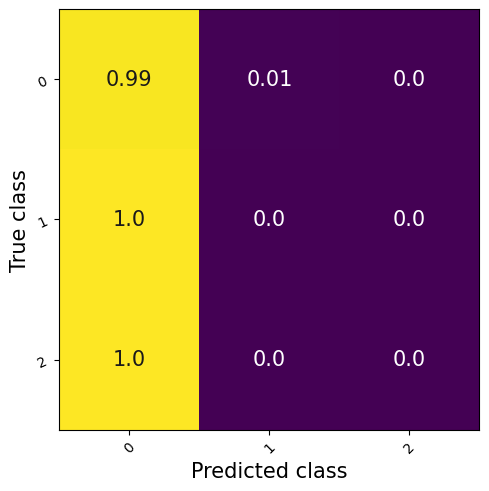

tensor([[2010,   12,    4],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9906, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9921, 0.0000, 0.0000])
MAE overall: 15.6667
MAE per_class: {1: np.float64(15.666666666666666)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


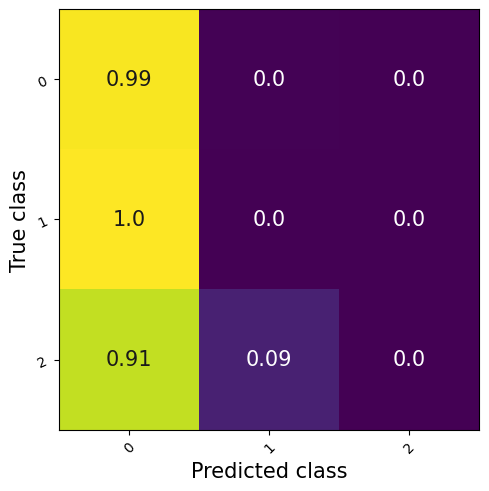

tensor([[2010,   10,    6],
        [  11,    0,    0],
        [  10,    1,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9909, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([0.9921, 0.0000, 0.0000])
MAE overall: 9.0000
MAE per_class: {2: np.float64(9.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


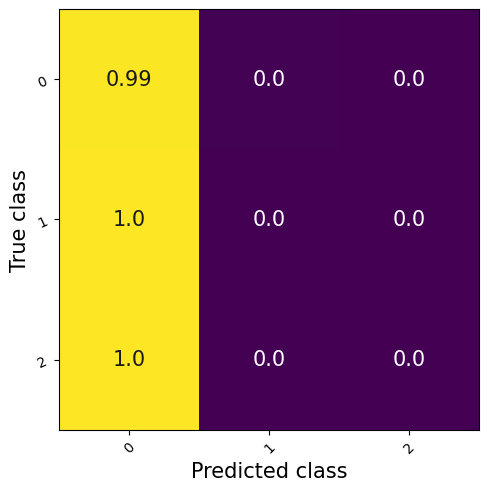

tensor([[2777,   12,    6],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9930, 0.0000, 0.0000])
perclass_precision: tensor([0.9925, 0.0000, 0.0000])
perclass_recall: tensor([0.9936, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


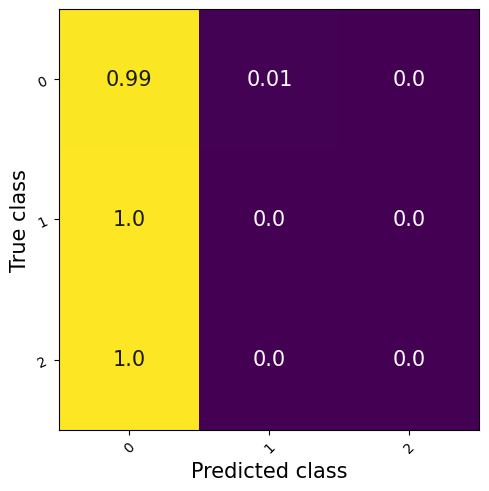

tensor([[2011,   11,    4],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9909, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9926, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


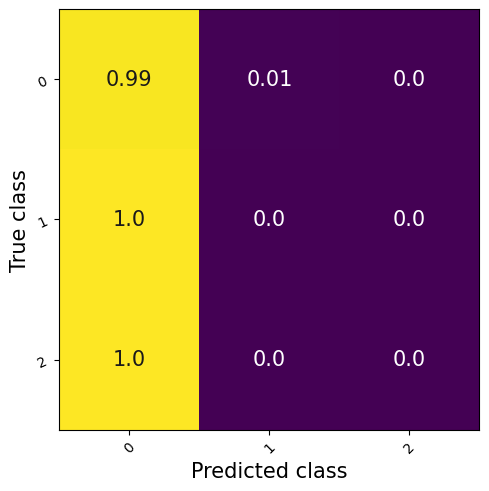

tensor([[2511,   13,    9],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3301 ✨
perclass_f1scores: tensor([0.9903, 0.0000, 0.0000])
perclass_precision: tensor([0.9894, 0.0000, 0.0000])
perclass_recall: tensor([0.9913, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


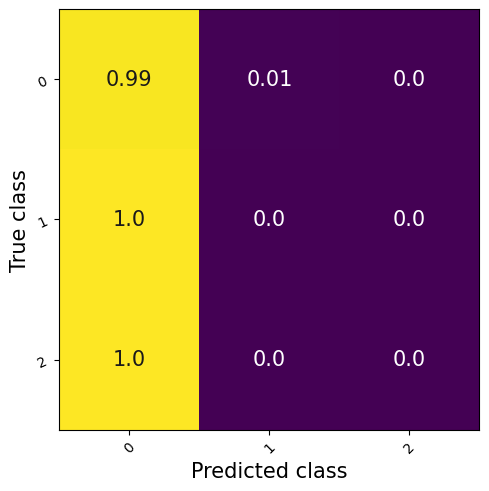

tensor([[2255,   13,    7],
        [  15,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9893, 0.0000, 0.0000])
perclass_precision: tensor([0.9873, 0.0000, 0.0000])
perclass_recall: tensor([0.9912, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


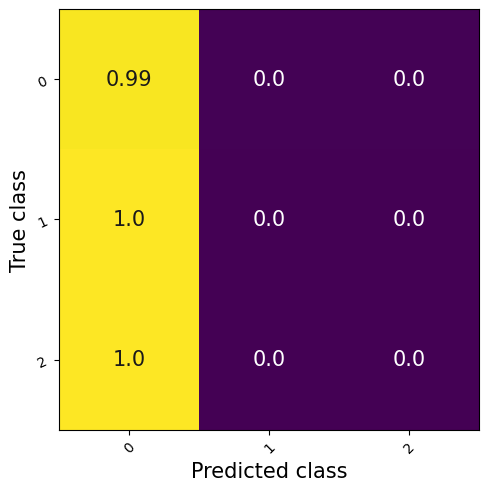

tensor([[2507,   12,   11],
        [  15,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9882, 0.0000, 0.0000])
perclass_recall: tensor([0.9909, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


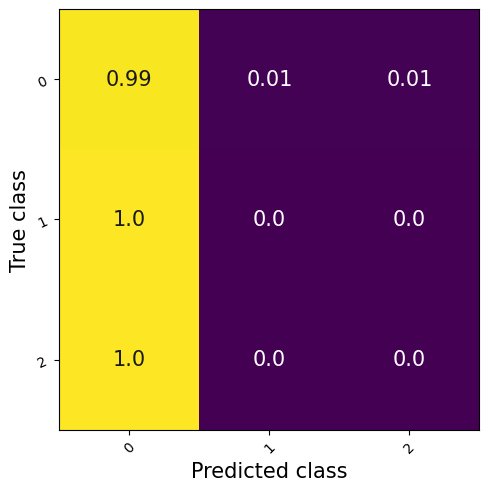

tensor([[2250,   14,   12],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([0.9886, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


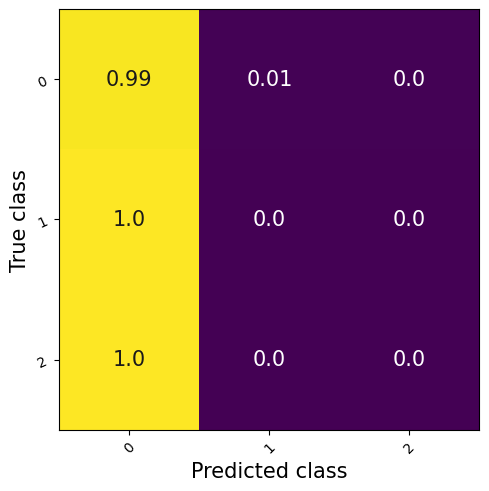

tensor([[2252,   13,   11],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9886, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([0.9895, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


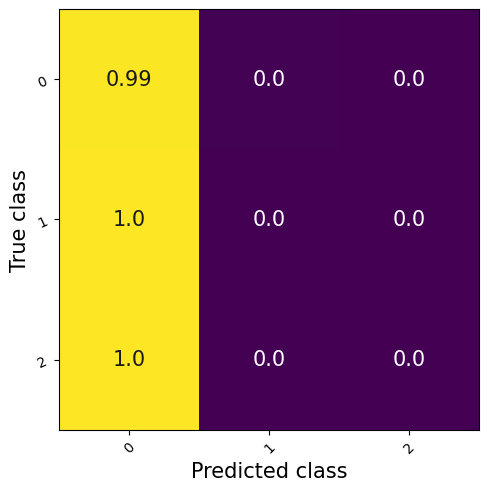

tensor([[2264,   10,    5],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9912, 0.0000, 0.0000])
perclass_precision: tensor([0.9891, 0.0000, 0.0000])
perclass_recall: tensor([0.9934, 0.0000, 0.0000])
MAE overall: 13.5000
MAE per_class: {1: np.float64(18.0), 2: np.float64(9.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


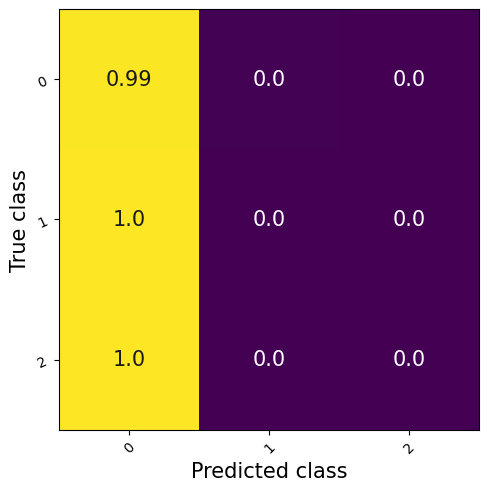

tensor([[2006,    8,    7],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9896, 0.0000, 0.0000])
perclass_precision: tensor([0.9867, 0.0000, 0.0000])
perclass_recall: tensor([0.9926, 0.0000, 0.0000])
MAE overall: 16.5000
MAE per_class: {1: np.float64(16.5)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


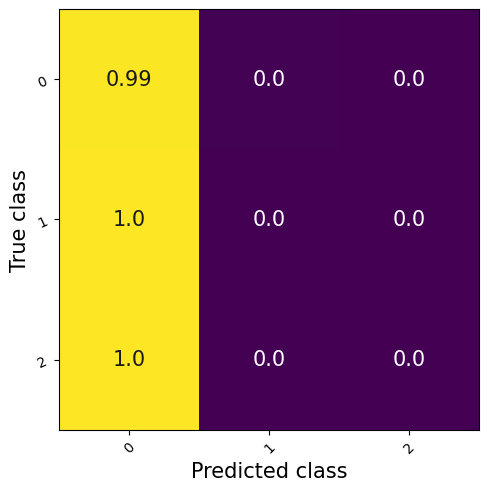

tensor([[1756,    7,    3],
        [  13,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9899, 0.0000, 0.0000])
perclass_precision: tensor([0.9854, 0.0000, 0.0000])
perclass_recall: tensor([0.9943, 0.0000, 0.0000])
MAE overall: 19.3333
MAE per_class: {1: np.float64(19.333333333333332)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


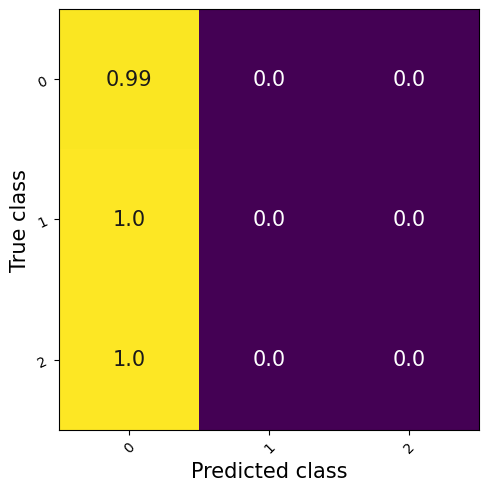

tensor([[1756,    6,    4],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9899, 0.0000, 0.0000])
perclass_precision: tensor([0.9854, 0.0000, 0.0000])
perclass_recall: tensor([0.9943, 0.0000, 0.0000])
MAE overall: 17.3333
MAE per_class: {1: np.float64(17.333333333333332)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


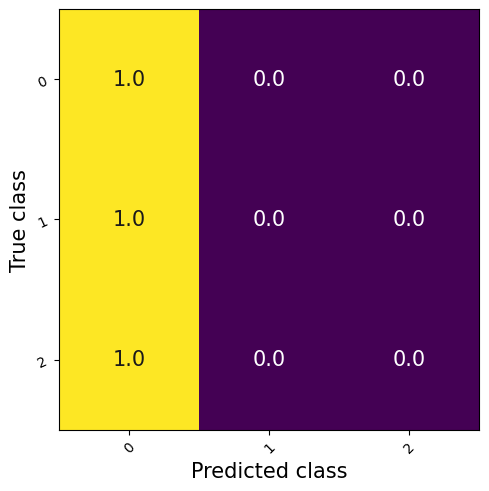

tensor([[2014,    3,    4],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3305 ✨
perclass_f1scores: tensor([0.9916, 0.0000, 0.0000])
perclass_precision: tensor([0.9868, 0.0000, 0.0000])
perclass_recall: tensor([0.9965, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


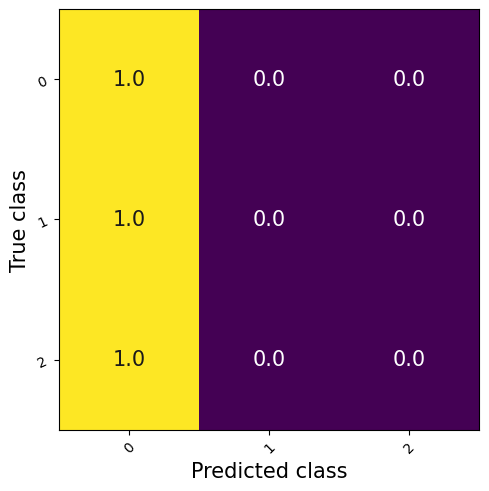

tensor([[1760,    1,    3],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9910, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9977, 0.0000, 0.0000])
MAE overall: 7.0000
MAE per_class: {1: np.float64(7.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


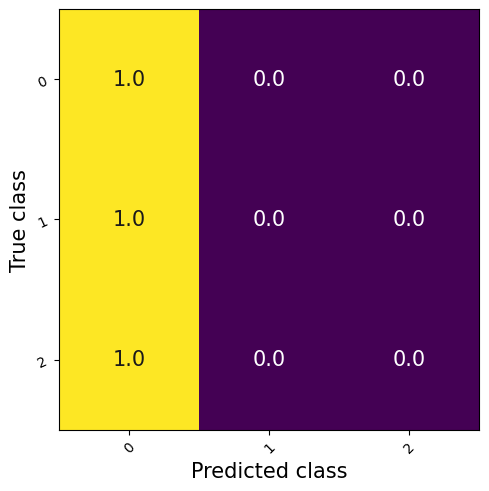

tensor([[2268,    5,    2],
        [  15,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9874, 0.0000, 0.0000])
perclass_recall: tensor([0.9969, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


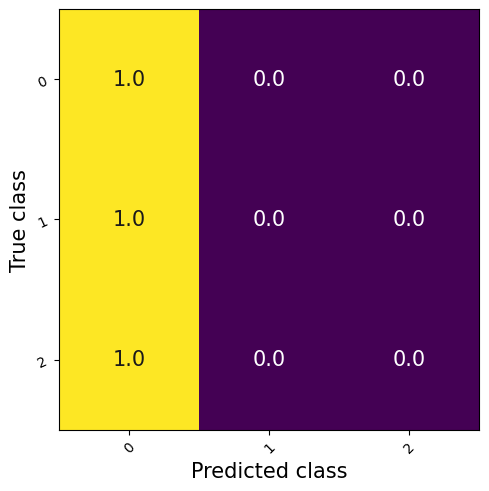

tensor([[2009,    3,    4],
        [  16,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3301 ✨
perclass_f1scores: tensor([0.9904, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9965, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


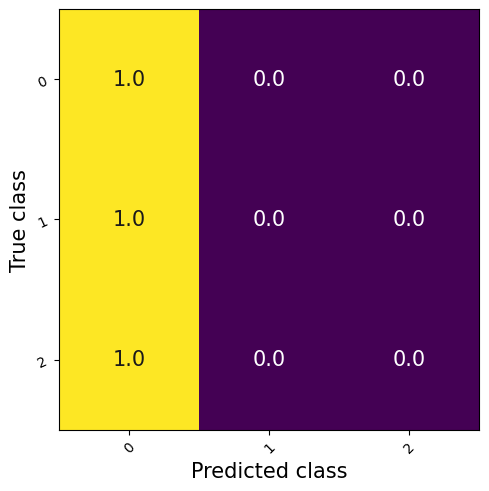

tensor([[2780,    6,    2],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9936, 0.0000, 0.0000])
perclass_precision: tensor([0.9900, 0.0000, 0.0000])
perclass_recall: tensor([0.9971, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


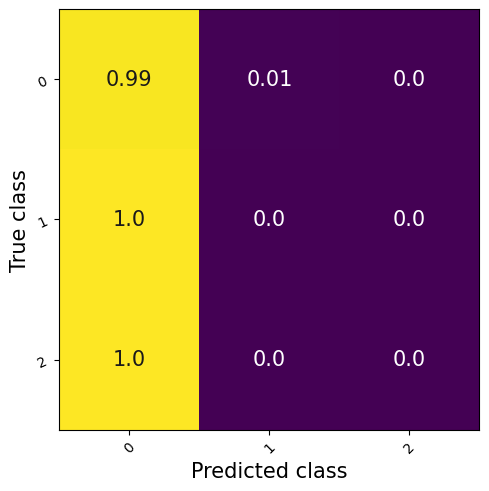

tensor([[1754,   11,    4],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9893, 0.0000, 0.0000])
perclass_precision: tensor([0.9871, 0.0000, 0.0000])
perclass_recall: tensor([0.9915, 0.0000, 0.0000])
MAE overall: 12.0000
MAE per_class: {1: np.float64(12.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


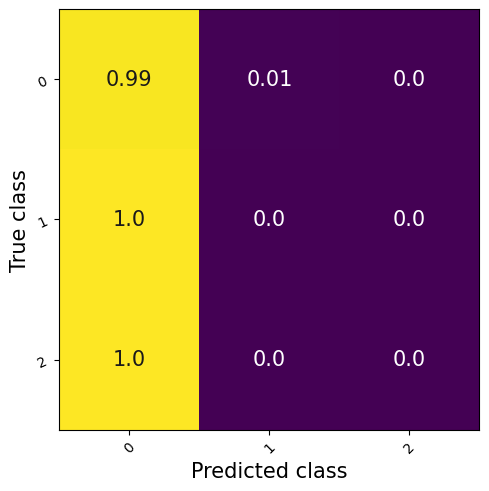

tensor([[1501,   10,    3],
        [  12,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9885, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9914, 0.0000, 0.0000])
MAE overall: 9.6000
MAE per_class: {1: np.float64(9.6)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


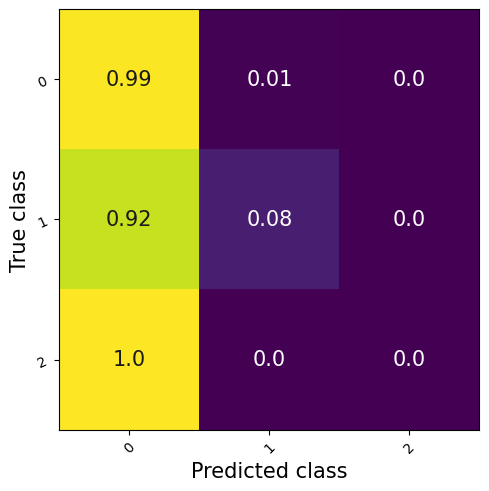

tensor([[1502,    8,    2],
        [  11,    1,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3615 ✨
perclass_f1scores: tensor([0.9891, 0.0952, 0.0000])
perclass_precision: tensor([0.9849, 0.1111, 0.0000])
perclass_recall: tensor([0.9934, 0.0833, 0.0000])
MAE overall: 9.2500
MAE per_class: {1: np.float64(9.25)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


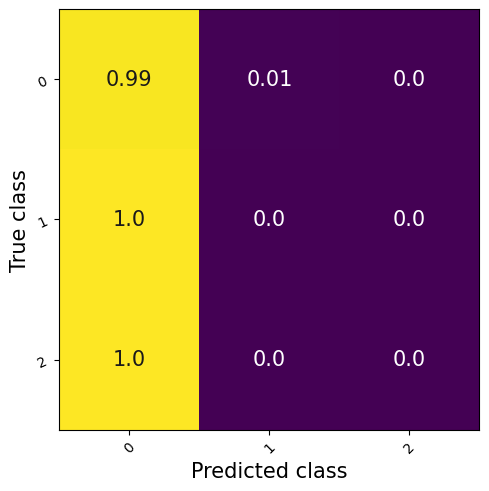

tensor([[1502,    8,    4],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3296 ✨
perclass_f1scores: tensor([0.9888, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9921, 0.0000, 0.0000])
MAE overall: 10.3333
MAE per_class: {1: np.float64(10.333333333333334)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


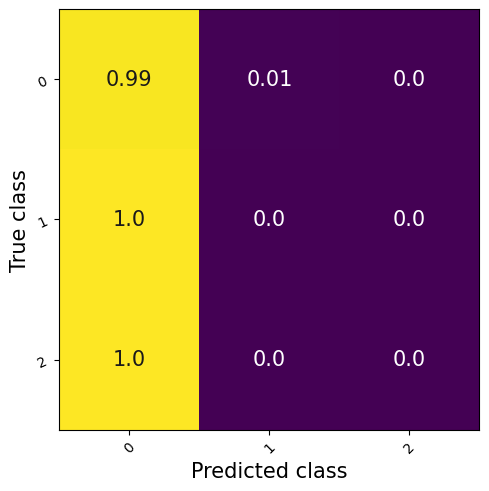

tensor([[1501,   11,    2],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9885, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9914, 0.0000, 0.0000])
MAE overall: 10.4000
MAE per_class: {1: np.float64(10.4)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


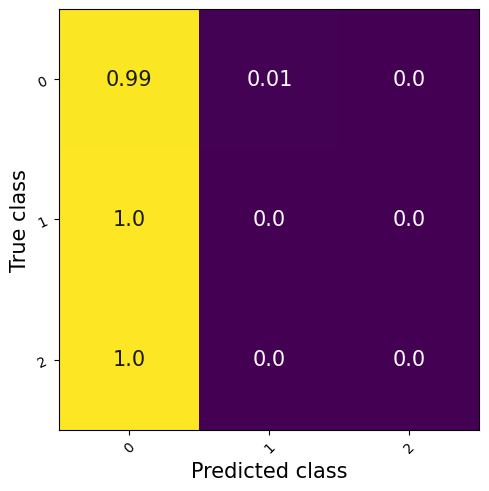

tensor([[1503,    9,    2],
        [  12,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3297 ✨
perclass_f1scores: tensor([0.9891, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: 12.7500
MAE per_class: {1: np.float64(12.75)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_07.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


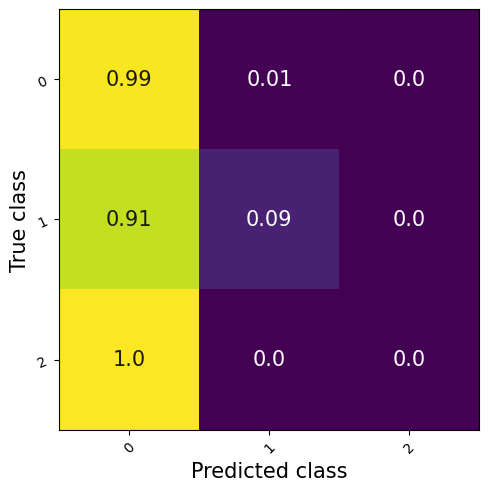

tensor([[1501,   10,    4],
        [  10,    1,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3599 ✨
perclass_f1scores: tensor([0.9888, 0.0909, 0.0000])
perclass_precision: tensor([0.9869, 0.0909, 0.0000])
perclass_recall: tensor([0.9908, 0.0909, 0.0000])
MAE overall: 10.1667
MAE per_class: {1: np.float64(10.166666666666666)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


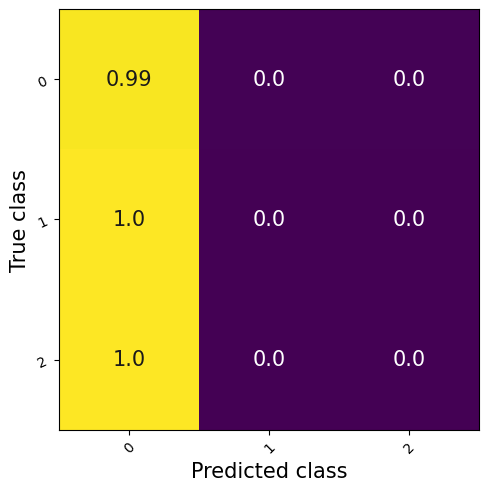

tensor([[1748,    8,    8],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9876, 0.0000, 0.0000])
perclass_precision: tensor([0.9842, 0.0000, 0.0000])
perclass_recall: tensor([0.9909, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


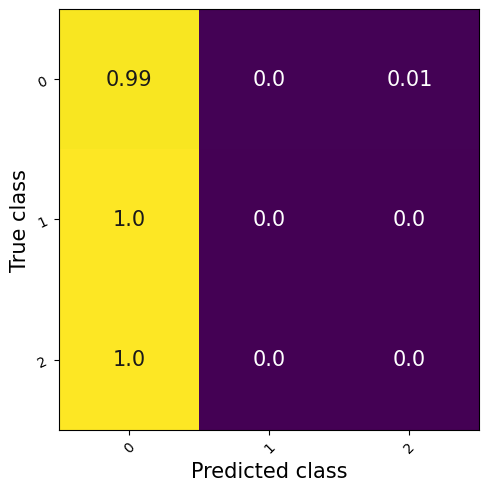

tensor([[1748,    7,    9],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9876, 0.0000, 0.0000])
perclass_precision: tensor([0.9842, 0.0000, 0.0000])
perclass_recall: tensor([0.9909, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


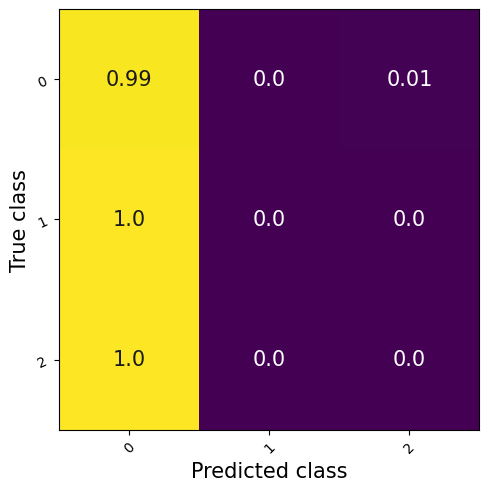

tensor([[1748,    6,   10],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9876, 0.0000, 0.0000])
perclass_precision: tensor([0.9842, 0.0000, 0.0000])
perclass_recall: tensor([0.9909, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


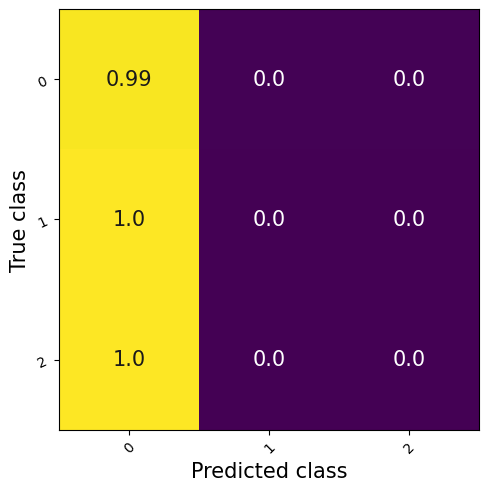

tensor([[2002,    9,    9],
        [  15,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9886, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9911, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


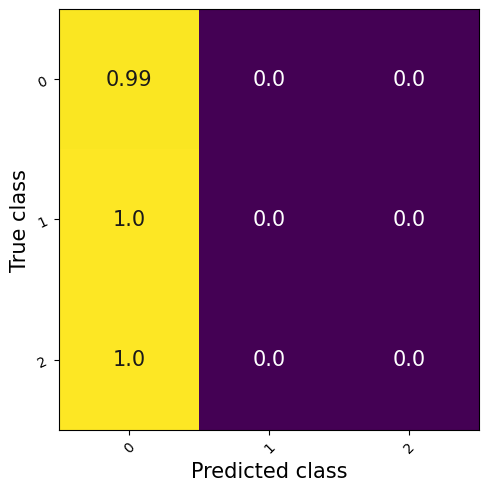

tensor([[2520,    5,    8],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9894, 0.0000, 0.0000])
perclass_recall: tensor([0.9949, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


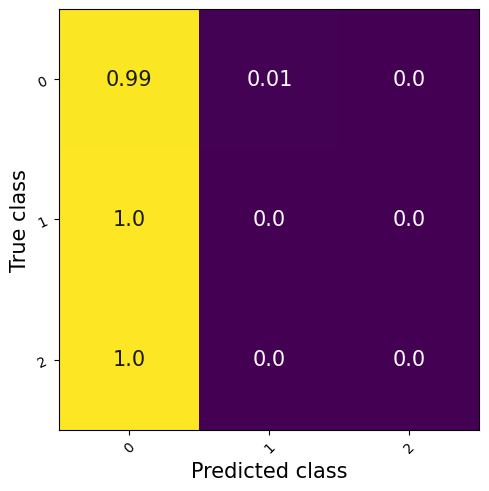

tensor([[1504,    8,    3],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9895, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: 14.5714
MAE per_class: {1: np.float64(14.571428571428571)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


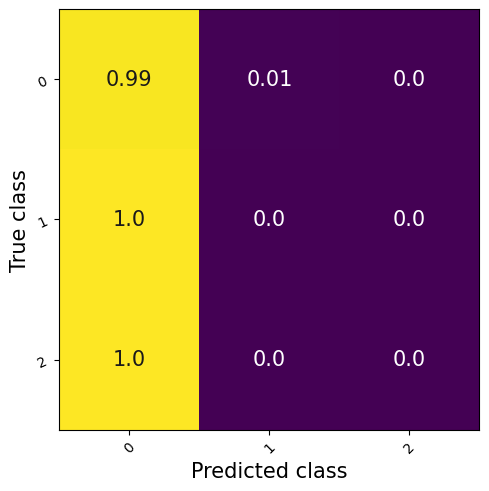

tensor([[993,   7,   3],
        [ 11,   0,   0],
        [ 10,   0,   0]])
Macro F1-Score: 0.3282 ✨
perclass_f1scores: tensor([0.9846, 0.0000, 0.0000])
perclass_precision: tensor([0.9793, 0.0000, 0.0000])
perclass_recall: tensor([0.9900, 0.0000, 0.0000])
MAE overall: 14.2000
MAE per_class: {1: np.float64(14.2)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


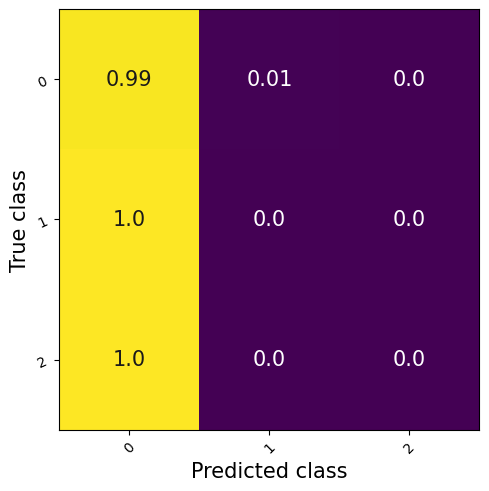

tensor([[992,   7,   3],
        [ 11,   0,   0],
        [ 11,   0,   0]])
Macro F1-Score: 0.3280 ✨
perclass_f1scores: tensor([0.9841, 0.0000, 0.0000])
perclass_precision: tensor([0.9783, 0.0000, 0.0000])
perclass_recall: tensor([0.9900, 0.0000, 0.0000])
MAE overall: 11.8000
MAE per_class: {1: np.float64(11.8)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


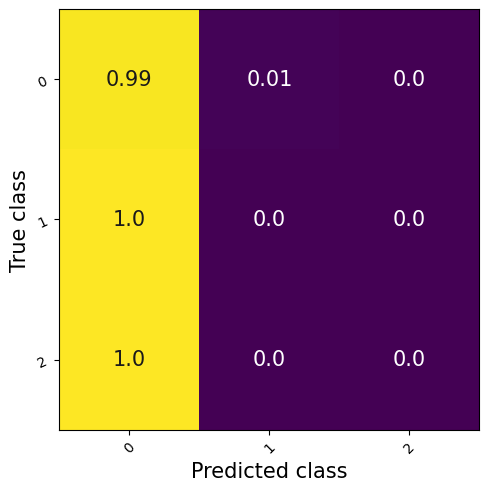

tensor([[1245,   11,    1],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3287 ✨
perclass_f1scores: tensor([0.9861, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9905, 0.0000, 0.0000])
MAE overall: 13.2500
MAE per_class: {1: np.float64(13.25)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


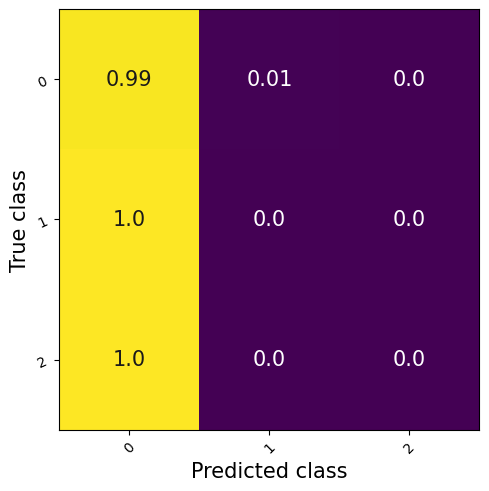

tensor([[1246,    9,    2],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3288 ✨
perclass_f1scores: tensor([0.9865, 0.0000, 0.0000])
perclass_precision: tensor([0.9819, 0.0000, 0.0000])
perclass_recall: tensor([0.9912, 0.0000, 0.0000])
MAE overall: 14.1429
MAE per_class: {1: np.float64(14.142857142857142)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


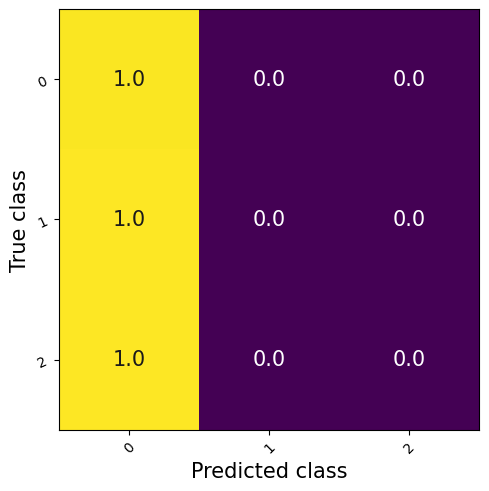

tensor([[1507,    2,    5],
        [  10,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9905, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9954, 0.0000, 0.0000])
MAE overall: 16.3333
MAE per_class: {1: np.float64(14.5), 2: np.float64(20.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


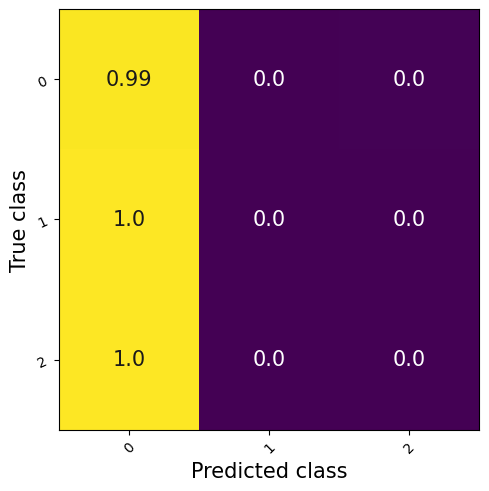

tensor([[1246,    4,    5],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3288 ✨
perclass_f1scores: tensor([0.9865, 0.0000, 0.0000])
perclass_precision: tensor([0.9803, 0.0000, 0.0000])
perclass_recall: tensor([0.9928, 0.0000, 0.0000])
MAE overall: 16.5000
MAE per_class: {1: np.float64(16.5)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


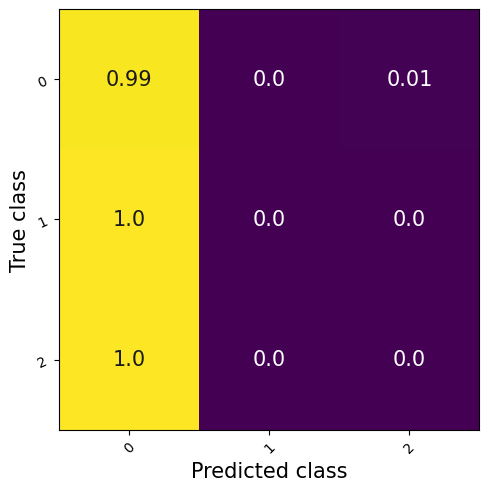

tensor([[992,   3,   6],
        [ 12,   0,   0],
        [ 11,   0,   0]])
Macro F1-Score: 0.3280 ✨
perclass_f1scores: tensor([0.9841, 0.0000, 0.0000])
perclass_precision: tensor([0.9773, 0.0000, 0.0000])
perclass_recall: tensor([0.9910, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


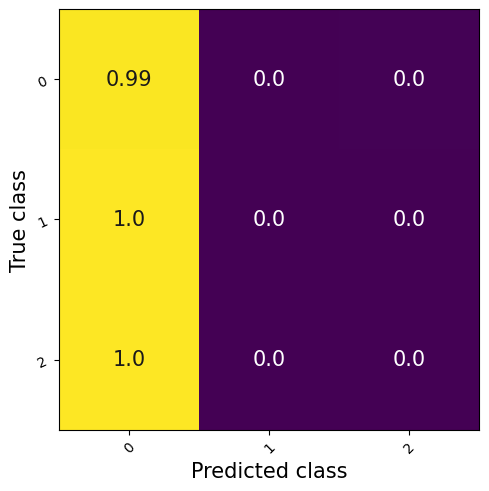

tensor([[1503,    1,    7],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3297 ✨
perclass_f1scores: tensor([0.9891, 0.0000, 0.0000])
perclass_precision: tensor([0.9836, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(19.0), 2: np.float64(14.5)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


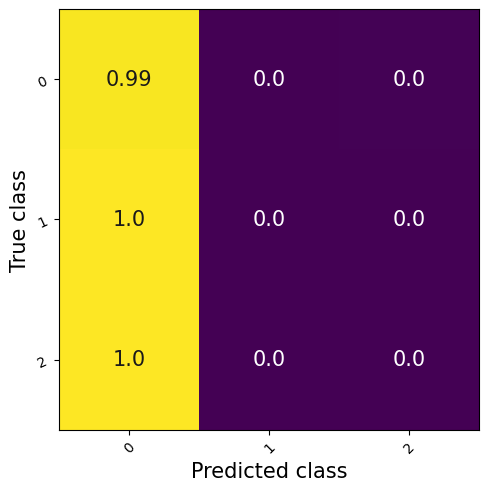

tensor([[1245,    4,    6],
        [  13,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3287 ✨
perclass_f1scores: tensor([0.9861, 0.0000, 0.0000])
perclass_precision: tensor([0.9803, 0.0000, 0.0000])
perclass_recall: tensor([0.9920, 0.0000, 0.0000])
MAE overall: 17.6000
MAE per_class: {1: np.float64(17.25), 2: np.float64(19.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


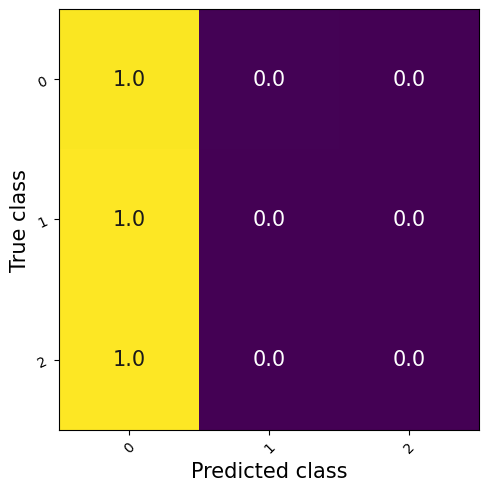

tensor([[2018,    9,    0],
        [  10,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3309 ✨
perclass_f1scores: tensor([0.9926, 0.0000, 0.0000])
perclass_precision: tensor([0.9897, 0.0000, 0.0000])
perclass_recall: tensor([0.9956, 0.0000, 0.0000])
MAE overall: 13.2500
MAE per_class: {1: np.float64(13.25)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


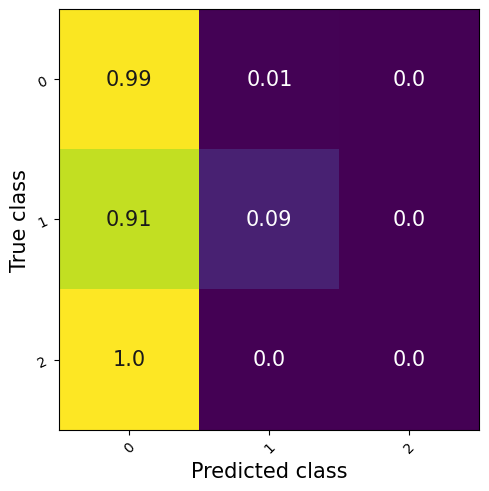

tensor([[1248,    9,    0],
        [  10,    1,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3610 ✨
perclass_f1scores: tensor([0.9877, 0.0952, 0.0000])
perclass_precision: tensor([0.9827, 0.1000, 0.0000])
perclass_recall: tensor([0.9928, 0.0909, 0.0000])
MAE overall: 12.3750
MAE per_class: {1: np.float64(12.375)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


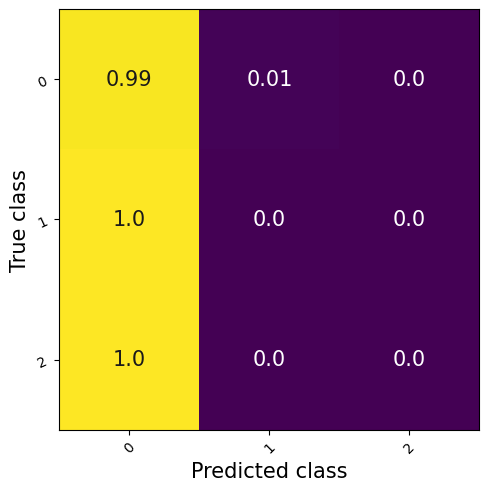

tensor([[1250,   10,    0],
        [  11,    0,    0],
        [   9,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9921, 0.0000, 0.0000])
MAE overall: 15.8750
MAE per_class: {1: np.float64(15.875)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


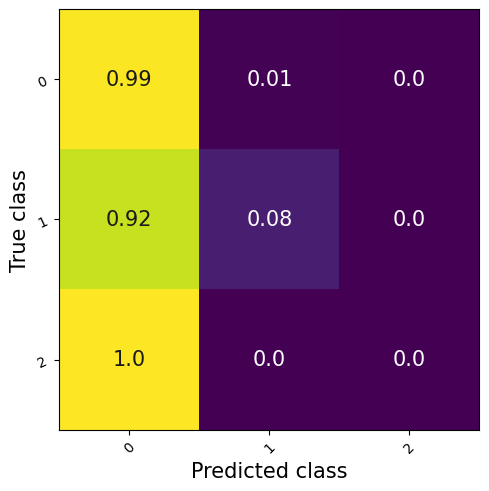

tensor([[1758,   10,    1],
        [  11,    1,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3592 ✨
perclass_f1scores: tensor([0.9907, 0.0870, 0.0000])
perclass_precision: tensor([0.9876, 0.0909, 0.0000])
perclass_recall: tensor([0.9938, 0.0833, 0.0000])
MAE overall: 11.2222
MAE per_class: {1: np.float64(11.222222222222221)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


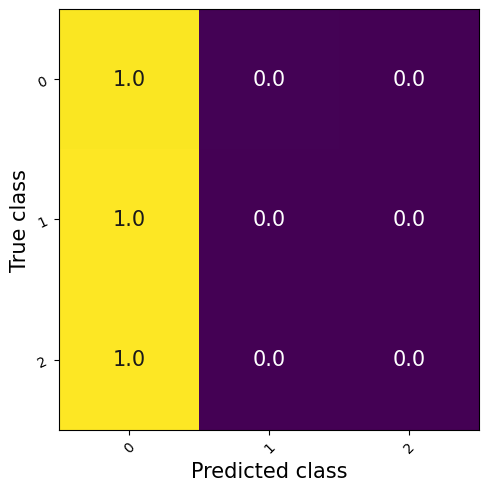

tensor([[2016,    8,    2],
        [  10,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9951, 0.0000, 0.0000])
MAE overall: 15.0000
MAE per_class: {1: np.float64(15.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


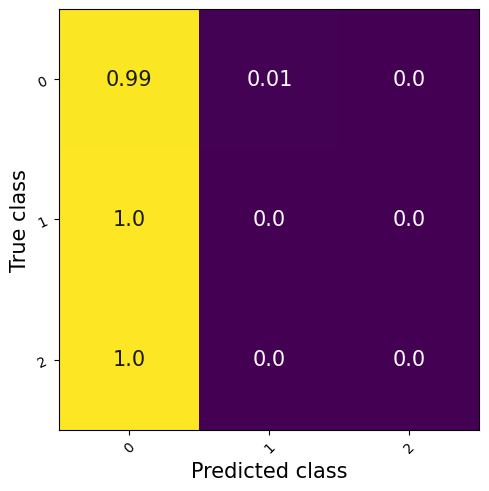

tensor([[1501,    8,    3],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9885, 0.0000, 0.0000])
perclass_precision: tensor([0.9843, 0.0000, 0.0000])
perclass_recall: tensor([0.9927, 0.0000, 0.0000])
MAE overall: 17.0000
MAE per_class: {1: np.float64(17.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


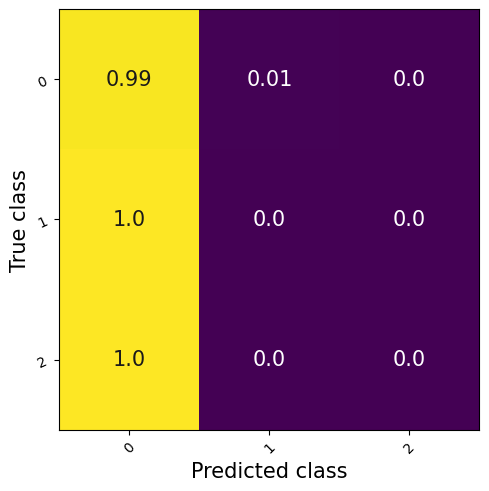

tensor([[1496,   11,    3],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9868, 0.0000, 0.0000])
perclass_precision: tensor([0.9829, 0.0000, 0.0000])
perclass_recall: tensor([0.9907, 0.0000, 0.0000])
MAE overall: 15.5000
MAE per_class: {1: np.float64(15.5)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


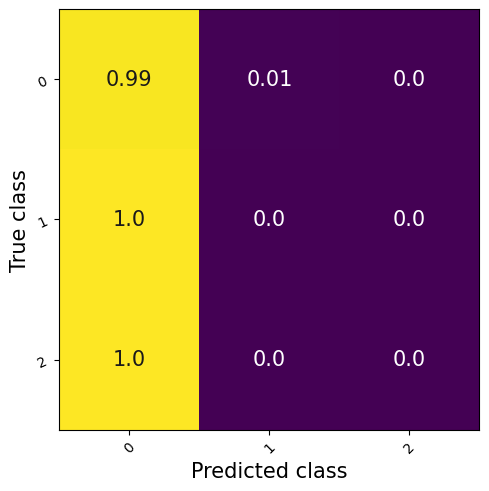

tensor([[1496,    9,    5],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9868, 0.0000, 0.0000])
perclass_precision: tensor([0.9829, 0.0000, 0.0000])
perclass_recall: tensor([0.9907, 0.0000, 0.0000])
MAE overall: 17.4286
MAE per_class: {1: np.float64(17.428571428571427)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


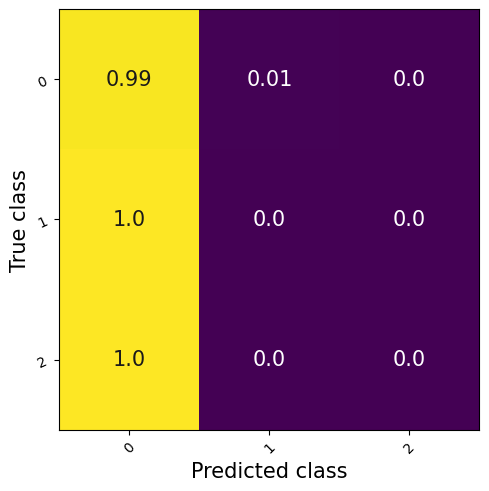

tensor([[2004,   13,    6],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3297 ✨
perclass_f1scores: tensor([0.9891, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([0.9906, 0.0000, 0.0000])
MAE overall: 15.0000
MAE per_class: {1: np.float64(15.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


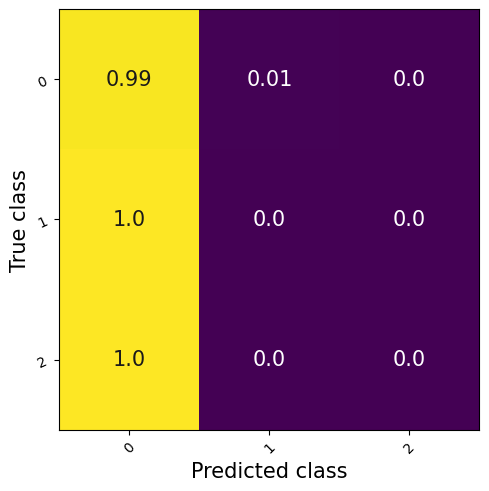

tensor([[1499,   10,    5],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3293 ✨
perclass_f1scores: tensor([0.9878, 0.0000, 0.0000])
perclass_precision: tensor([0.9855, 0.0000, 0.0000])
perclass_recall: tensor([0.9901, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


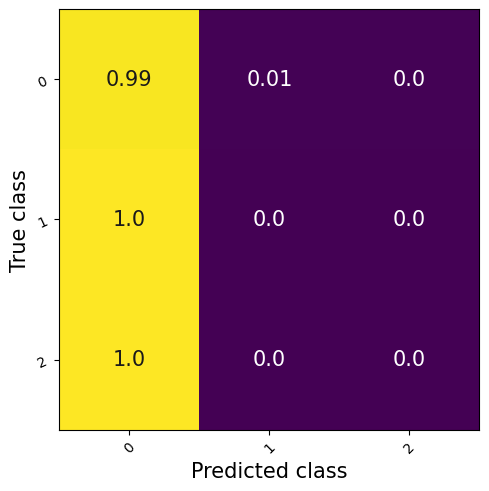

tensor([[1749,   13,    7],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3293 ✨
perclass_f1scores: tensor([0.9879, 0.0000, 0.0000])
perclass_precision: tensor([0.9870, 0.0000, 0.0000])
perclass_recall: tensor([0.9887, 0.0000, 0.0000])
MAE overall: 13.3333
MAE per_class: {1: np.float64(13.333333333333334)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


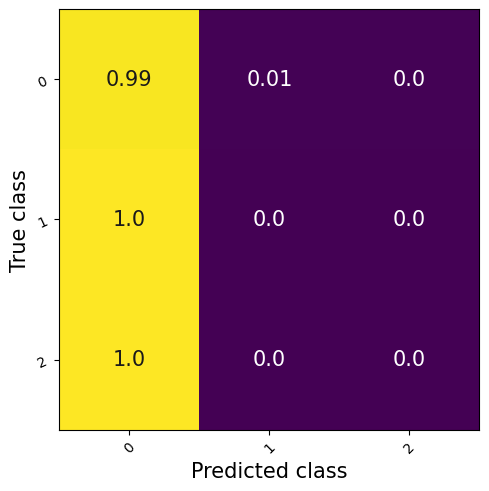

tensor([[1751,   11,    7],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3295 ✨
perclass_f1scores: tensor([0.9884, 0.0000, 0.0000])
perclass_precision: tensor([0.9870, 0.0000, 0.0000])
perclass_recall: tensor([0.9898, 0.0000, 0.0000])
MAE overall: 18.0000
MAE per_class: {1: np.float64(18.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


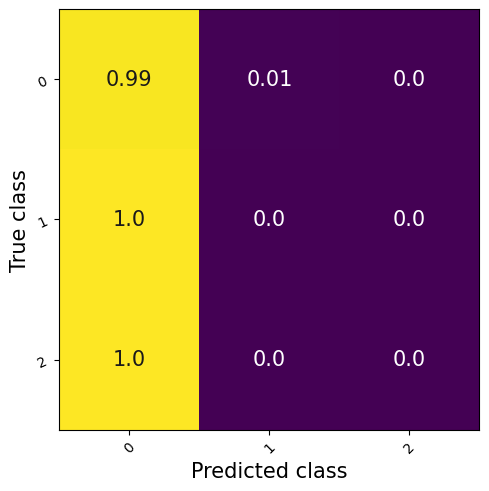

tensor([[2008,   11,    7],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9892, 0.0000, 0.0000])
perclass_recall: tensor([0.9911, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


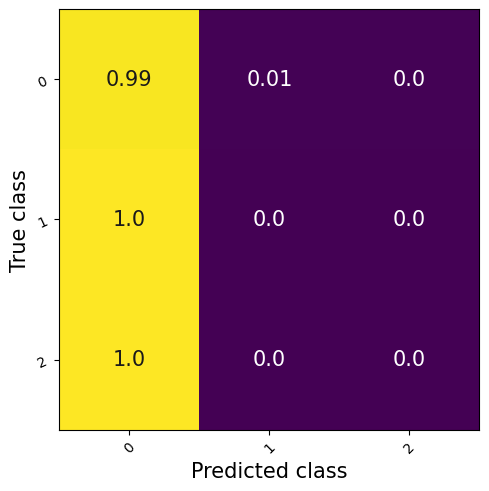

tensor([[2506,   14,   12],
        [  13,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9893, 0.0000, 0.0000])
perclass_precision: tensor([0.9890, 0.0000, 0.0000])
perclass_recall: tensor([0.9897, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


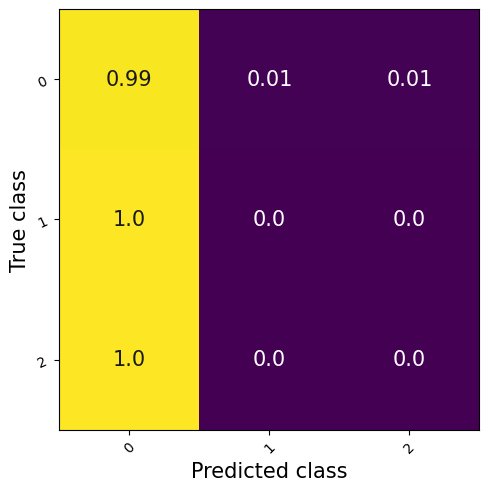

tensor([[1998,   11,   11],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9876, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9891, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


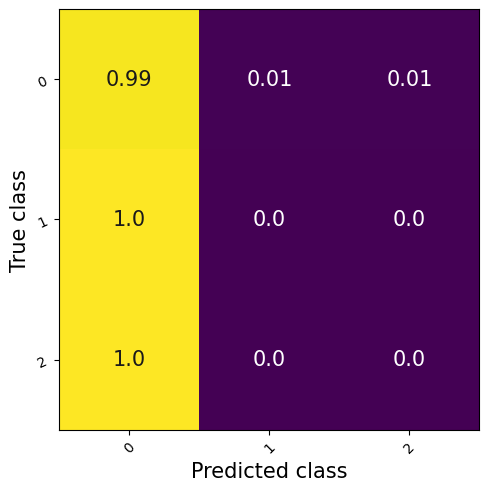

tensor([[1741,   11,   13],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3285 ✨
perclass_f1scores: tensor([0.9856, 0.0000, 0.0000])
perclass_precision: tensor([0.9847, 0.0000, 0.0000])
perclass_recall: tensor([0.9864, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


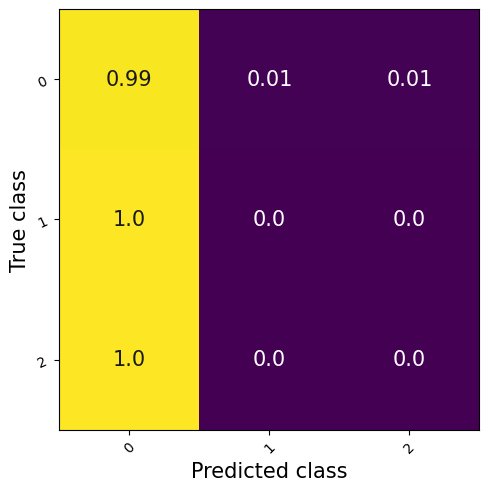

tensor([[1745,   11,    9],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9867, 0.0000, 0.0000])
perclass_precision: tensor([0.9848, 0.0000, 0.0000])
perclass_recall: tensor([0.9887, 0.0000, 0.0000])
MAE overall: 11.0000
MAE per_class: {1: np.float64(11.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


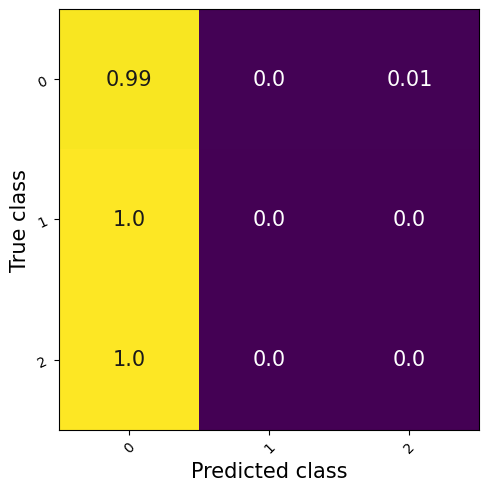

tensor([[2253,   11,   13],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3296 ✨
perclass_f1scores: tensor([0.9888, 0.0000, 0.0000])
perclass_precision: tensor([0.9882, 0.0000, 0.0000])
perclass_recall: tensor([0.9895, 0.0000, 0.0000])
MAE overall: 19.0000
MAE per_class: {1: np.float64(19.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


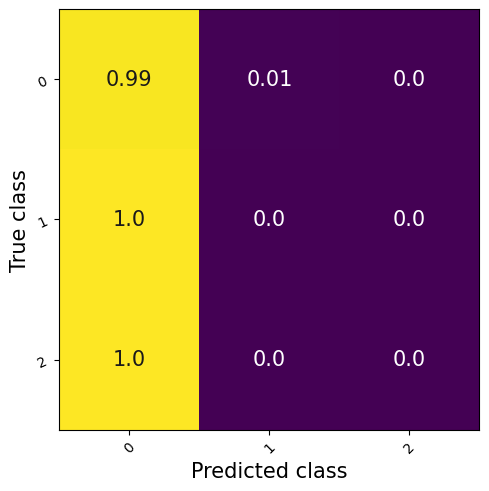

tensor([[1497,   11,    5],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3290 ✨
perclass_f1scores: tensor([0.9871, 0.0000, 0.0000])
perclass_precision: tensor([0.9849, 0.0000, 0.0000])
perclass_recall: tensor([0.9894, 0.0000, 0.0000])
MAE overall: 15.8000
MAE per_class: {1: np.float64(15.8)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


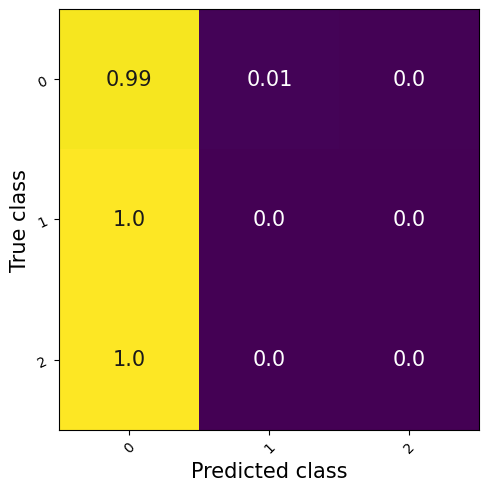

tensor([[1239,   12,    6],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3279 ✨
perclass_f1scores: tensor([0.9837, 0.0000, 0.0000])
perclass_precision: tensor([0.9818, 0.0000, 0.0000])
perclass_recall: tensor([0.9857, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02npy.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


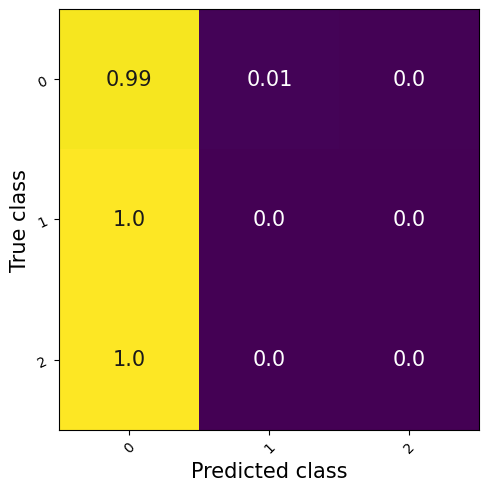

tensor([[1239,   12,    6],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3279 ✨
perclass_f1scores: tensor([0.9837, 0.0000, 0.0000])
perclass_precision: tensor([0.9818, 0.0000, 0.0000])
perclass_recall: tensor([0.9857, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


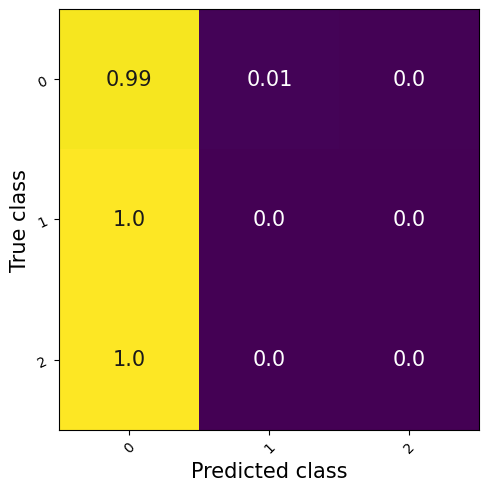

tensor([[1240,   12,    6],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3280 ✨
perclass_f1scores: tensor([0.9841, 0.0000, 0.0000])
perclass_precision: tensor([0.9826, 0.0000, 0.0000])
perclass_recall: tensor([0.9857, 0.0000, 0.0000])
MAE overall: 14.6667
MAE per_class: {1: np.float64(14.666666666666666)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


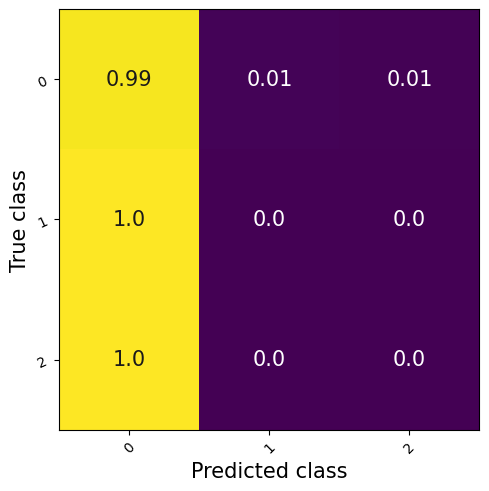

tensor([[1239,   11,    7],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3279 ✨
perclass_f1scores: tensor([0.9837, 0.0000, 0.0000])
perclass_precision: tensor([0.9818, 0.0000, 0.0000])
perclass_recall: tensor([0.9857, 0.0000, 0.0000])
MAE overall: 14.7500
MAE per_class: {1: np.float64(14.75)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


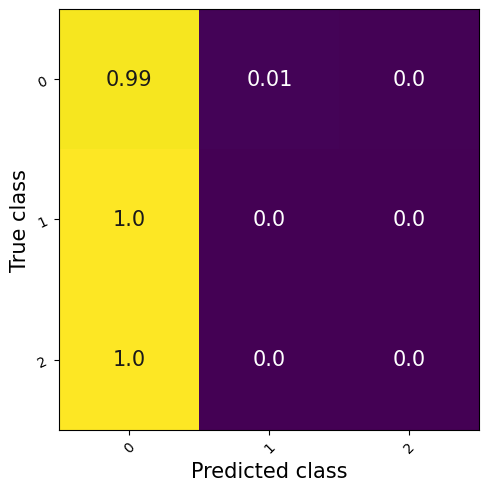

tensor([[1241,   10,    6],
        [  12,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3282 ✨
perclass_f1scores: tensor([0.9845, 0.0000, 0.0000])
perclass_precision: tensor([0.9818, 0.0000, 0.0000])
perclass_recall: tensor([0.9873, 0.0000, 0.0000])
MAE overall: 15.3333
MAE per_class: {1: np.float64(15.333333333333334)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


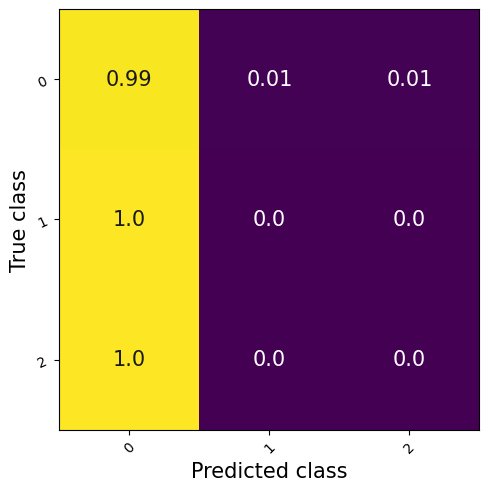

tensor([[1745,   10,   10],
        [  13,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9867, 0.0000, 0.0000])
perclass_precision: tensor([0.9848, 0.0000, 0.0000])
perclass_recall: tensor([0.9887, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


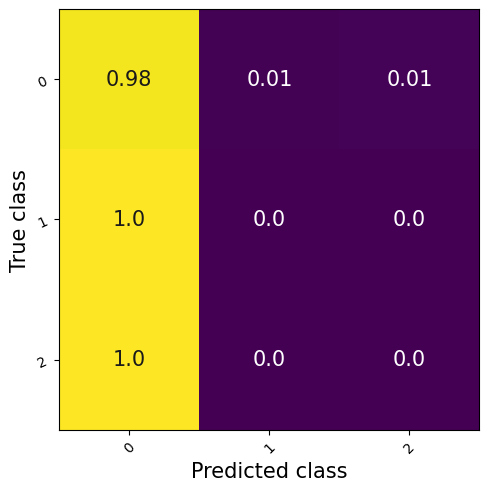

tensor([[1236,    8,   12],
        [  13,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3275 ✨
perclass_f1scores: tensor([0.9825, 0.0000, 0.0000])
perclass_precision: tensor([0.9810, 0.0000, 0.0000])
perclass_recall: tensor([0.9841, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


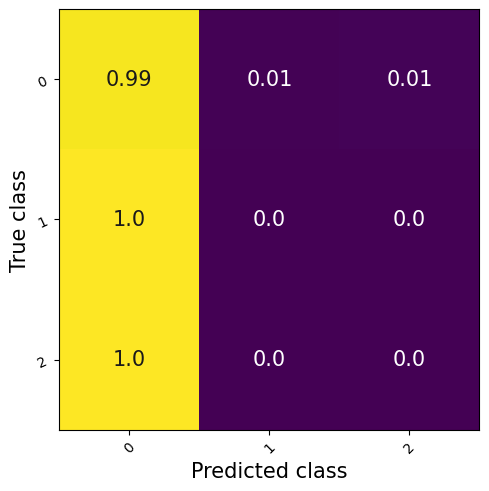

tensor([[1487,    9,   12],
        [  14,    0,    0],
        [  14,    0,    0]])
Macro F1-Score: 0.3279 ✨
perclass_f1scores: tensor([0.9838, 0.0000, 0.0000])
perclass_precision: tensor([0.9815, 0.0000, 0.0000])
perclass_recall: tensor([0.9861, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


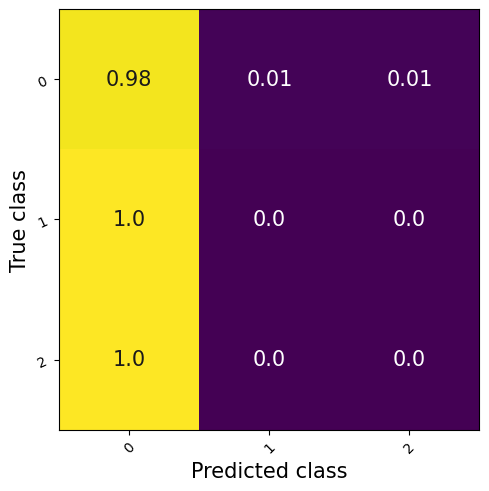

tensor([[1234,   11,   11],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3272 ✨
perclass_f1scores: tensor([0.9817, 0.0000, 0.0000])
perclass_precision: tensor([0.9809, 0.0000, 0.0000])
perclass_recall: tensor([0.9825, 0.0000, 0.0000])
MAE overall: 8.0000
MAE per_class: {1: np.float64(8.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


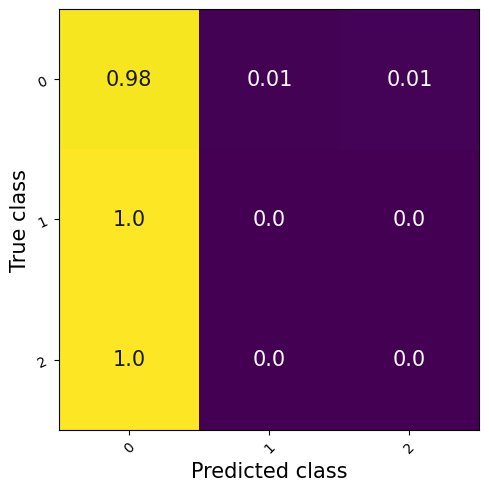

tensor([[1237,    8,   11],
        [  13,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3276 ✨
perclass_f1scores: tensor([0.9829, 0.0000, 0.0000])
perclass_precision: tensor([0.9810, 0.0000, 0.0000])
perclass_recall: tensor([0.9849, 0.0000, 0.0000])
MAE overall: 10.0000
MAE per_class: {1: np.float64(10.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


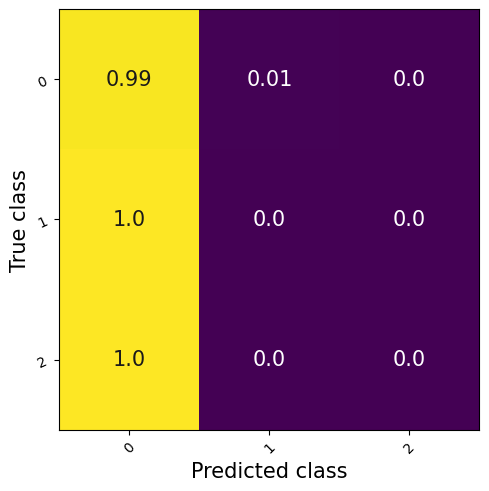

tensor([[1757,    9,    6],
        [   9,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9887, 0.0000, 0.0000])
perclass_recall: tensor([0.9915, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


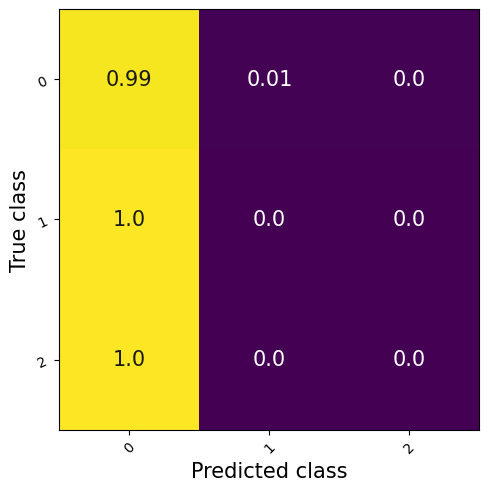

tensor([[1495,   11,    7],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3288 ✨
perclass_f1scores: tensor([0.9865, 0.0000, 0.0000])
perclass_precision: tensor([0.9848, 0.0000, 0.0000])
perclass_recall: tensor([0.9881, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


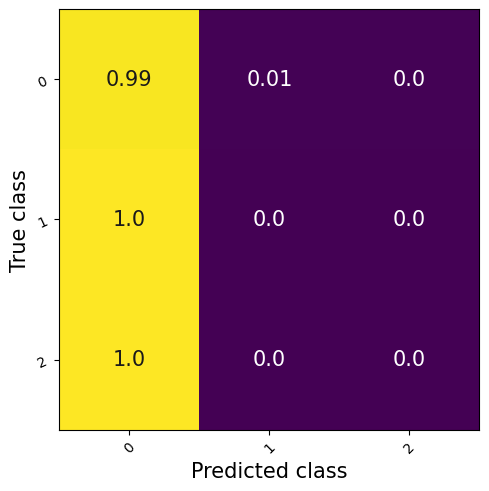

tensor([[1498,   11,    6],
        [  11,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9875, 0.0000, 0.0000])
perclass_precision: tensor([0.9862, 0.0000, 0.0000])
perclass_recall: tensor([0.9888, 0.0000, 0.0000])
MAE overall: 11.0000
MAE per_class: {1: np.float64(11.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


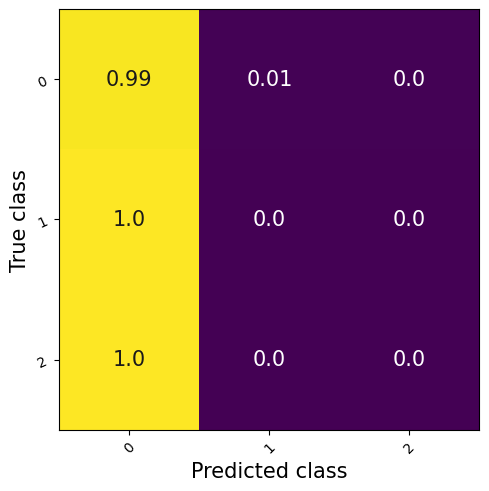

tensor([[1500,   10,    6],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9881, 0.0000, 0.0000])
perclass_precision: tensor([0.9868, 0.0000, 0.0000])
perclass_recall: tensor([0.9894, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


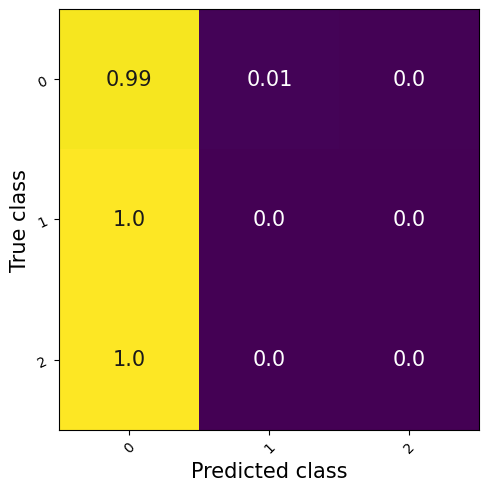

tensor([[1498,   12,    6],
        [  10,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3292 ✨
perclass_f1scores: tensor([0.9875, 0.0000, 0.0000])
perclass_precision: tensor([0.9868, 0.0000, 0.0000])
perclass_recall: tensor([0.9881, 0.0000, 0.0000])
MAE overall: 16.0000
MAE per_class: {1: np.float64(16.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


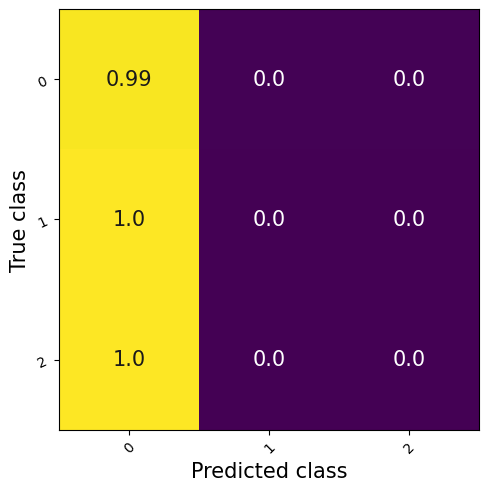

tensor([[2762,   12,   13],
        [  14,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3301 ✨
perclass_f1scores: tensor([0.9903, 0.0000, 0.0000])
perclass_precision: tensor([0.9896, 0.0000, 0.0000])
perclass_recall: tensor([0.9910, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


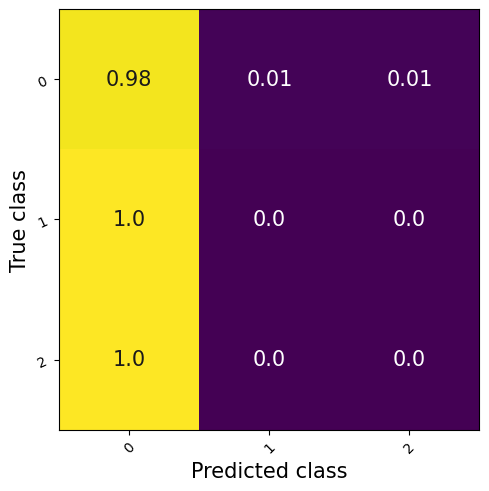

tensor([[1484,   12,   13],
        [  14,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3276 ✨
perclass_f1scores: tensor([0.9828, 0.0000, 0.0000])
perclass_precision: tensor([0.9821, 0.0000, 0.0000])
perclass_recall: tensor([0.9834, 0.0000, 0.0000])
MAE overall: 17.0000
MAE per_class: {1: np.float64(17.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


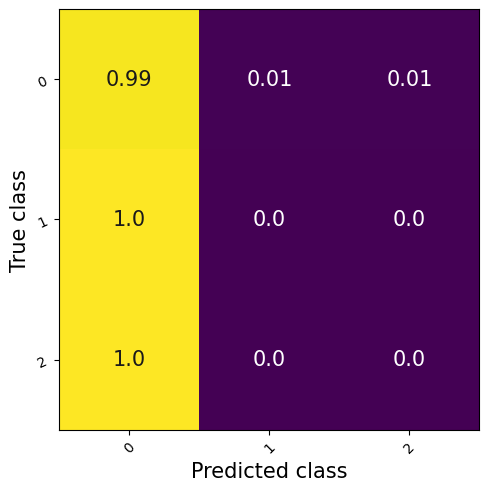

tensor([[1491,   11,   10],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3284 ✨
perclass_f1scores: tensor([0.9851, 0.0000, 0.0000])
perclass_precision: tensor([0.9842, 0.0000, 0.0000])
perclass_recall: tensor([0.9861, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


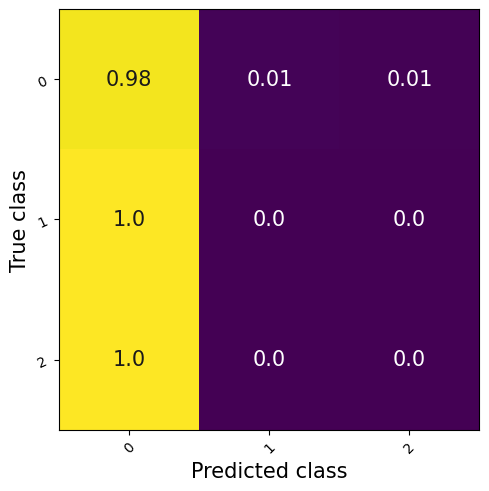

tensor([[1486,   14,   10],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3278 ✨
perclass_f1scores: tensor([0.9835, 0.0000, 0.0000])
perclass_precision: tensor([0.9828, 0.0000, 0.0000])
perclass_recall: tensor([0.9841, 0.0000, 0.0000])
MAE overall: 11.0000
MAE per_class: {1: np.float64(11.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


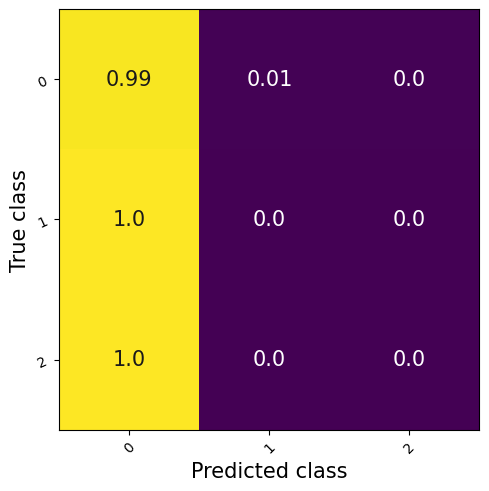

tensor([[2258,   12,    9],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9899, 0.0000, 0.0000])
perclass_precision: tensor([0.9890, 0.0000, 0.0000])
perclass_recall: tensor([0.9908, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


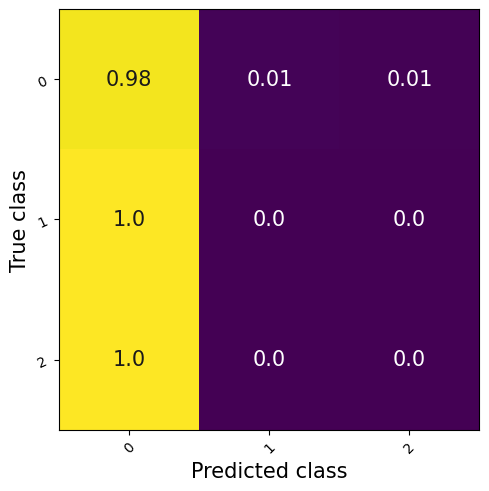

tensor([[1484,   15,   11],
        [  14,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3276 ✨
perclass_f1scores: tensor([0.9828, 0.0000, 0.0000])
perclass_precision: tensor([0.9828, 0.0000, 0.0000])
perclass_recall: tensor([0.9828, 0.0000, 0.0000])
MAE overall: 10.0000
MAE per_class: {1: np.float64(10.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


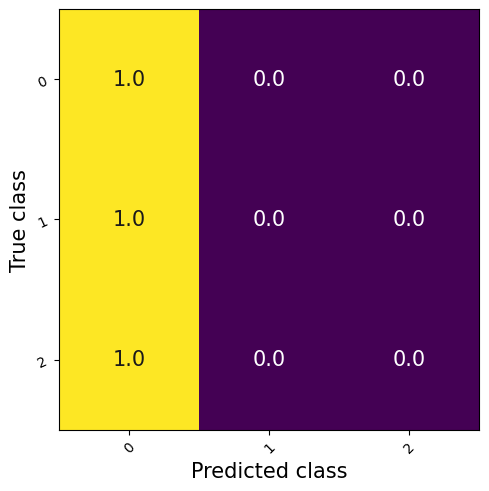

tensor([[2022,    6,    1],
        [   9,    0,    0],
        [  10,    0,    0]])
Macro F1-Score: 0.3312 ✨
perclass_f1scores: tensor([0.9936, 0.0000, 0.0000])
perclass_precision: tensor([0.9907, 0.0000, 0.0000])
perclass_recall: tensor([0.9966, 0.0000, 0.0000])
MAE overall: 14.0000
MAE per_class: {1: np.float64(14.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


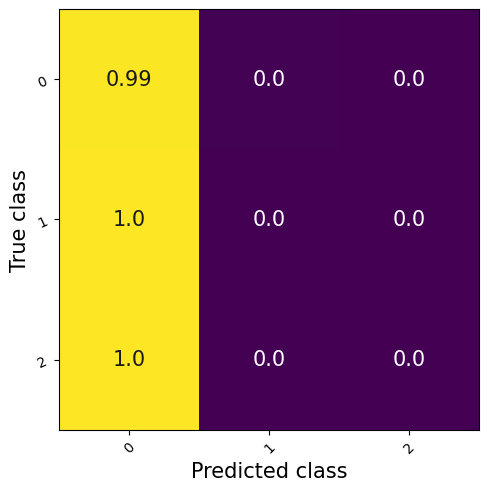

tensor([[1505,    6,    3],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3299 ✨
perclass_f1scores: tensor([0.9898, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9941, 0.0000, 0.0000])
MAE overall: 10.5000
MAE per_class: {1: np.float64(10.5)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


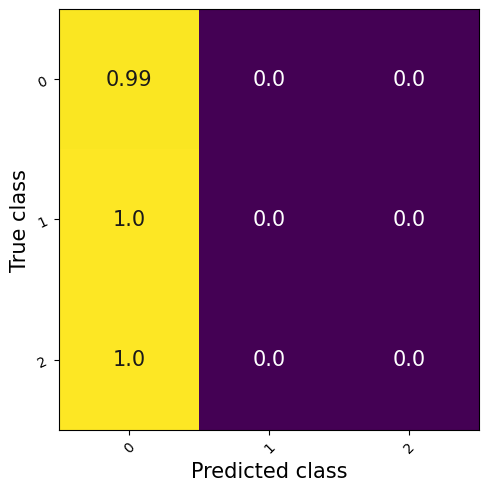

tensor([[1509,    4,    4],
        [  10,    0,    0],
        [   9,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9911, 0.0000, 0.0000])
perclass_precision: tensor([0.9876, 0.0000, 0.0000])
perclass_recall: tensor([0.9947, 0.0000, 0.0000])
MAE overall: 11.7500
MAE per_class: {1: np.float64(11.75)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


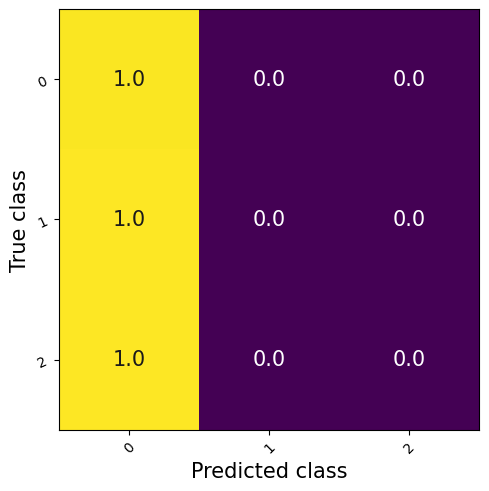

tensor([[1763,    5,    2],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3306 ✨
perclass_f1scores: tensor([0.9918, 0.0000, 0.0000])
perclass_precision: tensor([0.9877, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 12.0000
MAE per_class: {1: np.float64(12.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


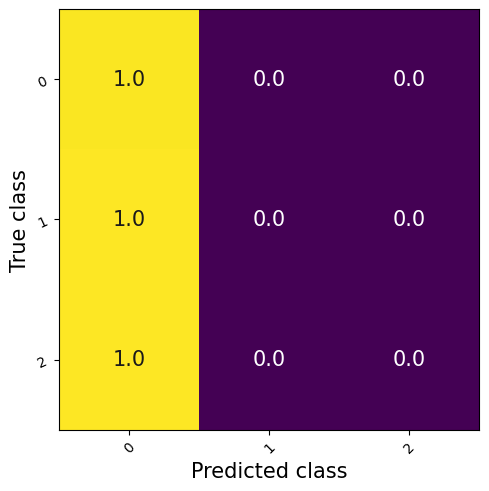

tensor([[1508,    4,    2],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3303 ✨
perclass_f1scores: tensor([0.9908, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 9.5000
MAE per_class: {1: np.float64(9.5)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


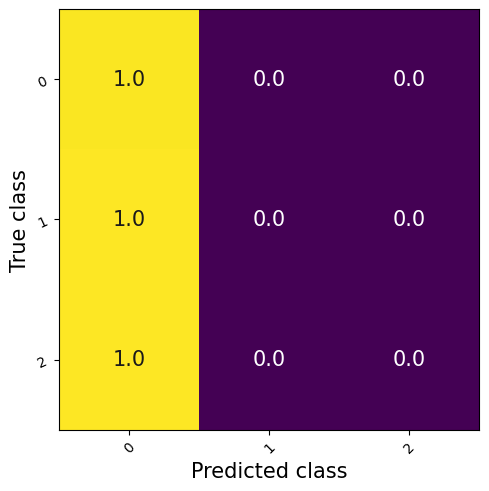

tensor([[1507,    5,    2],
        [  11,    0,    0],
        [  11,    0,    0]])
Macro F1-Score: 0.3302 ✨
perclass_f1scores: tensor([0.9905, 0.0000, 0.0000])
perclass_precision: tensor([0.9856, 0.0000, 0.0000])
perclass_recall: tensor([0.9954, 0.0000, 0.0000])
MAE overall: 8.0000
MAE per_class: {1: np.float64(8.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


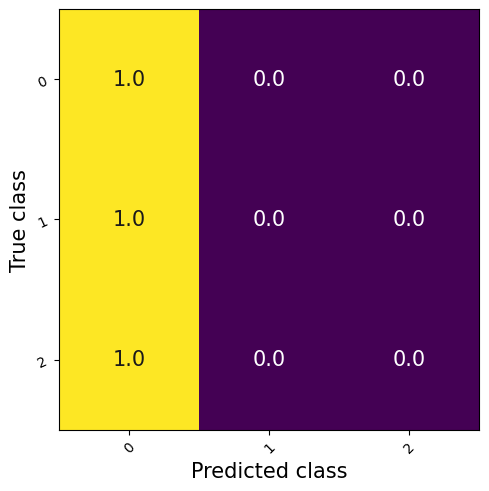

tensor([[2020,    0,    5],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3310 ✨
perclass_f1scores: tensor([0.9931, 0.0000, 0.0000])
perclass_precision: tensor([0.9887, 0.0000, 0.0000])
perclass_recall: tensor([0.9975, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


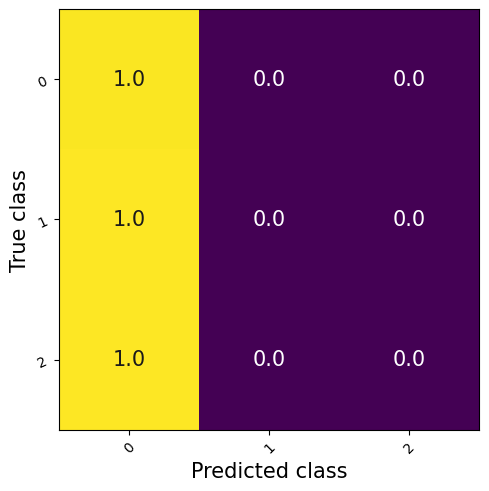

tensor([[2016,    2,    6],
        [  12,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3307 ✨
perclass_f1scores: tensor([0.9921, 0.0000, 0.0000])
perclass_precision: tensor([0.9882, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {1: np.float64(20.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


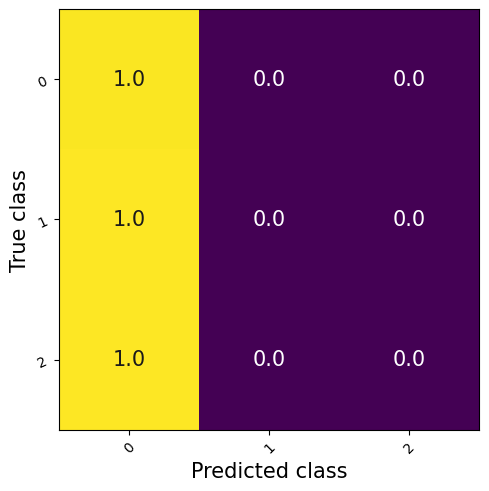

tensor([[2017,    3,    5],
        [  11,    0,    0],
        [  12,    0,    0]])
Macro F1-Score: 0.3308 ✨
perclass_f1scores: tensor([0.9924, 0.0000, 0.0000])
perclass_precision: tensor([0.9887, 0.0000, 0.0000])
perclass_recall: tensor([0.9960, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


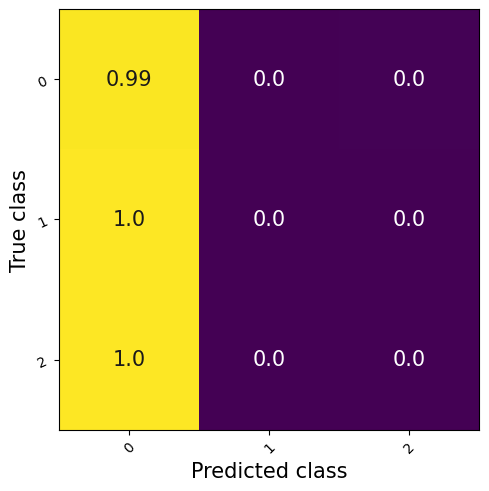

tensor([[1757,    2,    8],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3300 ✨
perclass_f1scores: tensor([0.9901, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9943, 0.0000, 0.0000])
MAE overall: 20.0000
MAE per_class: {2: np.float64(20.0)}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


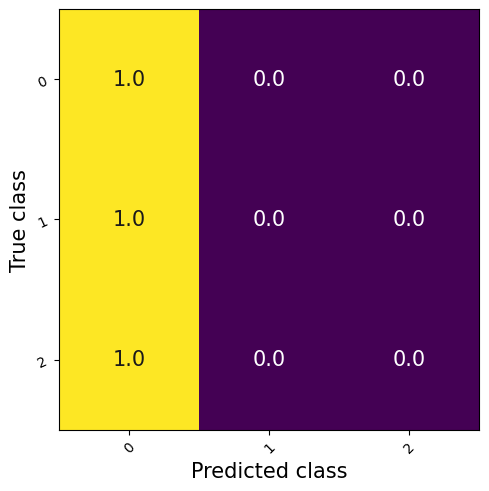

tensor([[1761,    0,    6],
        [  12,    0,    0],
        [  13,    0,    0]])
Macro F1-Score: 0.3304 ✨
perclass_f1scores: tensor([0.9913, 0.0000, 0.0000])
perclass_precision: tensor([0.9860, 0.0000, 0.0000])
perclass_recall: tensor([0.9966, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


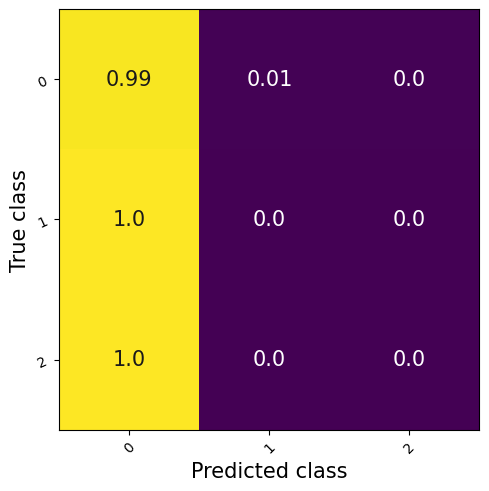

tensor([[2762,   14,   11],
        [  14,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3301 ✨
perclass_f1scores: tensor([0.9903, 0.0000, 0.0000])
perclass_precision: tensor([0.9896, 0.0000, 0.0000])
perclass_recall: tensor([0.9910, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


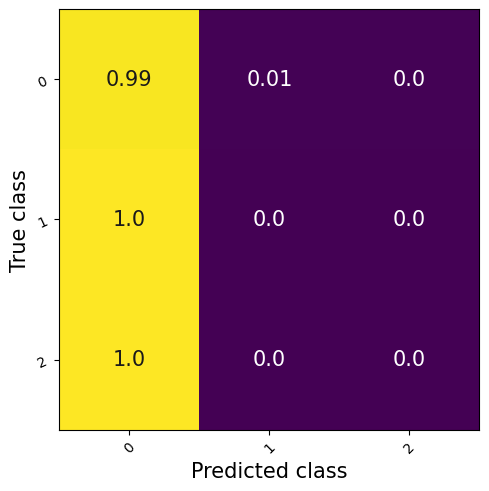

tensor([[2757,   15,   11],
        [  17,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3298 ✨
perclass_f1scores: tensor([0.9894, 0.0000, 0.0000])
perclass_precision: tensor([0.9882, 0.0000, 0.0000])
perclass_recall: tensor([0.9907, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


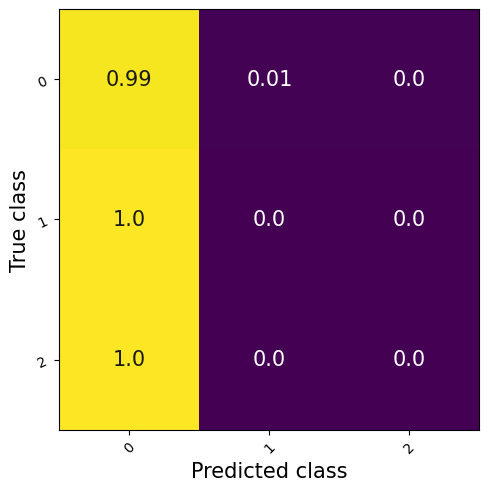

tensor([[2243,   17,   10],
        [  18,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9866, 0.0000, 0.0000])
perclass_precision: tensor([0.9851, 0.0000, 0.0000])
perclass_recall: tensor([0.9881, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


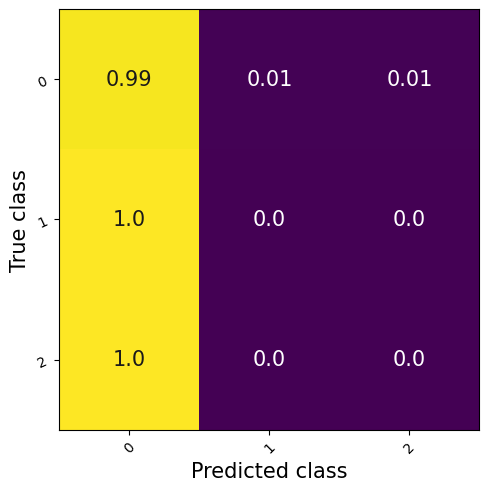

tensor([[2243,   17,   12],
        [  17,    0,    0],
        [  15,    0,    0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9866, 0.0000, 0.0000])
perclass_precision: tensor([0.9859, 0.0000, 0.0000])
perclass_recall: tensor([0.9872, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


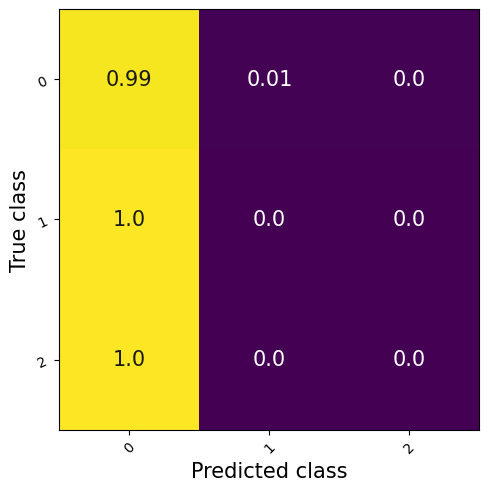

tensor([[2244,   17,   10],
        [  17,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3289 ✨
perclass_f1scores: tensor([0.9868, 0.0000, 0.0000])
perclass_precision: tensor([0.9855, 0.0000, 0.0000])
perclass_recall: tensor([0.9881, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


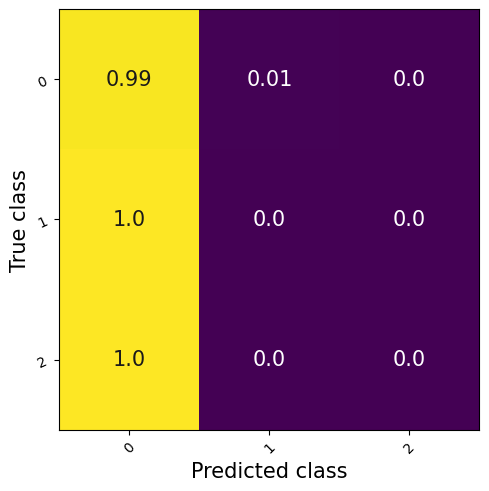

tensor([[2501,   17,    8],
        [  18,    0,    0],
        [  16,    0,    0]])
Macro F1-Score: 0.3294 ✨
perclass_f1scores: tensor([0.9883, 0.0000, 0.0000])
perclass_precision: tensor([0.9866, 0.0000, 0.0000])
perclass_recall: tensor([0.9901, 0.0000, 0.0000])
MAE overall: nan
MAE per_class: {}


In [143]:
testset_f1_scores = []
testset_pc_f1_scores = []
testset_pc_precision = []
testset_pc_recall = []
testset_mae = []
testset_pc_mae = []
testset_cm = []
group_assigment = []
all_preds = []
all_targets = []

cur_set_to_test = np.arange(len(test_set_fpaths))
for curr_test_idx in cur_set_to_test.tolist():

    if use_internal_train_stats:
        train_stat = {'mean': np.array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781, 0.86179046]), 
                      'std': np.array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,5.12151813]),}
        # global_mean = train_stat["mean"]
        # global_var = train_stat["std"]
    else:
        # global_mean = np.zeros(6)
        # global_var = np.ones(6)
        train_stat=curr_datamodule.train_dataset.zscale_stats
        
    curr_test_datamodule = ExternalGaitDataModule(np.array(test_set_fpaths), 
                                             test_idx=[curr_test_idx], 
                                             batch_size=1024,
                                             window_size=256,
                                             step_size=256,
                                             expand_labels=0,
                                             zscale=True,
                                             zscale_stats=train_stat
                                            )
    curr_test_datamodule.setup("test")
    test_dataloader = curr_test_datamodule.test_dataloader()
    best_model.eval()
    pred=[]
    target=[]
    for sample_input, sample_target in test_dataloader:
        # data_sf = [pd.DataFrame(sample_input[i].numpy(), columns=['gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']) for i in range(sample_input.shape[0])]
        # data_sf = [rotate_dataset(i, R) for i in data_sf]
        # # data_sf = [sensor_alignment.align_dataset_to_gravity(i, 100) for i in data_sf]
        # sample_input = torch.tensor(np.stack(([i.values for i in data_sf]))).to(torch.float32)
        # print("old mean:", sample_input.mean([0, 1]))
        # sample_input = (sample_input-global_mean)/global_var
        # print("normalized mean:", sample_input.mean([0, 1]))
        sample_input = sample_input.to(device_)
        sample_target = sample_target.to(device_)
        print(sample_input.shape)
        with torch.no_grad():
            predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
        pred.append(predicted_output)
        target.append(sample_target)
    
    cur_pred = torch.concat(pred).reshape(-1, 3)
    cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
    cur_target = torch.concat(target).reshape(-1)
    reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
    print("Pred", cur_pred.shape, "Target", cur_target.shape)
    
    ALIGN_TOLERANCE = 3
    merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
    merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
    aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
    
    
    cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
    cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    fig_, ax_ = cm.plot()
    plt.show()
    unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
    unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    ucm_tensor = unnormalized_cm.compute()
    testset_cm.append(ucm_tensor)
    print(ucm_tensor)
    
    num_classes = 3
    f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")
    
    pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
    perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_f1_scores.append(perclass_f1scores)
    print(f"perclass_f1scores:", perclass_f1scores)
    
    pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
    perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_precision.append(perclass_precision)
    print(f"perclass_precision:", perclass_precision)
    
    pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
    perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_recall.append(perclass_recall)
    print(f"perclass_recall:", perclass_recall)
    
    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    
    overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
    overall = overall.item() if not np.isnan(overall) else np.nan
    print(f"MAE overall: {overall:.4f}")
    print(f"MAE per_class: {per_class}")
    testset_f1_scores.append(f1_macro_score)
    testset_mae.append(overall)
    testset_pc_mae.append(per_class)

    all_preds.append(aligned_preds)
    all_targets.append(merged_targets)

In [144]:
# Add nan if element missing in MAE calculation
new_testset_pc_mae = []
for i in testset_pc_mae:
    if 1 not in i:
        i[1] = np.nan
    if 2 not in i:
        i[2] = np.nan
    new_testset_pc_mae.append(i)

In [145]:
extdata1_pc_f1_df = pd.DataFrame(torch.stack(testset_pc_f1_scores).numpy())
extdata1_pc_f1_df.columns = ["NE", "IC", "FO"]
extdata1_pc_f1_df = extdata1_pc_f1_df.melt()

extdata1_pc_mae_df = pd.DataFrame(new_testset_pc_mae) * 10.0
extdata1_pc_mae_df.columns = ["IC", "FO"]
extdata1_pc_mae_df = extdata1_pc_mae_df.melt()
extdata1_pc_mae_df.head()



,variable,value
0,IC,87.5
1,IC,NaN
2,IC,200.0
3,IC,130.0
4,IC,140.0


### 2.4 Plot CM of external dataset

In [146]:
from gait_ml import utils

In [147]:
cur_cm = torch.stack(testset_cm).sum(0).numpy()
normalize_cm = (cur_cm/cur_cm.sum(1, keepdims=True)).round(2)
normalize_cm
# utils.plot_confusion_matrix(cur_cm, class_names=["NE", "IC", "FO"], title="Detection Performance", fmt=".2f", cbar_label=["NE", "IC", "FO"], normalize="true")

array([[0.99, 0.  , 0.  ],
       [0.99, 0.01, 0.  ],
       [1.  , 0.  , 0.  ]])

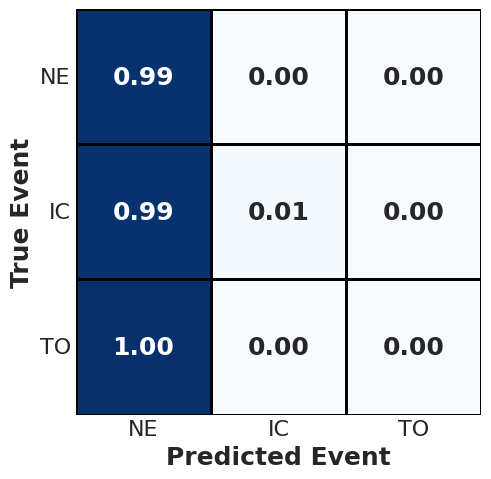

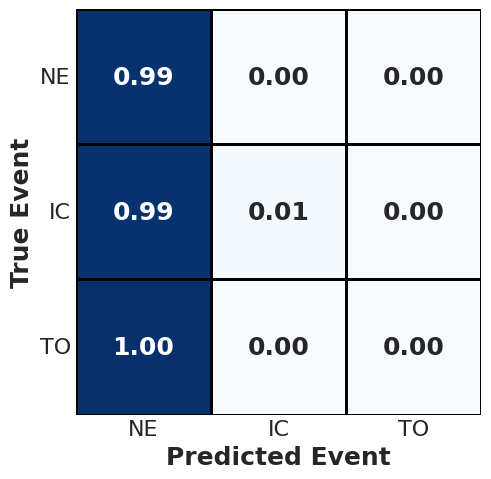

In [148]:
utils.plot_confusion_matrix(cm=normalize_cm,
                          class_names=["NE", "IC", "TO"], 
                          title=None, 
                          fmt=".2f",
                          cbar_label="Count",
                          file_name=boxplot_name.replace("mae_", "f1_")+".pdf")

In [149]:
# # Sanity check using MulticlassConfusionMatrix
# cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
# cm.confmat = torch.tensor(cur_cm)
# fig_, ax_ = cm.plot()

### 2.5 Plot temporal deviation external dataset

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from typing import Optional, List

def plot_journal_boxplot(
    df: pd.DataFrame, 
    x_col: str, 
    y_col: str, 
    x_label: str, 
    y_label: str, 
    filename: Optional[str] = None,
    order: Optional[List] = None,
    palette: str = "Blues"
):
    """
    Generates a JNER-compliant Box Plot with an overlayed Strip Plot.
    
    Changes from previous version:
    - Uses 'whitegrid' style.
    - Uses Arial/Helvetica fonts.
    - Saves as both PDF (vector) and PNG (600 DPI).
    - Removes plot title (should be in LaTeX caption).
    """
    
    # --- 1. JNER Style Setup ---
    # Use standard sans-serif fonts (Arial/Helvetica) as per JNER guidelines
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    
    # Style: White background with grid is standard for scientific comparison
    sns.set_style("whitegrid") 
    
    # Optimal figure size for single-column journal placement (~3.5 inch width is 1 col, 
    # but 8x5 allows for nice scaling/spanning)
    plt.figure(figsize=(10, 6))

    # --- 2. Plotting ---
    
    # Box Plot (Statistical Summary)
    # Using the "Blues" palette and thinner width as per your reference
    sns.boxplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        order=order,           # Critical for correct X-axis sorting
        showfliers=False,      # Outliers covered by strip plot
        width=0.5,             # Thinner boxes look cleaner
        linewidth=1.2,         # Thicker lines for visibility
        palette=palette        # JNER-safe palette
    )

    # Strip Plot (Individual Data Points)
    # Kept this from your original function as it is preferred in neuro-journals 
    # over simple boxplots, but styled to match the "Blues" aesthetic.
    sns.stripplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        order=order,
        color='.15',           # Dark grey/black points (better contrast on Blue than pure black)
        jitter=0.2, 
        size=4, 
        alpha=0.6              # Slight transparency
    )

    # --- 3. Formatting Axes ---
    
    # Remove top and right spines
    sns.despine() 

    # Labels: Fontsize 16 and Bold (matches your reference)
    plt.xlabel(x_label, fontsize=30, fontweight='bold')
    plt.ylabel(y_label, fontsize=30, fontweight='bold')

    # Ticks: Fontsize 14
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    
    # Note: Title is intentionally removed. 
    # JNER requires titles to be in the figure caption text, not the image itself.

    plt.tight_layout()

    # --- 4. Save or Show ---
    if filename:
        # Strip extension if provided to save multiple formats
        base_filename = filename.rsplit('.', 1)[0]
        
        # Save as PDF (Vector - Best for submission)
        plt.savefig(f"{base_filename}.pdf", bbox_inches='tight')
        
        # Save as PNG (Raster - High DPI for review)
        # plt.savefig(f"{base_filename}.png", dpi=600, bbox_inches='tight')
        
        print(f"Plot saved as '{base_filename}.pdf' and '{base_filename}.png' (600 DPI).")
        plt.show()
        plt.close()
    else:
        plt.show()

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from typing import Optional, List


def plot_journal_boxplot(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    x_label: str,
    y_label: str,
    filename: Optional[str] = None,
    order: Optional[List] = None,
    palette: str = "Blues",
    annotate_means: bool = True,
):
    """Generate a journal-style boxplot with observations and mean values."""

    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ]

    sns.set_style("whitegrid")

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x=x_col,
        y=y_col,
        order=order,
        showfliers=False,
        showmeans=True,
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 7,
        },
        width=0.5,
        linewidth=1.2,
        palette=palette,
        ax=ax,
    )

    sns.stripplot(
        data=df,
        x=x_col,
        y=y_col,
        order=order,
        color=".15",
        jitter=0.2,
        size=4,
        alpha=0.6,
        ax=ax,
    )

    if order is None:
        order = list(pd.unique(df[x_col].dropna()))

    if annotate_means:
        means = df.groupby(x_col, observed=False)[y_col].mean()

        for position, category in enumerate(order):
            mean_value = means.get(category, np.nan)

            if pd.notna(mean_value):
                ax.annotate(
                    f"{mean_value:.2f} ms",
                    xy=(position, mean_value),
                    xytext=(0, 12),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=30,
                    fontweight="bold",
                )
            else:
                # For example, FO with no valid matches.
                ax.text(
                    position,
                    0.96,
                    "No valid\nmatches",
                    transform=ax.get_xaxis_transform(),
                    ha="center",
                    va="top",
                    fontsize=16,
                )

    sns.despine(ax=ax)

    ax.set_xlabel(x_label, fontsize=30, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=30, fontweight="bold")
    ax.tick_params(axis="both", labelsize=30)

    fig.tight_layout()

    if filename:
        base_filename = filename.rsplit(".", 1)[0]
        fig.savefig(f"{base_filename}.pdf", bbox_inches="tight")
        print(f"Plot saved as '{base_filename}.pdf'.")
        plt.show()
        plt.close(fig)
    else:
        plt.show()

In [152]:
extdata1_pc_mae_df

,variable,value
0,IC,87.5
1,IC,NaN
2,IC,200.0
3,IC,130.0
4,IC,140.0
...,...,...
211,FO,NaN
212,FO,NaN
213,FO,NaN
214,FO,NaN


/tmp/ipykernel_1585603/4121513979.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Plot saved as 'X_figures/mae_zshot.pdf'.


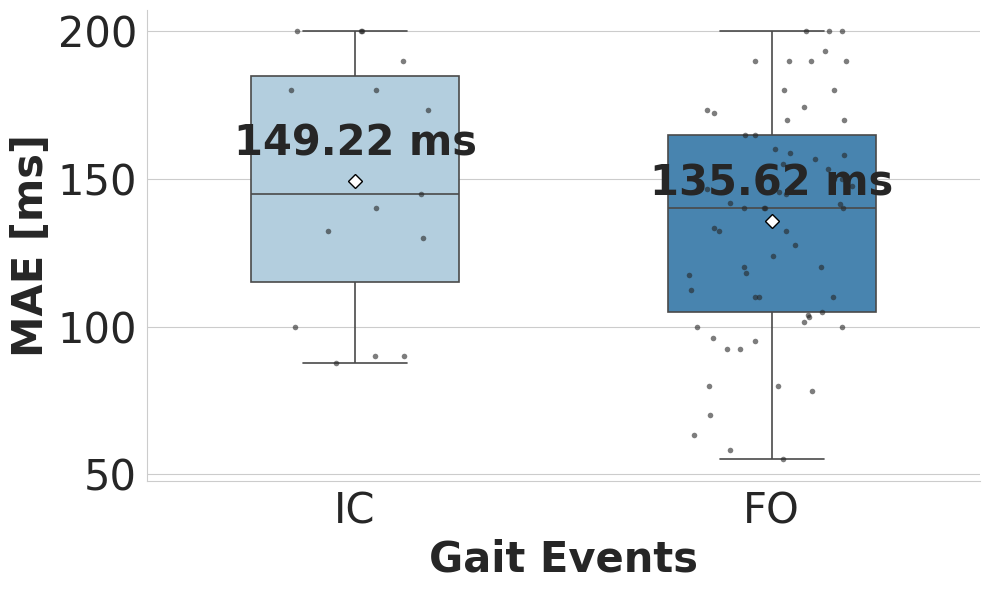

In [153]:
# Assuming 'plot_df' is your prepared dataframe
# and 'cur_metric_name' is your Y column

plot_journal_boxplot(
    df=extdata1_pc_mae_df,
    x_col="variable",
    y_col="value",
    x_label="Gait Events",
    y_label=r"MAE [ms]",  # LaTeX Bold Math label
    filename=f"{boxplot_name}",
    # order=[1, 2, 4, 8] # Explicit order
)

In [122]:
# Full fine-tuning
extdata1_pc_mae_df.groupby("variable").agg("mean")

,value
variable,
FO,2.152666
IC,2.842717


In [103]:
# Last layer fine-tuning
extdata1_pc_mae_df.groupby("variable").agg("mean")

,value
variable,
FO,NaN
IC,153.888889


In [90]:
# Zero-shot
extdata1_pc_mae_df.groupby("variable").agg("mean")

,value
variable,
FO,135.617705
IC,149.222222


In [28]:
# plotting.plot_xyz(reshaped_input[:, 0], reshaped_input[:, 1], reshaped_input[:, 2], merged_targets.astype(int))
# plotting.plot_xyz(reshaped_input[:, 0], reshaped_input[:, 1], reshaped_input[:, 2], merged_preds.astype(int))

### 3. Evalaute concordance of gait feature

In [36]:
# Find all patient ids
subject_ids = [Path(i).parents[3].name for i in test_set_fpaths]

# Take average feature per subject since there are ~
stridetime_pred = [utils.calculate_stride_times(i, 100) for i in all_preds]
stridetime_target = [utils.calculate_stride_times(i, 100) for i in all_targets]
stridetime_pred = utils.aggregate_res(stridetime_pred, subject_ids)
stridetime_target = utils.aggregate_res(stridetime_target, subject_ids)

stridetime_res_df = pd.concat([stridetime_pred, stridetime_target], axis=1)
stridetime_res_df

,0,0
AB06,1.079902,1.108807
AB07,1.328727,1.340917
AB09,1.334167,1.284123
AB11,1.193706,1.219286
AB14,0.960374,0.960374
AB17,1.143765,1.143765
AB19,1.234435,1.262818
AB21,1.024320,1.042177
AB23,1.095294,1.104576
AB24,1.142804,1.158571


In [37]:
# Find all patient ids
subject_ids = [Path(i).parents[3].name for i in test_set_fpaths]

# Take average feature per subject since there are ~
stance_pred = [utils.calculate_gait_phases_vectorized(i) for i in all_preds]
stance_target = [utils.calculate_gait_phases_vectorized(i) for i in all_targets]
stance_pred = utils.aggregate_res(stance_pred, subject_ids)
stance_target = utils.aggregate_res(stance_target, subject_ids)

res_df = pd.concat([stance_pred, stance_target], axis=1)

swing_res_df = 100 - res_df

/beegfs1/home/qivy00li/projects/gait_ml/src/gait_ml/utils.py:184: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


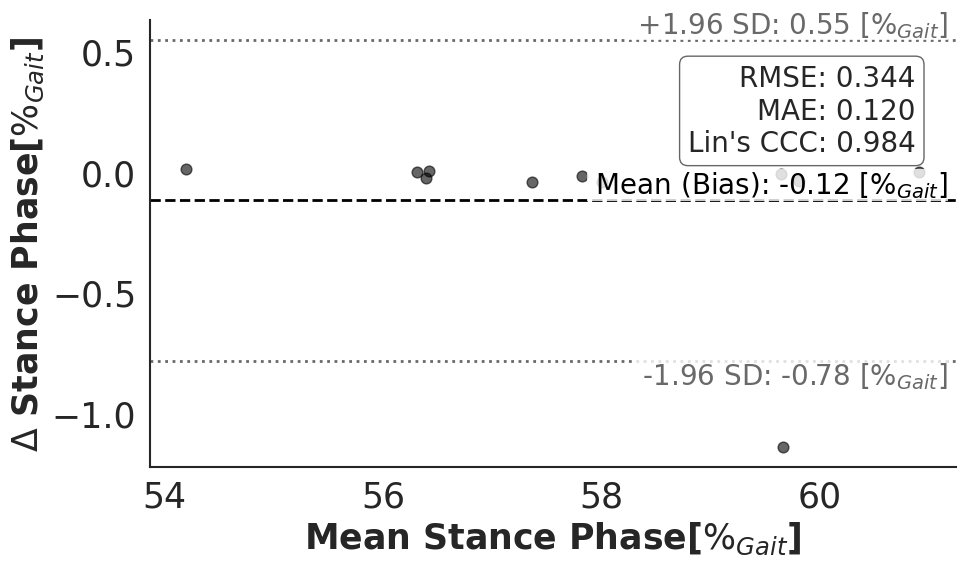

In [31]:
# 2. Call the plotting function
fig, ax = utils.plot_bland_altman_publication(
    res_df.iloc[:, 0], 
    res_df.iloc[:, 1], 
    method1_name='Pred',
    method2_name='GT',
    units=r'[$\%_{Gait}$]',
    filename="X_figures/stance_bland_altman_external.pdf",
    feature_name="Stance Phase"
)

/beegfs1/home/qivy00li/projects/gait_ml/src/gait_ml/utils.py:184: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


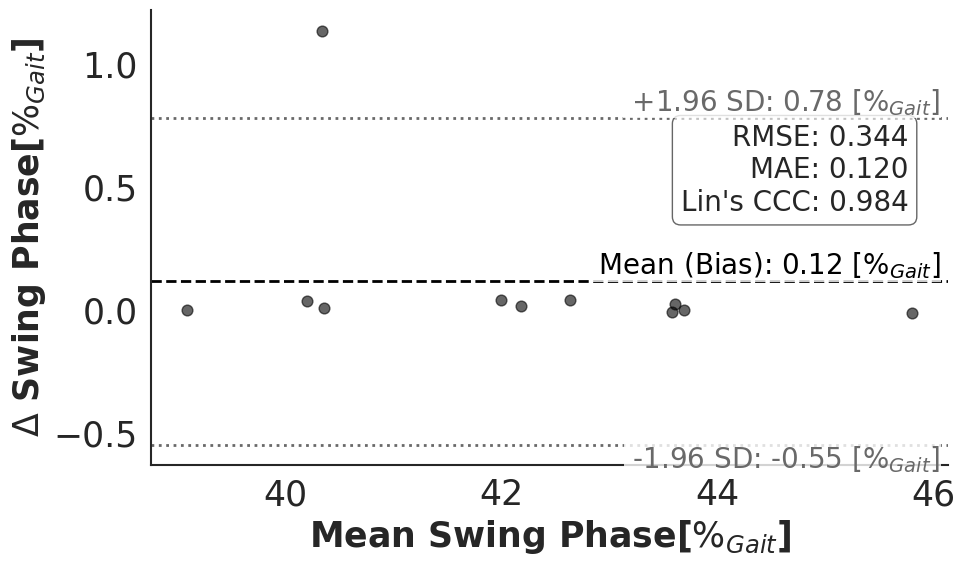

In [32]:
# 2. Call the plotting function
fig, ax = utils.plot_bland_altman_publication(
    swing_res_df.iloc[:, 0], 
    swing_res_df.iloc[:, 1], 
    method1_name='Pred',
    method2_name='GT',
    units=r'[$\%_{Gait}$]',
    filename="X_figures/swing_bland_altman_external.pdf",
    feature_name="Swing Phase",
    ypos=.75
)

In [38]:
stridetime_res_df

,0,0
AB06,1.079902,1.108807
AB07,1.328727,1.340917
AB09,1.334167,1.284123
AB11,1.193706,1.219286
AB14,0.960374,0.960374
AB17,1.143765,1.143765
AB19,1.234435,1.262818
AB21,1.024320,1.042177
AB23,1.095294,1.104576
AB24,1.142804,1.158571


In [37]:
# def plot_bland_altman_publication(
#     method1,
#     method2,
#     method1_name="LE-GRU",
#     method2_name="Reference",
#     units="ms",
#     display_scale=1000.0,  # Convert input seconds to milliseconds
#     ax=None,
#     filename="bland_altman_plot.pdf",
#     feature_name="Stride time",
#     xpos=0.95,
#     ypos=0.90,
# ):
#     """
#     Create a publication-ready Bland–Altman plot.

#     Parameters
#     ----------
#     method1, method2 : array-like
#         Paired measurements. Values are assumed to be in seconds when
#         display_scale=1000.
#     units : str
#         Display unit, e.g. "ms".
#     display_scale : float
#         Conversion from the input unit to the display unit.
#         Use 1000 for seconds -> milliseconds and 1 for no conversion.
#     """

#     font_sizes = {
#         "main": 18,
#         "axes_label": 25,
#         "tick_label": 25,
#         "metrics_box": 20,
#         "line_label": 20,
#     }

#     plt.style.use("seaborn-v0_8-white")

#     plt.rcParams.update(
#         {
#             "font.family": "sans-serif",
#             "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
#             "font.size": font_sizes["main"],
#             "axes.labelsize": font_sizes["axes_label"],
#             "xtick.labelsize": font_sizes["tick_label"],
#             "ytick.labelsize": font_sizes["tick_label"],
#             "axes.linewidth": 1.5,
#         }
#     )

#     # Convert and validate paired inputs
#     method1 = np.asarray(method1, dtype=float).ravel()
#     method2 = np.asarray(method2, dtype=float).ravel()

#     if method1.shape != method2.shape:
#         raise ValueError("method1 and method2 must have the same shape.")

#     valid = np.isfinite(method1) & np.isfinite(method2)
#     method1 = method1[valid]
#     method2 = method2[valid]

#     if method1.size < 2:
#         raise ValueError("At least two valid paired observations are required.")

#     # Bland–Altman values in the original input unit
#     average = (method1 + method2) / 2.0
#     difference = method1 - method2

#     mean_diff = np.mean(difference)
#     std_diff = np.std(difference, ddof=1)
#     loa_upper = mean_diff + 1.96 * std_diff
#     loa_lower = mean_diff - 1.96 * std_diff

#     mae = mean_absolute_error(method2, method1)
#     rmse = np.sqrt(mean_squared_error(method2, method1))
#     ccc = lins_ccc(method2, method1)

#     # Convert values for display
#     average_display = average * display_scale
#     difference_display = difference * display_scale
#     mean_diff_display = mean_diff * display_scale
#     loa_upper_display = loa_upper * display_scale
#     loa_lower_display = loa_lower * display_scale
#     mae_display = mae * display_scale
#     rmse_display = rmse * display_scale

#     if ax is None:
#         fig, ax = plt.subplots(figsize=(10, 6))
#     else:
#         fig = ax.figure

#     ax.scatter(
#         average_display,
#         difference_display,
#         facecolors="none",
#         edgecolors="black",
#         s=60,
#         alpha=0.6,
#     )

#     ax.axhline(
#         mean_diff_display,
#         color="black",
#         linestyle="--",
#         linewidth=2,
#     )
#     ax.axhline(
#         loa_upper_display,
#         color="dimgray",
#         linestyle=":",
#         linewidth=2,
#     )
#     ax.axhline(
#         loa_lower_display,
#         color="dimgray",
#         linestyle=":",
#         linewidth=2,
#     )

#     metrics_text = (
#         f"RMSE: {rmse_display:.1f} {units}\n"
#         f"MAE: {mae_display:.1f} {units}\n"
#         f"Lin's CCC: {ccc:.3f}"
#     )

#     ax.text(
#         xpos,
#         ypos,
#         metrics_text,
#         transform=ax.transAxes,
#         fontsize=font_sizes["metrics_box"],
#         verticalalignment="top",
#         horizontalalignment="right",
#         bbox=dict(
#             boxstyle="round",
#             facecolor="white",
#             edgecolor="black",
#             alpha=0.8,
#             linewidth=1,
#         ),
#     )

#     ax.set_xlabel(
#         f"Mean {feature_name} [{units}]",
#         fontsize=font_sizes["axes_label"],
#         fontweight="bold",
#     )
#     ax.set_ylabel(
#         rf"$\Delta$ {feature_name} [{units}]",
#         fontsize=font_sizes["axes_label"],
#         fontweight="bold",
#     )

#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
#     ax.tick_params(
#         axis="both",
#         which="major",
#         direction="out",
#         width=1.5,
#         length=6,
#     )

#     # Ensure axis limits are finalized before positioning line labels
#     ax.relim()
#     ax.autoscale_view()

#     x_min, x_max = ax.get_xlim()
#     x_padding = 0.01 * (x_max - x_min)
#     x_text = x_max - x_padding

#     label_box = dict(
#         facecolor="white",
#         alpha=0.8,
#         edgecolor="none",
#         pad=0.1,
#     )

#     ax.text(
#         x_text,
#         mean_diff_display,
#         f"Bias: {mean_diff_display:.1f} {units}",
#         ha="right",
#         va="bottom",
#         fontsize=font_sizes["line_label"],
#         color="black",
#         bbox=label_box,
#     )

#     ax.text(
#         x_text,
#         loa_upper_display,
#         f"Upper 95% LoA: {loa_upper_display:.1f} {units}",
#         ha="right",
#         va="bottom",
#         fontsize=font_sizes["line_label"],
#         color="dimgray",
#         bbox=label_box,
#     )

#     ax.text(
#         x_text,
#         loa_lower_display,
#         f"Lower 95% LoA: {loa_lower_display:.1f} {units}",
#         ha="right",
#         va="top",
#         fontsize=font_sizes["line_label"],
#         color="dimgray",
#         bbox=label_box,
#     )

#     fig.tight_layout()
#     fig.savefig(
#         filename,
#         dpi=600,
#         bbox_inches="tight",
#         transparent=False,
#     )

#     return fig, ax

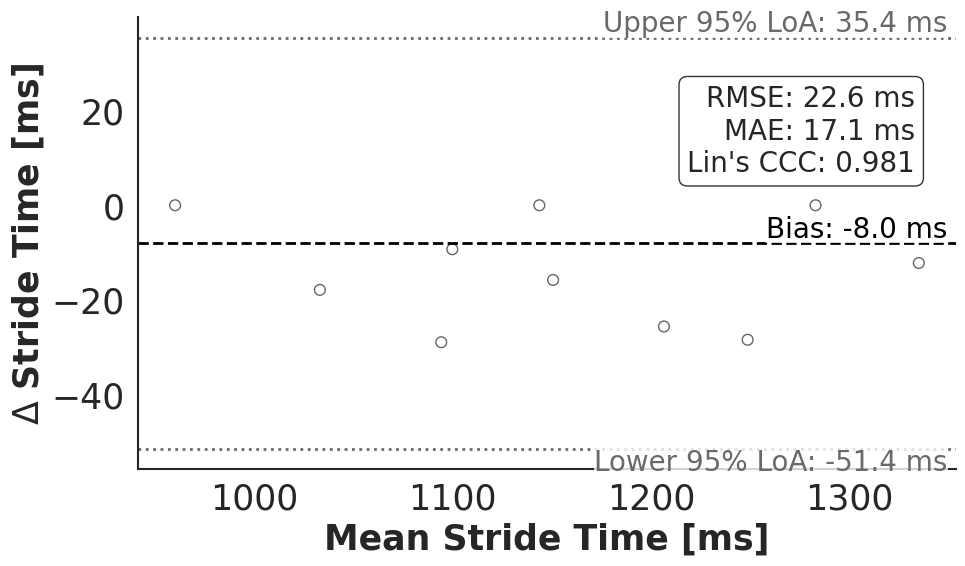

In [42]:
# 2. Call the plotting function
fig, ax = utils.plot_bland_altman_publicationv2(
    stridetime_res_df.iloc[:, 0], 
    stridetime_res_df.iloc[:, 1], 
    method1_name='Pred',
    method2_name='GT',
    units=r'ms',
    filename="X_figures/stridetime_bland_altman_external.pdf",
    feature_name="Stride Time",
    ypos=.85
)

### Calculate CI for Lin's CCC

In [41]:
ccc, ccc_ci_lower, ccc_ci_upper = utils.lins_ccc_with_ci(
        stridetime_res_df.iloc[:, 0],
        stridetime_res_df.iloc[:, 1],
        confidence_level=0.95,
        n_resamples=1000,
        random_seed=42,
    )

In [42]:
print("ccc:", round(ccc, 3)) 
print("ccc_ci_lower:", round(ccc_ci_lower, 3)) 
print("ccc_ci_upper:", round(ccc_ci_upper, 3))

ccc: 0.981
ccc_ci_lower: 0.948
ccc_ci_upper: 0.996


In [47]:
ccc, ccc_ci_lower, ccc_ci_upper = utils.lins_ccc_with_ci(
        res_df.iloc[:, 0], 
        res_df.iloc[:, 1], 
        confidence_level=0.95,
        n_resamples=1000,
        random_seed=42,
    )

In [46]:
print("ccc:", round(ccc, 3)) 
print("ccc_ci_lower:", round(ccc_ci_lower, 3)) 
print("ccc_ci_upper:", round(ccc_ci_upper, 3))

ccc: 0.984
ccc_ci_lower: 0.908
ccc_ci_upper: 1.0
